# PrediRuta: estado del actor

En este notebook se explorará la construcción del modelo de `estado de la victima según PrediRuta`. Por medio de la estimación de la probabilidad de consecuencia para una persona involucrada en un accidente de tránsito, clasificándola como `HERIDO`, `ILESO` o `MUERTO`. 

Se plantea utilizar información espacial, temporal, meteorológica y características disponibles del actor y del vehículo, incorporando las 150 zonas definidas por el modelo de ocurrencia. El notebook compara un escenario completo (todas las variables) con uno operativo (variables que un usuario de PrediRuta puede conocer al iniciar el trayecto). Se excluye la categoría `SIN INFORMACIÓN` para disminuir posible ruido para entrenar los diferentes modelos. 

Por medio de la evaluación de diferentes algoritmos mediante una partición temporal, se pretende determinar si es posible anticipar el estado del actor usando información disponible o derivable en una consulta real (variables climáticas).

**Consideraciones metodológicas**

1. Cada celda se asigna a una de las 150 zonas construidas para el modelo de ocurrencia
2. La categoría `SIN INFORMACIÓN` se excluye antes de dividir los datos
3. Los escenarios `completo` y `operativo` utilizan las mismas observaciones
4. Los hiperparámetros se ajustan independientemente para los alcances completo y operativo utilizando el escenario con clima; la configuración seleccionada se reutiliza sin clima para aislar el aporte meteorológico.
5. Se evaluará el efecto de la distribución temporal de los datos para la generación de la predicción
6. La variable `ANIO` se utilizará para realizar la partición temporal, pero no como predictor.

## 0. Configuración

In [236]:
# Importar librarias necesarias

from pathlib import Path
from time import perf_counter
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from IPython.display import display
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
warnings.filterwarnings('ignore', category=FutureWarning)


In [71]:
# Parámetros generales 

SEMILLA = 42
NUMERO_ZONAS = 150
TAMANO_CELDA_METROS = 500

VARIABLES_CLIMA_ORIGINALES = [
    'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
    'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]
VARIABLES_CLIMA_RETIRADAS_CORRELACION = [
    'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA', 'LLUVIA'
]
VARIABLES_CLIMA_CRUDAS = [
    variable for variable in VARIABLES_CLIMA_ORIGINALES
    if variable not in VARIABLES_CLIMA_RETIRADAS_CORRELACION
]

In [72]:
# Ruta directa desde la carpeta modelo/
CARPETA_DATOS = Path('../data/data_procesada/modelado')
RUTA_MODELADO = CARPETA_DATOS / 'TABLA_COMPLETA_MODELADO.csv'

## 1. Carga e integración de los datos

`TABLA_COMPLETA_MODELADO` contiene el contexto espacial, temporal, meteorológico y vial del accidente, las variables del actor y del vehículo, y la `ZONA_CIUDAD` calculada con las mismas 150 zonas del modelo de ocurrencia. Este notebook carga una sola fuente de datos.

In [73]:
# Columnas de interés para el modelado de estado
COLUMNAS_VIA_CATEGORICAS = [
    'GEOMETRIA_PLANTA', 'GEOMETRIA_TERRENO', 'GEOMETRIA_SECCION',
    'SENTIDO_VIA', 'SUPERFICIE_RODADURA', 'ESTADO_VIA',
    'CONDICION_VIA', 'ILUMINACION_ARTIFICIAL', 'SEMAFORO'
]
COLUMNAS_VIA_NUMERICAS = ['N_CALZADAS', 'N_CARRILES']
COLUMNAS_VIA = [*COLUMNAS_VIA_CATEGORICAS, *COLUMNAS_VIA_NUMERICAS]
COLUMNAS_ACTOR = ['ACTOR_ID', 'VEHICULO_ID', 'CONDICION', 'ESTADO', 'GENERO', 'EDAD']
COLUMNAS_VEHICULO = ['CLASE_VEHICULO', 'SERVICIO_VEHICULO']

In [74]:
# Carga de datos
tabla_modelado = pd.read_csv(
    RUTA_MODELADO,
    encoding='utf-8-sig',
    parse_dates=['FECHA_HORA'],
    dtype={'ACTOR_ID': 'Int64', 'VEHICULO_ID': 'Int64'},
    low_memory=False
)

In [75]:
# Construcción de centroides de zona y estructura para asignar zonas a coordenadas
centroides_zona = (
    tabla_modelado[
        ['ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
    ]
    .drop_duplicates()
    .sort_values('ZONA_CIUDAD')
    .reset_index(drop=True)
)
assert len(centroides_zona) == NUMERO_ZONAS
assert centroides_zona['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

# Transformación de coordenadas de EPSG:3116 (Bogotá) a EPSG:4326 (WGS84)
bogota_a_wgs84 = Transformer.from_crs('EPSG:3116', 'EPSG:4326', always_xy=True)
arbol_zonas = cKDTree(
    centroides_zona[['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']].to_numpy()
)

In [76]:
# Preparación de datos para modelado de estado
datos = tabla_modelado.loc[tabla_modelado['ACTOR_ID'].notna()].copy()
datos['ACTOR_ID'] = datos['ACTOR_ID'].astype('int64')
for columna in ['CONDICION', 'ESTADO', 'GENERO']:
    datos[columna] = datos[columna].astype('int64')

assert datos['ACTOR_ID'].is_unique
assert datos['ESTADO'].notna().all()

display(datos.head())
datos.info()

,ACCIDENTE_ID,ACTOR_ID,VEHICULO_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_ID,CELDA_X,CELDA_Y,ZONA_CIUDAD,...,CLASE_ACCIDENTE,CLASE_ACCIDENTE_DESC,OBJETIVO_GRAVE,CONDICION,ESTADO,ESTADO_DESC,GENERO,EDAD,CLASE_VEHICULO,SERVICIO_VEHICULO
0,12798,97170,1279802,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,70,...,7,VOLCAMIENTO,1,4,1,HERIDO,2,12.0,13.0,3.0
1,10819805,13443090,1081980502,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,70,...,7,VOLCAMIENTO,1,3,1,HERIDO,2,12.0,13.0,3.0
2,13707,98533,1370702,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,129,...,4,CHOQUE,0,3,2,ILESO,2,41.0,1.0,4.0
3,13707,98534,1370703,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,129,...,4,CHOQUE,0,3,2,ILESO,2,60.0,1.0,4.0
4,10819463,13385884,1081946302,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,129,...,4,CHOQUE,0,3,2,ILESO,2,41.0,1.0,4.0


<class 'pandas.core.frame.DataFrame'>
Index: 1927486 entries, 0 to 1928581
Data columns (total 47 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   ACCIDENTE_ID            int64         
 1   ACTOR_ID                int64         
 2   VEHICULO_ID             Int64         
 3   FECHA_HORA              datetime64[ns]
 4   LATITUD                 float64       
 5   LONGITUD                float64       
 6   CELDA_ID                object        
 7   CELDA_X                 int64         
 8   CELDA_Y                 int64         
 9   ZONA_CIUDAD             int64         
 10  LATITUD_CENTROIDE       float64       
 11  LONGITUD_CENTROIDE      float64       
 12  ANIO                    int64         
 13  MES                     int64         
 14  DIA_SEMANA              int64         
 15  HORA                    int64         
 16  FIN_SEMANA              int64         
 17  TEMPERATURA_2M          float64       
 18  HUMEDAD

In [77]:
# Creación de inventario de datos
inventario = pd.DataFrame({
    'CONJUNTO': ['TABLA_MODELADO', 'ACCIDENTES', 'ACTORES_MODELO_ESTADO'],
    'FILAS': [len(tabla_modelado), tabla_modelado['ACCIDENTE_ID'].nunique(), len(datos)],
    'UNIDADES_UNICAS': [
        tabla_modelado['ACTOR_ID'].nunique(dropna=True),
        tabla_modelado['ACCIDENTE_ID'].nunique(),
        datos['ACTOR_ID'].nunique()
    ],
})
display(inventario)

,CONJUNTO,FILAS,UNIDADES_UNICAS
0,TABLA_MODELADO,1928614,1927486
1,ACCIDENTES,895346,895346
2,ACTORES_MODELO_ESTADO,1927486,1927486


In [78]:
# Estadísticas descriptivas de las variables numéricas
columnas_no_descriptivas = ['ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID', 'CLIMA_ID']

descriptivas = (
    datos.select_dtypes(include='number')
    .drop(columns=columnas_no_descriptivas, errors='ignore')
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
    .round(4)
)

display(descriptivas)

,count,mean,std,min,5%,25%,50%,75%,95%,max
LATITUD,1927486.0,4.6499,0.0559,4.4697,4.5621,4.6101,4.6462,4.6901,4.7444,4.8232
LONGITUD,1927486.0,-74.1019,0.0398,-74.2186,-74.1707,-74.1312,-74.1002,-74.0708,-74.0416,-74.0132
CELDA_X,1927486.0,1994.0910,8.8282,1968.0000,1979.0000,1988.0000,1994.0000,2001.0000,2007.0000,2014.0000
CELDA_Y,1927486.0,2011.3740,12.3737,1972.0000,1992.0000,2003.0000,2011.0000,2020.0000,2032.0000,2050.0000
ZONA_CIUDAD,1927486.0,72.0366,42.6239,0.0000,7.0000,35.0000,72.0000,109.0000,140.0000,149.0000
LATITUD_CENTROIDE,1927486.0,4.6499,0.0558,4.4751,4.5637,4.6112,4.6451,4.6900,4.7451,4.8048
LONGITUD_CENTROIDE,1927486.0,-74.1019,0.0396,-74.2038,-74.1702,-74.1305,-74.1010,-74.0706,-74.0413,-74.0243
ANIO,1927486.0,2014.7217,4.7875,2007.0000,2007.0000,2011.0000,2015.0000,2018.0000,2023.0000,2026.0000
MES,1927486.0,6.5887,3.4275,1.0000,1.0000,4.0000,7.0000,10.0000,12.0000,12.0000
DIA_SEMANA,1927486.0,2.9229,1.9164,0.0000,0.0000,1.0000,3.0000,5.0000,6.0000,6.0000


In [79]:
# Estadísticas descriptivas de la variable categórica objetivo

catalogo_estados = (
    datos[['ESTADO', 'ESTADO_DESC']]
    .drop_duplicates()
    .set_index('ESTADO')['ESTADO_DESC']
    .to_dict()
)

resumen_objetivo = (
    datos['ESTADO']
    .value_counts(dropna=False)
    .sort_index()
    .rename('CASOS')
    .to_frame()
)

resumen_objetivo['DESCRIPCION'] = [
    catalogo_estados.get(codigo, 'NO CATALOGADA')
    for codigo in resumen_objetivo.index
]

resumen_objetivo['PORCENTAJE'] = (
    100 * resumen_objetivo['CASOS'] / len(datos)
).round(4)

resumen_objetivo = (
    resumen_objetivo
    .reset_index()
    .rename(columns={'ESTADO': 'CODIGO'})
    [['CODIGO', 'DESCRIPCION', 'CASOS', 'PORCENTAJE']]
)

display(resumen_objetivo)

,CODIGO,DESCRIPCION,CASOS,PORCENTAJE
0,0,SIN INFORMACION,6806,0.3531
1,1,HERIDO,475035,24.6453
2,2,ILESO,1430090,74.1946
3,3,MUERTO,15555,0.8070


#### Análisis 

El conjunto de datos contiene cerca de **1,93 millones de registros** y presenta una cobertura amplia de variables espaciales, temporales, climáticas, viales y asociadas a los actores del accidente. En la variable objetivo `ESTADO` se observa un **desbalance importante**, ya que el **74,19 %** de los registros corresponde a personas ilesas, el **24,65 %** a heridas y solo el **0,81 %** a fallecidas, mientras que el **0,35 %** no cuenta con información. Además, variables como la precipitación muestran una distribución concentrada en valores cercanos a cero, mientras que otras, como temperatura, humedad y velocidad del viento, presentan mayor variabilidad. Estas características deberán considerarse posteriormente durante la preparación de los datos y el entrenamiento de los modelos.

## 2. Análisis descriptivo del estado del actor

Se analizan las frecuencias y la estabilidad temporal de las cuatro categorías originales de `ESTADO`. Este análisis permite cuantificar los registros que serán retirados y verificar que las categorías `HERIDO`, `ILESO` y `MUERTO` se mantienen representadas en los tres periodos analizados.

### 2.0 Análisis de variables de respuesta

In [80]:
# Estadísticas descriptivas de la variable categórica objetivo por año
conteo_anual = pd.crosstab(datos['ANIO'], datos['ESTADO'])
conteo_anual.columns = [catalogo_estados.get(codigo, str(codigo)) for codigo in conteo_anual.columns]
display(conteo_anual)

,SIN INFORMACION,HERIDO,ILESO,MUERTO
ANIO,,,,
2007,54,27185,96056,850
2008,76,19666,96871,629
2009,12,17402,75414,693
2010,4,24521,87943,808
2011,2,24896,92773,883
2012,0,26701,95629,884
2013,0,25596,98054,833
2014,367,24418,95041,989
2015,1076,26284,90955,1057


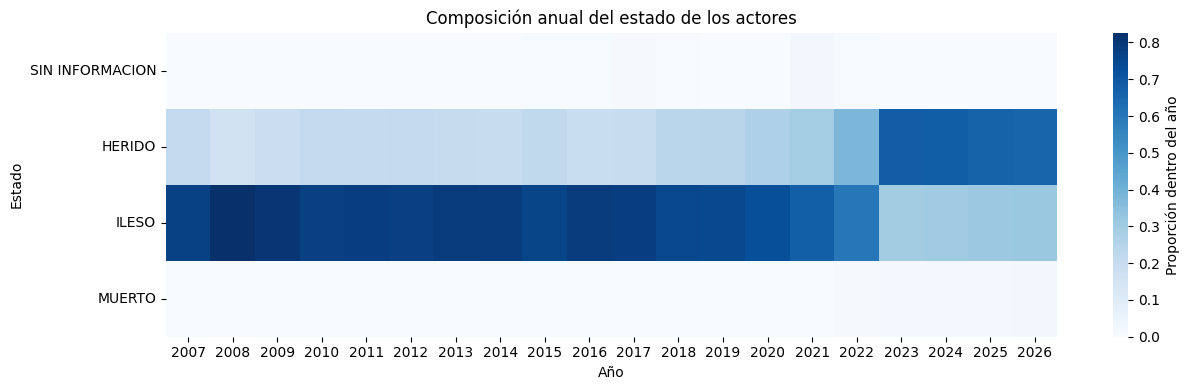

In [81]:
# Grafico de composición anual del estado de los actores
fig, ax = plt.subplots(figsize=(13, 4))
proporcion_anual = conteo_anual.div(conteo_anual.sum(axis=1), axis=0)
sns.heatmap(proporcion_anual.T, cmap='Blues', ax=ax, cbar_kws={'label': 'Proporción dentro del año'})
ax.set_title('Composición anual del estado de los actores')
ax.set_xlabel('Año')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

In [82]:
# Frecuencia de presencia de cada estado a lo largo del tiempo
resumen_estados = (
    datos.groupby('ESTADO')
    .agg(CASOS=('ACTOR_ID', 'size'), PRIMER_ANIO=('ANIO', 'min'),
         ULTIMO_ANIO=('ANIO', 'max'), ANIOS_CON_REGISTROS=('ANIO', 'nunique'))
    .reset_index()
)
resumen_estados['DESCRIPCION'] = resumen_estados['ESTADO'].map(catalogo_estados)
resumen_estados['PORCENTAJE_TOTAL'] = 100 * resumen_estados['CASOS'] / len(datos)
display(resumen_estados)

,ESTADO,CASOS,PRIMER_ANIO,ULTIMO_ANIO,ANIOS_CON_REGISTROS,DESCRIPCION,PORCENTAJE_TOTAL
0,0,6806,2007,2026,18,SIN INFORMACION,0.353102
1,1,475035,2007,2026,20,HERIDO,24.645315
2,2,1430090,2007,2026,20,ILESO,74.194573
3,3,15555,2007,2026,20,MUERTO,0.807010


#### Decisión de variables de respuesta

Se excluye `SIN INFORMACION` (`ESTADO = 0`), ya que no representa una consecuencia del accidente sino la ausencia de información sobre el estado del actor vial. Esta categoría corresponde a **6.806 registros (0,35 % del total)** y, a diferencia de las demás clases, no presenta registros en todos los años analizados. Las categorías `HERIDO`, `ILESO` y `MUERTO` se mantienen como clases de salida, dado que representan consecuencias observables del accidente y tienen presencia continua entre **2007 y 2026**. El objetivo final queda conformado exclusivamente por estas tres categorías.

In [83]:
# Retirar SIN INFORMACION antes de cualquier partición o ajuste
CODIGO_SIN_INFORMACION = 0
ESTADOS_MODELADOS = [1, 2, 3]

datos_modelo = (
    datos.loc[datos['ESTADO'].isin(ESTADOS_MODELADOS)]
    .copy()
)

registros_retirados = (datos['ESTADO'] == CODIGO_SIN_INFORMACION).sum()

print(f'Registros iniciales: {len(datos):,}')
print(f'Registros SIN INFORMACION retirados: {registros_retirados:,}')
print(f'Registros para modelado: {len(datos_modelo):,}')
print(f'Actores únicos: {datos_modelo["ACTOR_ID"].nunique():,}')
print(f'Clases conservadas: {sorted(datos_modelo["ESTADO"].unique())}')

Registros iniciales: 1,927,486
Registros SIN INFORMACION retirados: 6,806
Registros para modelado: 1,920,680
Actores únicos: 1,920,680
Clases conservadas: [1, 2, 3]


Tras retirar los registros clasificados como `SIN INFORMACION`, se conserva únicamente la población con un estado conocido (`HERIDO`, `ILESO` o `MUERTO`). Este filtro se realiza antes de cualquier partición de los datos para evitar que una categoría que no representa una consecuencia del accidente intervenga en el entrenamiento, validación o evaluación del modelo.

In [84]:
# Desbalance de los tres estados modelados
resumen_estados_modelo = (
    datos_modelo['ESTADO']
    .value_counts()
    .sort_index()
    .rename('CASOS')
    .to_frame()
)

resumen_estados_modelo['DESCRIPCION'] = [
    catalogo_estados[codigo]
    for codigo in resumen_estados_modelo.index
]

resumen_estados_modelo['PORCENTAJE'] = (
    100 * resumen_estados_modelo['CASOS'] / len(datos_modelo)
).round(4)

resumen_estados_modelo = (
    resumen_estados_modelo
    .reset_index()
    .rename(columns={'ESTADO': 'CODIGO'})
    [['CODIGO', 'DESCRIPCION', 'CASOS', 'PORCENTAJE']]
)

display(resumen_estados_modelo)

,CODIGO,DESCRIPCION,CASOS,PORCENTAJE
0,1,HERIDO,475035,24.7326
1,2,ILESO,1430090,74.4575
2,3,MUERTO,15555,0.8099


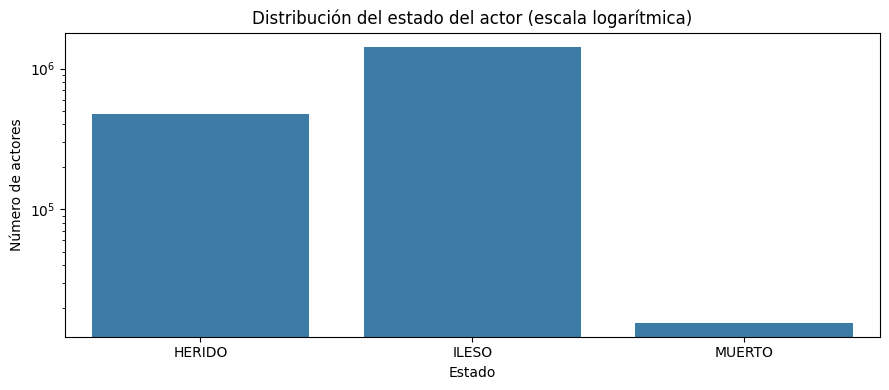

In [85]:
# Gráfico de distribución del estado del actor (escala logarítmica)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=resumen_estados_modelo.reset_index(), x='DESCRIPCION', y='CASOS', ax=ax, color='#2C7FB8')
ax.set_yscale('log')
ax.set_title('Distribución del estado del actor (escala logarítmica)')
ax.set_xlabel('Estado')
ax.set_ylabel('Número de actores')
plt.tight_layout()
plt.show()

In [86]:
# Faltantes de las variables candidatas para modelado

columnas_candidatas = list(dict.fromkeys([
    'LATITUD', 'LONGITUD', 'CELDA_X', 'CELDA_Y', 'ZONA_CIUDAD',
    'MES', 'DIA_SEMANA', 'HORA', 'GENERO', 'EDAD',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO',
    *VARIABLES_CLIMA_CRUDAS,
    'CLASE_ACCIDENTE', 'CONDICION',
    *COLUMNAS_VIA
]))

faltantes = pd.DataFrame({
    'CASOS_FALTANTES': datos_modelo[columnas_candidatas].isna().sum(),
    'PORCENTAJE_FALTANTES': (
        datos_modelo[columnas_candidatas]
        .isna()
        .mean()
        .mul(100)
        .round(4)
    )
})

faltantes = faltantes.sort_values(
    'PORCENTAJE_FALTANTES',
    ascending=False
)

display(faltantes)

,CASOS_FALTANTES,PORCENTAJE_FALTANTES
N_CARRILES,866751,45.1273
N_CALZADAS,866751,45.1273
SERVICIO_VEHICULO,125061,6.5113
CLASE_VEHICULO,125061,6.5113
EDAD,36783,1.9151
CONDICION,0,0.0000
GEOMETRIA_PLANTA,0,0.0000
GEOMETRIA_TERRENO,0,0.0000
GEOMETRIA_SECCION,0,0.0000
SENTIDO_VIA,0,0.0000


#### Análisis de valores faltantes

La mayoría de las variables candidatas presenta información completa. Los mayores niveles de ausencia se concentran en `N_CARRILES` y `N_CALZADAS`, ambas con **45,13 %** de valores faltantes, por lo que requerirán una decisión específica antes del modelado. `CLASE_VEHICULO` y `SERVICIO_VEHICULO` presentan **6,51 %** de faltantes, mientras que `EDAD` alcanza **1,92 %**. Las demás variables consideradas no presentan valores faltantes, lo que reduce la necesidad de imputación en el conjunto general de predictores.

### 2.1 Distribuciones numéricas y relaciones continuas

Se amplía el análisis descriptivo de las variables numéricas continuas mediante histogramas y una matriz de correlación. Se excluyen de este análisis los códigos asociados a variables categóricas, ya que sus valores representan etiquetas y no magnitudes numéricas comparables. Para reducir el costo computacional y facilitar la visualización, los gráficos se construyen sobre una muestra reproducible del conjunto de datos.

In [87]:
# Identificación de variables continuas 
variables_continuas = [
    'EDAD', 'CELDA_X', 'CELDA_Y', *VARIABLES_CLIMA_ORIGINALES
]

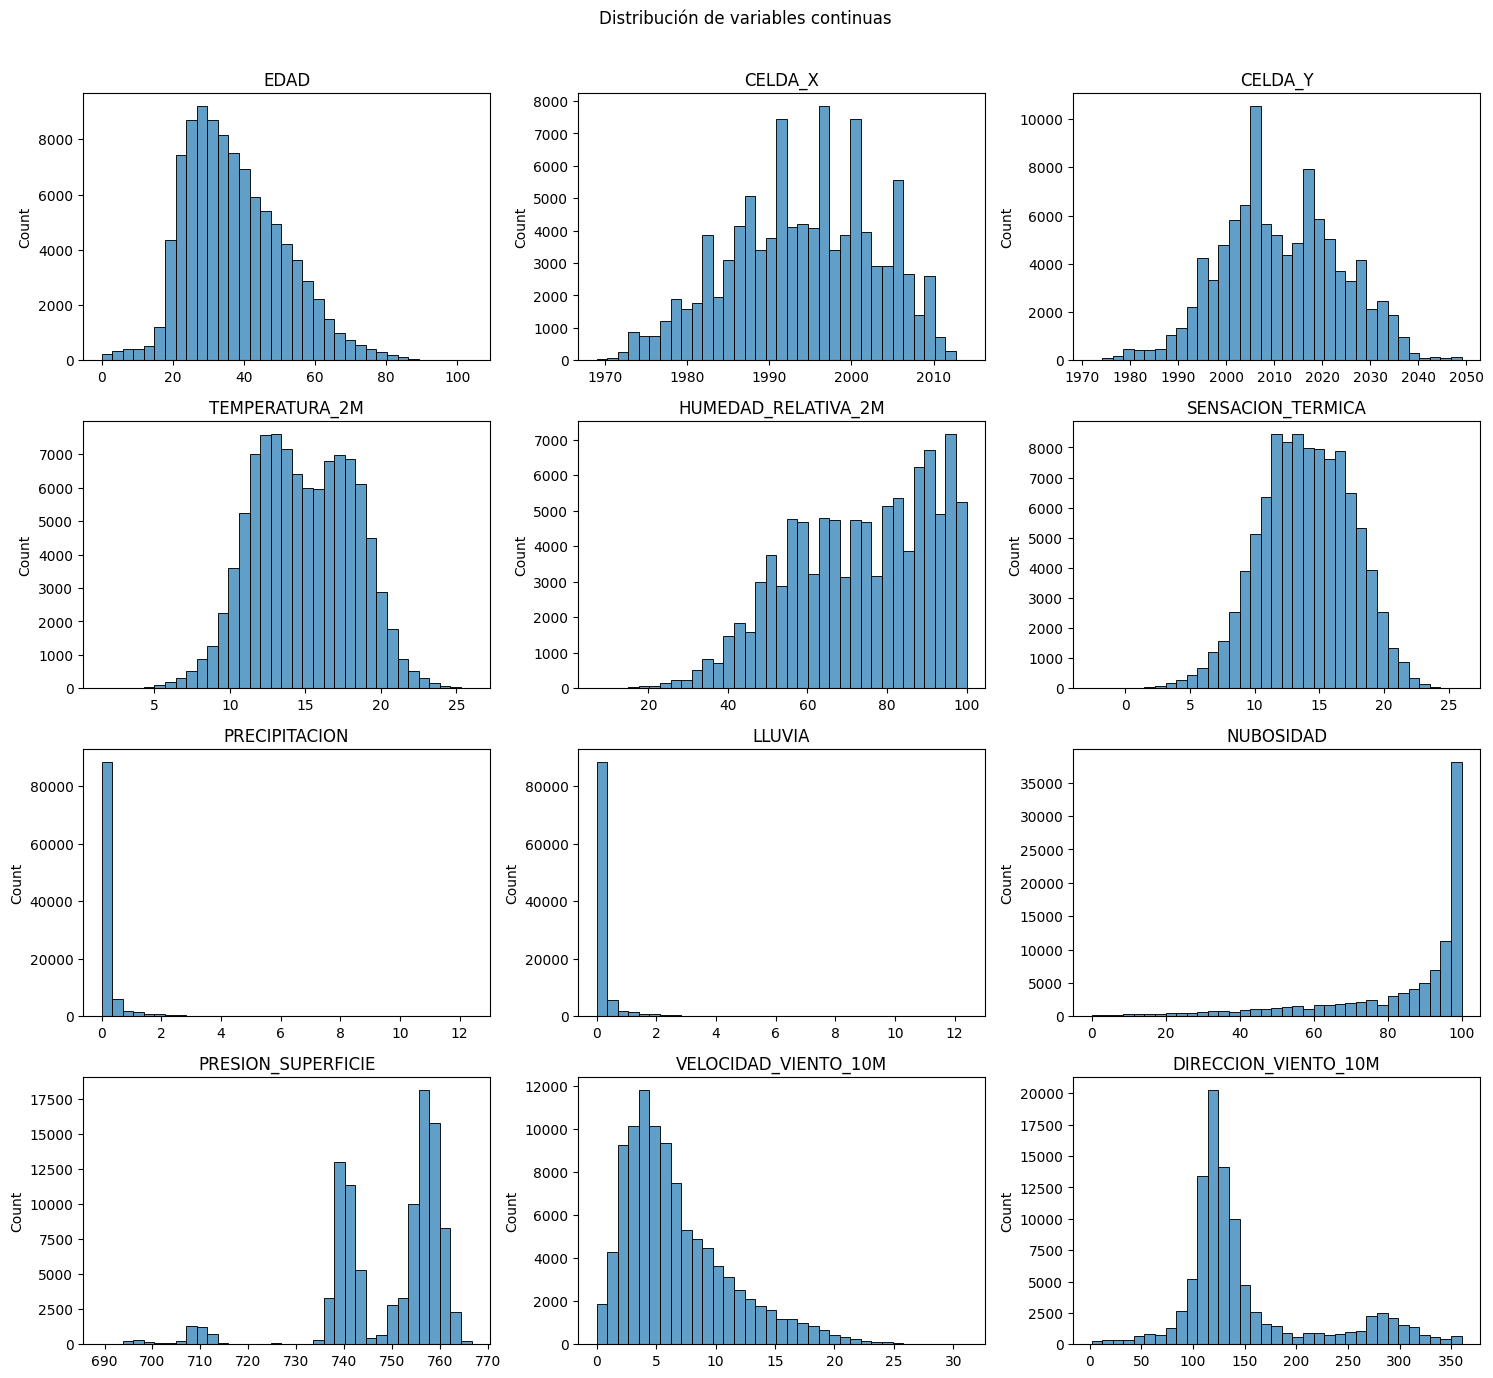

In [88]:
# Gráficos de distribución de variables continuas
muestra_descriptiva = datos_modelo[variables_continuas].sample(
    n=min(100_000, len(datos_modelo)), random_state=SEMILLA
)

columnas_grafico = 3
filas_grafico = int(np.ceil(len(variables_continuas) / columnas_grafico))
fig, axes = plt.subplots(
    filas_grafico, columnas_grafico,
    figsize=(15, 3.4 * filas_grafico)
)
for ax, columna in zip(axes.flat, variables_continuas):
    sns.histplot(muestra_descriptiva[columna], bins=35, ax=ax, color='#2C7FB8')
    ax.set_title(columna)
    ax.set_xlabel('')
for ax in axes.flat[len(variables_continuas):]:
    ax.set_visible(False)
fig.suptitle('Distribución de variables continuas', y=1.01)
plt.tight_layout()
plt.show()

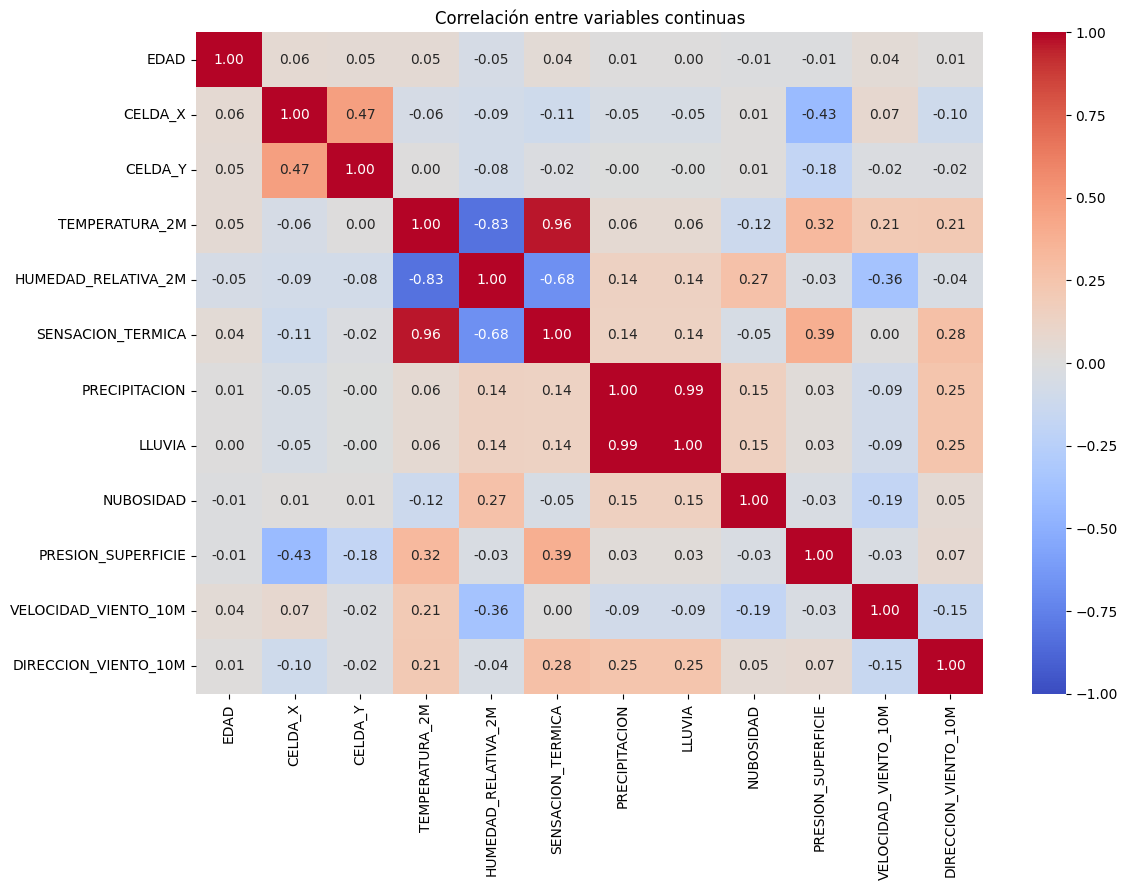

In [89]:
# Correlación entre variables continuas
correlaciones = muestra_descriptiva.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    correlaciones, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', ax=ax
)
ax.set_title('Correlación entre variables continuas')
plt.tight_layout()
plt.show()

#### Análisis de distribuciones y correlaciones

Las variables continuas presentan comportamientos diferenciados. `EDAD` muestra una distribución ligeramente sesgada hacia valores altos, mientras que `PRECIPITACION` y `LLUVIA` concentran la mayoría de observaciones cerca de cero, reflejando la predominancia de periodos sin lluvia. `NUBOSIDAD` se concentra en valores elevados y `VELOCIDAD_VIENTO_10M` presenta asimetría positiva. En la matriz de correlación destacan relaciones fuertes entre `PRECIPITACION` y `LLUVIA` (**0,99**), y entre `TEMPERATURA_2M` y `SENSACION_TERMICA` (**0,96**), además de una relación negativa alta entre `TEMPERATURA_2M` y `HUMEDAD_RELATIVA_2M` (**-0,83**). Estas asociaciones sugieren posible redundancia entre algunos predictores y deberán considerarse durante la selección de variables. La mayoría de las demás correlaciones son bajas o moderadas, por lo que no se observa una estructura generalizada de alta colinealidad.

### 2.2 Selección de variables meteorológicas por correlación

Para reducir la redundancia entre los predictores meteorológicos se establece un umbral de **correlación absoluta de 0,80**. Superar este valor no implica que una variable carezca de relevancia física, sino que ambas pueden estar aportando información muy similar al modelo. Cuando una pareja supera el umbral, se conserva la variable con una interpretación más directa y útil para el contexto operativo de PrediRuta.

In [90]:
# Selección de variables meteorológicas por correlación
UMBRAL_CORRELACION = 0.80

decisiones_correlacion = pd.DataFrame([
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'SENSACION_TERMICA',
        'JUSTIFICACION': 'Se conserva la medición directa de temperatura.'
    },
    {
        'VARIABLE_CONSERVADA': 'PRECIPITACION',
        'VARIABLE_RETIRADA': 'LLUVIA',
        'JUSTIFICACION': 'Se conserva precipitación como medida meteorológica directa.'
    },
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'HUMEDAD_RELATIVA_2M',
        'JUSTIFICACION': 'Se prioriza temperatura por su interpretación operativa directa.'
    }
])

decisiones_correlacion['CORRELACION'] = decisiones_correlacion.apply(
    lambda fila: correlaciones.loc[
        fila['VARIABLE_CONSERVADA'],
        fila['VARIABLE_RETIRADA']
    ],
    axis=1
)

decisiones_correlacion['CORRELACION_ABSOLUTA'] = (
    decisiones_correlacion['CORRELACION'].abs()
)

decisiones_correlacion['SUPERA_UMBRAL'] = (
    decisiones_correlacion['CORRELACION_ABSOLUTA'] >= UMBRAL_CORRELACION
)

# Validar que todas las decisiones cumplen el criterio definido
assert decisiones_correlacion['SUPERA_UMBRAL'].all(), (
    'Existe al menos una pareja que no supera el umbral de correlación.'
)

display(
    decisiones_correlacion[
        [
            'VARIABLE_CONSERVADA',
            'VARIABLE_RETIRADA',
            'CORRELACION',
            'CORRELACION_ABSOLUTA',
            'JUSTIFICACION'
        ]
    ].round(3)
)

,VARIABLE_CONSERVADA,VARIABLE_RETIRADA,CORRELACION,CORRELACION_ABSOLUTA,JUSTIFICACION
0,TEMPERATURA_2M,SENSACION_TERMICA,0.962,0.962,Se conserva la medición directa de temperatura.
1,PRECIPITACION,LLUVIA,0.995,0.995,Se conserva precipitación como medida meteorol...
2,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,-0.827,0.827,Se prioriza temperatura por su interpretación ...


Se retira `SENSACION_TERMICA` y se conserva `TEMPERATURA_2M`, debido a que la primera es una medida derivada y ambas presentan una correlación muy alta. De igual forma, se retira `LLUVIA` y se conserva `PRECIPITACION`, dado que en el conjunto de datos ambas variables aportan información prácticamente equivalente. Finalmente, se retira `HUMEDAD_RELATIVA_2M`; aunque representa un fenómeno físico diferente, su correlación absoluta con `TEMPERATURA_2M` supera el umbral de 0,80 establecido previamente, por lo que se aplica de manera consistente el mismo criterio de reducción de redundancia. El conjunto final de variables meteorológicas conserva `TEMPERATURA_2M`, `PRECIPITACION`, `NUBOSIDAD`, `PRESION_SUPERFICIE`, `VELOCIDAD_VIENTO_10M` y `DIRECCION_VIENTO_10M`.

### 2.3 Composición del estado por mes, día y hora

Dado que todos los registros corresponden a accidentes ya ocurridos, este análisis no evalúa la ocurrencia del evento, sino la composición relativa de sus consecuencias. Para cada mes, día de la semana y hora se calcula la proporción de `HERIDO`, `ILESO` y `MUERTO`, con el fin de identificar posibles variaciones temporales en la distribución del estado de los actores viales.

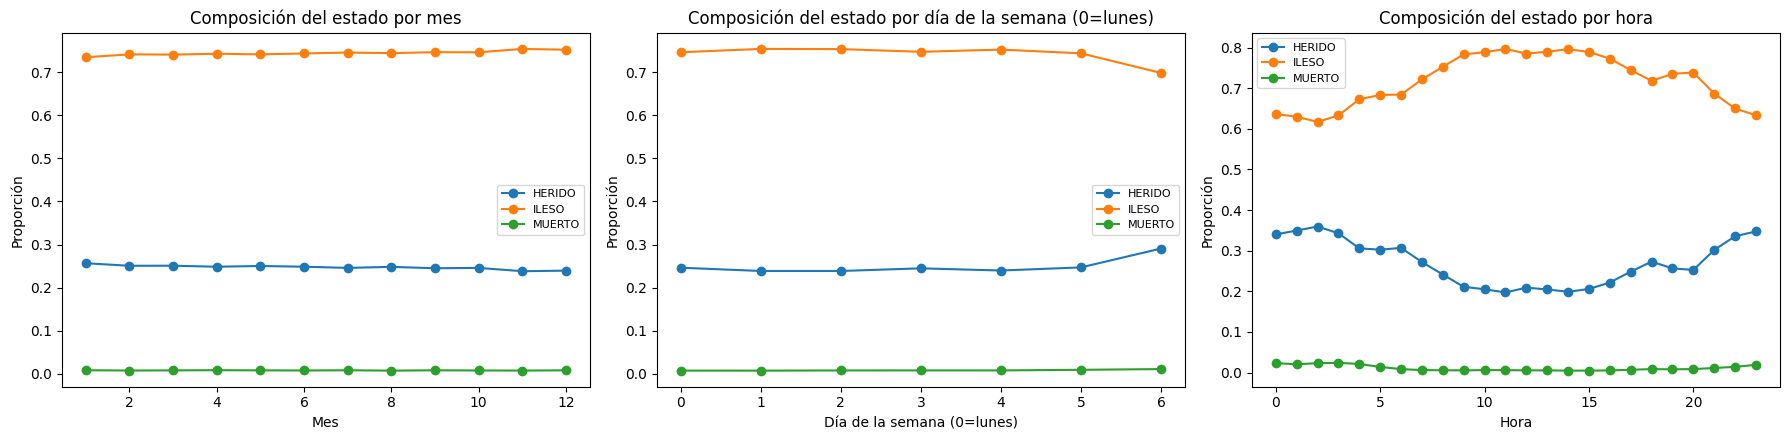

In [91]:
# Gráficos de composición del estado por mes, día de la semana y hora
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, columna, titulo in zip(
    axes, ['MES', 'DIA_SEMANA', 'HORA'],
    ['Mes', 'Día de la semana (0=lunes)', 'Hora']
):
    composicion = pd.crosstab(
        datos_modelo[columna], datos_modelo['ESTADO'], normalize='index'
    ).rename(columns=catalogo_estados)
    composicion.plot(ax=ax, marker='o', linewidth=1.5)
    ax.set_title(f'Composición del estado por {titulo.lower()}')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Proporción')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [92]:
# Estadísticas descriptivas de variables meteorológicas por estado
resumen_clima_estado = (
    datos_modelo.assign(ESTADO_DESC=datos_modelo['ESTADO'].map(catalogo_estados))
    .groupby('ESTADO_DESC')[['TEMPERATURA_2M', 'PRECIPITACION', 'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M']]
    .agg(['mean', 'median'])
)
display(resumen_clima_estado)

TEMPERATURA_2M        PRECIPITACION         NUBOSIDAD         \
                      mean median          mean median       mean median   
ESTADO_DESC                                                                
HERIDO           14.361309   14.0      0.154574    0.0  83.907407   95.0   
ILESO            14.992765   15.0      0.178012    0.0  83.785532   94.0   
MUERTO           13.916567   13.4      0.140964    0.0  84.526647   95.0   

            VELOCIDAD_VIENTO_10M         
                            mean median  
ESTADO_DESC                              
HERIDO                  6.729677    5.5  
ILESO                   6.747445    5.6  
MUERTO                  6.137506    5.1

#### Análisis temporal y climático del estado

La composición por **mes** se mantiene relativamente estable, con predominio de `ILESO`, seguido de `HERIDO` y una proporción reducida de `MUERTO`. Por **día de la semana** también se observa poca variación, aunque el domingo presenta una menor proporción de ilesos y un incremento relativo de heridos y fallecidos. Las diferencias más marcadas aparecen por **hora**: durante la madrugada y al final de la noche disminuye la proporción de `ILESO` y aumentan `HERIDO` y `MUERTO`, mientras que entre la mañana y la tarde predomina con mayor claridad el estado `ILESO`. Esto sugiere que la hora puede aportar mayor capacidad discriminante que el mes o el día de la semana para modelar el estado final del actor vial.

Las variables meteorológicas presentan diferencias descriptivas menores entre los tres estados. Los casos `MUERTO` registran, en promedio, una temperatura ligeramente menor y una menor velocidad del viento, mientras que la nubosidad permanece prácticamente estable entre las clases. La mediana de `PRECIPITACION` es cero en los tres estados, consistente con la alta concentración de observaciones sin lluvia. Estas diferencias deben interpretarse únicamente como patrones descriptivos y su aporte predictivo deberá comprobarse posteriormente mediante los modelos.

### 2.4 Descriptiva de las 150 zonas

Las 150 zonas se mantienen sin recalibración a partir de las filas de actores, ya que un accidente con varios involucrados tendría mayor peso y podría modificar artificialmente la partición espacial. Por esta razón, se reutilizan los centroides definidos previamente en el modelo de ocurrencia. La variable `ZONA_CIUDAD` se interpreta como una categoría espacial de pertenencia y no como una variable numérica con distancia u orden entre sus valores.

In [93]:
# Estadísticas descriptivas de actores y accidentes por zona
resumen_zonas = (
    datos_modelo.groupby('ZONA_CIUDAD')
    .agg(ACTORES=('ACTOR_ID', 'size'), ACCIDENTES=('ACCIDENTE_ID', 'nunique'))
    .reset_index()
    .merge(centroides_zona, on='ZONA_CIUDAD', how='left', validate='1:1')
)
composicion_zona = pd.crosstab(
    datos_modelo['ZONA_CIUDAD'], datos_modelo['ESTADO'], normalize='index'
).rename(columns=catalogo_estados)

assert len(resumen_zonas) == NUMERO_ZONAS
display(resumen_zonas[['ACTORES', 'ACCIDENTES']].describe().T)
display(resumen_zonas.nlargest(15, 'ACTORES'))

,count,mean,std,min,25%,50%,75%,max
ACTORES,150.0,12804.533333,4878.427154,622.0,9605.50,12331.0,15348.00,24561.0
ACCIDENTES,150.0,5960.126667,2278.705506,283.0,4475.25,5729.0,7182.25,11640.0


,ZONA_CIUDAD,ACTORES,ACCIDENTES,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
51,51,24561,11640,4.720632,-74.051823
29,29,24106,11327,4.644874,-74.062205
76,76,24010,11511,4.603915,-74.074688
70,70,23340,10823,4.629379,-74.080767
12,12,23320,10825,4.630131,-74.119967
116,116,23307,10602,4.629776,-74.136337
102,102,21913,10142,4.598093,-74.091137
41,41,21893,10209,4.697094,-74.087579
5,5,21856,10097,4.640591,-74.157047
40,40,21781,10282,4.612003,-74.070541


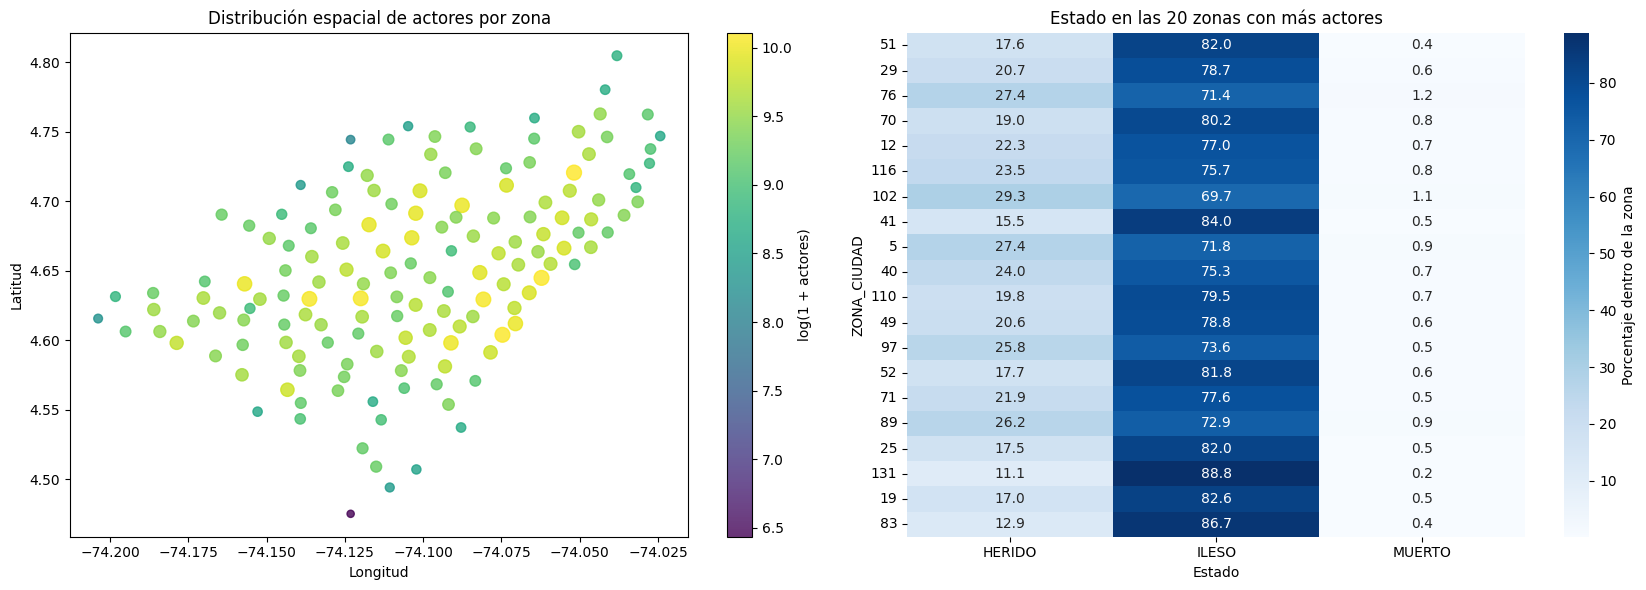

In [94]:
# Gráficos de distribución espacial de actores por zona y composición del estado en las zonas con más actores
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
dispersion = axes[0].scatter(
    resumen_zonas['LONGITUD_CENTROIDE'], resumen_zonas['LATITUD_CENTROIDE'],
    c=np.log1p(resumen_zonas['ACTORES']),
    s=25 + 90 * resumen_zonas['ACTORES'] / resumen_zonas['ACTORES'].max(),
    cmap='viridis', alpha=0.8
)
axes[0].set_title('Distribución espacial de actores por zona')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
fig.colorbar(dispersion, ax=axes[0], label='log(1 + actores)')

zonas_mayor_volumen = resumen_zonas.nlargest(20, 'ACTORES')['ZONA_CIUDAD']
sns.heatmap(
    100 * composicion_zona.loc[zonas_mayor_volumen],
    cmap='Blues', annot=True, fmt='.1f', ax=axes[1],
    cbar_kws={'label': 'Porcentaje dentro de la zona'}
)
axes[1].set_title('Estado en las 20 zonas con más actores')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('ZONA_CIUDAD')
plt.tight_layout()
plt.show()

#### Análisis de las zonas

Las 150 zonas presentan una distribución heterogénea en el número de actores y accidentes. En promedio se registran cerca de **12.805 actores** y **5.960 accidentes por zona**, aunque existen diferencias importantes entre sectores; la zona `51` concentra el mayor número de actores (**24.561**) y accidentes (**11.640**). En las zonas con mayor volumen de registros continúa predominando la categoría `ILESO`, aunque su participación varía aproximadamente entre **70 % y 89 %**, mientras que `HERIDO` muestra una variación mayor entre zonas. La proporción de `MUERTO` se mantiene reducida, generalmente alrededor o por debajo del **1 %**. Estas diferencias sugieren que la ubicación espacial puede aportar información relevante para distinguir la composición del estado de los actores.

## 3. Definición de los conjuntos de variables

Se definen dos conjuntos de predictores con propósitos diferentes. El conjunto **completo** mantiene la estructura evaluada en el notebook anterior y se utiliza como referencia o techo experimental. Incluye variables disponibles al documentar un accidente, aunque algunas de ellas no estarían disponibles en el momento de realizar una consulta de ruta; por esta razón, su desempeño no representa directamente un escenario de uso en producción.

El conjunto **operativo** se restringe a información que puede ser ingresada por el usuario o derivada en el momento de la consulta: ubicación y `ZONA_CIUDAD` asociada a la celda de 500 m, fecha y hora, edad y género del usuario, clase y servicio del vehículo y, en los escenarios correspondientes, variables meteorológicas pronosticadas. Se excluyen `CLASE_ACCIDENTE`, `CONDICION`, `N_CALZADAS`, `N_CARRILES` y las categorías detalladas de la vía, debido a que no forman parte de la información disponible para la consulta operativa definida en el MVP.

Para los escenarios con clima también se excluyen `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M`, de acuerdo con el criterio de reducción de redundancia establecido en el análisis descriptivo mediante un umbral de correlación absoluta de **0,80**.

In [95]:
# Crear variables cíclicas para representar correctamente
# la periodicidad temporal y la dirección del viento

def agregar_variables_ciclicas(df):
    salida = df.copy()

    ciclos = {
        'MES': 12,
        'DIA_SEMANA': 7,
        'HORA': 24,
        'DIRECCION_VIENTO_10M': 360
    }

    for columna, periodo in ciclos.items():
        angulo = 2 * np.pi * salida[columna].astype(float) / periodo

        salida[f'{columna}_SIN'] = np.sin(angulo)
        salida[f'{columna}_COS'] = np.cos(angulo)

    return salida


datos_modelo = agregar_variables_ciclicas(datos_modelo)

In [96]:
# Variables disponibles en los escenarios operativos

NUMERICAS_COMUNES = [
    'CELDA_X', 'CELDA_Y', 'EDAD',
    'MES_SIN', 'MES_COS',
    'DIA_SEMANA_SIN', 'DIA_SEMANA_COS',
    'HORA_SIN', 'HORA_COS'
]

CATEGORICAS_COMUNES = [
    'MES', 'DIA_SEMANA', 'HORA',
    'ZONA_CIUDAD', 'GENERO',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO'
]

PREDICTORES_CLIMA = [
    'TEMPERATURA_2M',
    'PRECIPITACION',
    'NUBOSIDAD',
    'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M',
    'DIRECCION_VIENTO_10M_SIN',
    'DIRECCION_VIENTO_10M_COS'
]

In [97]:
# Variables adicionales disponibles únicamente
# para el escenario completo experimental

NUMERICAS_COMPLETAS = [
    *NUMERICAS_COMUNES,
    *COLUMNAS_VIA_NUMERICAS
]

CATEGORICAS_COMPLETAS = [
    *CATEGORICAS_COMUNES,
    'CLASE_ACCIDENTE',
    'CONDICION',
    *COLUMNAS_VIA_CATEGORICAS
]

In [98]:
# Escenarios experimentales

ESCENARIOS = {
    'COMPLETO_SIN_CLIMA': {
        'numericas': NUMERICAS_COMPLETAS,
        'categoricas': CATEGORICAS_COMPLETAS
    },

    'COMPLETO_CON_CLIMA': {
        'numericas': [
            *NUMERICAS_COMPLETAS,
            *PREDICTORES_CLIMA
        ],
        'categoricas': CATEGORICAS_COMPLETAS
    },

    'OPERATIVO_SIN_CLIMA': {
        'numericas': NUMERICAS_COMUNES,
        'categoricas': CATEGORICAS_COMUNES
    },

    'OPERATIVO_CON_CLIMA': {
        'numericas': [
            *NUMERICAS_COMUNES,
            *PREDICTORES_CLIMA
        ],
        'categoricas': CATEGORICAS_COMUNES
    }
}

In [99]:
# Variables no permitidas en los escenarios operativos

VARIABLES_NO_DISPONIBLES = {
    'CLASE_ACCIDENTE',
    'CONDICION',
    *COLUMNAS_VIA_NUMERICAS,
    *COLUMNAS_VIA_CATEGORICAS
}

VARIABLES_POSTEVENTO_BLOQUEADAS = {
    'ESTADO',
    'OBJETIVO_GRAVE',
    'CANTIDAD_HERIDOS',
    'CANTIDAD_MUERTOS',
    'ACCIDENTE_ID',
    'ACTOR_ID',
    'VEHICULO_ID',
    'CLIMA_ID'
}


for nombre, grupos in ESCENARIOS.items():

    variables = grupos['numericas'] + grupos['categoricas']

    # Evitar variables duplicadas
    assert len(variables) == len(set(variables)), (
        f'Hay variables duplicadas en {nombre}'
    )

    # Evitar información objetivo, identificadores o variables postevento
    assert not (set(variables) & VARIABLES_POSTEVENTO_BLOQUEADAS), (
        f'{nombre} contiene variables postevento bloqueadas'
    )

    # Los escenarios operativos solo pueden utilizar información disponible
    if nombre.startswith('OPERATIVO'):
        assert not (set(variables) & VARIABLES_NO_DISPONIBLES), (
            f'{nombre} contiene variables no disponibles operativamente'
        )

In [100]:
# Resumen de los conjuntos de variables

resumen_escenarios = pd.DataFrame([
    {
        'ESCENARIO': nombre,
        'NUMERICAS': len(grupos['numericas']),
        'CATEGORICAS': len(grupos['categoricas']),
        'TOTAL_ENTRADAS': (
            len(grupos['numericas']) +
            len(grupos['categoricas'])
        )
    }
    for nombre, grupos in ESCENARIOS.items()
])

display(resumen_escenarios)

display(
    pd.DataFrame({
        'VARIABLE_RETIRADA_DEL_OPERATIVO':
            sorted(VARIABLES_NO_DISPONIBLES)
    })
)

,ESCENARIO,NUMERICAS,CATEGORICAS,TOTAL_ENTRADAS
0,COMPLETO_SIN_CLIMA,11,18,29
1,COMPLETO_CON_CLIMA,18,18,36
2,OPERATIVO_SIN_CLIMA,9,7,16
3,OPERATIVO_CON_CLIMA,16,7,23


,VARIABLE_RETIRADA_DEL_OPERATIVO
0,CLASE_ACCIDENTE
1,CONDICION
2,CONDICION_VIA
3,ESTADO_VIA
4,GEOMETRIA_PLANTA
5,GEOMETRIA_SECCION
6,GEOMETRIA_TERRENO
7,ILUMINACION_ARTIFICIAL
8,N_CALZADAS
9,N_CARRILES


#### Análisis de los escenarios de variables

La definición final genera cuatro escenarios comparables. El conjunto `COMPLETO_SIN_CLIMA` utiliza **29 variables de entrada**, mientras que `COMPLETO_CON_CLIMA` aumenta a **36** al incorporar los siete predictores meteorológicos seleccionados. Por su parte, los escenarios operativos reducen la información a **16 variables sin clima** y **23 con clima**. Esta reducción corresponde a la exclusión de **13 variables** asociadas con características del accidente y de la vía que no estarían disponibles de forma consistente durante una consulta de PrediRuta. De esta manera, los escenarios completos funcionan como referencia experimental y los operativos representan una aproximación más cercana al uso real del sistema.

## 4. Partición temporal de entrenamiento, validación y prueba

La partición de los datos se realiza de forma temporal y no aleatoria, con el fin de evaluar la capacidad del modelo para generalizar hacia periodos futuros. Además, todos los actores asociados a un mismo accidente permanecen dentro del mismo subconjunto, evitando que información de un mismo evento aparezca simultáneamente en entrenamiento y evaluación.

Los periodos definidos son:

- **Entrenamiento:** 2007–2020.
- **Validación y selección de modelos:** 2021–2023.
- **Prueba final:** 2024–2026.

La variable `ANIO` se utiliza únicamente para construir estos cortes temporales y se excluye de la matriz de predictores `X`, por lo que no interviene directamente en el entrenamiento de los modelos.

In [101]:
# Definición de los cortes temporales

ANIO_FIN_ENTRENAMIENTO = 2020
ANIO_FIN_VALIDACION = 2023
ANIO_FIN_PRUEBA = 2026

mascara_train = (
    datos_modelo['ANIO'] <= ANIO_FIN_ENTRENAMIENTO
)

mascara_val = datos_modelo['ANIO'].between(
    ANIO_FIN_ENTRENAMIENTO + 1,
    ANIO_FIN_VALIDACION
)

mascara_test = datos_modelo['ANIO'].between(
    ANIO_FIN_VALIDACION + 1,
    ANIO_FIN_PRUEBA
)

In [102]:
# Codificación de la variable objetivo

encoder_objetivo = LabelEncoder()
encoder_objetivo.fit(ESTADOS_MODELADOS)

clases_codificadas = np.arange(
    len(encoder_objetivo.classes_)
)


def construir_xy(mascara, escenario):

    columnas = (
        ESCENARIOS[escenario]['numericas']
        + ESCENARIOS[escenario]['categoricas']
    )

    X = (
        datos_modelo.loc[mascara, columnas]
        .reset_index(drop=True)
    )

    y_original = (
        datos_modelo.loc[mascara, 'ESTADO']
        .to_numpy()
    )

    y = encoder_objetivo.transform(y_original)

    return X, y


# Particiones de referencia
X_train_referencia, y_train = construir_xy(
    mascara_train,
    'COMPLETO_CON_CLIMA'
)

X_val_referencia, y_val = construir_xy(
    mascara_val,
    'COMPLETO_CON_CLIMA'
)

X_test_referencia, y_test = construir_xy(
    mascara_test,
    'COMPLETO_CON_CLIMA'
)

In [103]:
# Validar que las particiones no se superponen

assert not (mascara_train & mascara_val).any()
assert not (mascara_train & mascara_test).any()
assert not (mascara_val & mascara_test).any()


# Validar que un accidente no aparezca en más de una partición

accidentes_train = set(
    datos_modelo.loc[mascara_train, 'ACCIDENTE_ID']
)

accidentes_val = set(
    datos_modelo.loc[mascara_val, 'ACCIDENTE_ID']
)

accidentes_test = set(
    datos_modelo.loc[mascara_test, 'ACCIDENTE_ID']
)

assert accidentes_train.isdisjoint(accidentes_val)
assert accidentes_train.isdisjoint(accidentes_test)
assert accidentes_val.isdisjoint(accidentes_test)


# Validar presencia de las tres clases en cada partición

assert set(np.unique(y_train)) == set(clases_codificadas)
assert set(np.unique(y_val)) == set(clases_codificadas)
assert set(np.unique(y_test)) == set(clases_codificadas)

In [104]:
# Resumen de las particiones temporales

resumen_particiones = []

for nombre, mascara, y_particion in [
    ('ENTRENAMIENTO', mascara_train, y_train),
    ('VALIDACION', mascara_val, y_val),
    ('PRUEBA', mascara_test, y_test)
]:

    resumen_particiones.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[
            mascara, 'ACCIDENTE_ID'
        ].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[
            mascara, 'FECHA_HORA'
        ].min(),
        'FECHA_MAXIMA': datos_modelo.loc[
            mascara, 'FECHA_HORA'
        ].max(),
        'CLASES_PRESENTES': len(
            np.unique(y_particion)
        )
    })

resumen_particiones = pd.DataFrame(
    resumen_particiones
)

display(resumen_particiones)

,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO,1696736,794835,2007-01-01 00:00:00,2020-12-31 22:34:00,3
1,VALIDACION,148173,67322,2021-01-01 00:30:00,2023-12-31 23:30:00,3
2,PRUEBA,75771,31862,2024-01-01 00:27:00,2026-07-20 08:45:00,3


In [105]:
# Distribución porcentual de las clases por partición

distribucion_particiones = pd.DataFrame({
    'ENTRENAMIENTO': pd.Series(
        y_train
    ).value_counts(normalize=True),

    'VALIDACION': pd.Series(
        y_val
    ).value_counts(normalize=True),

    'PRUEBA': pd.Series(
        y_test
    ).value_counts(normalize=True)
}).fillna(0)

distribucion_particiones.index = [
    catalogo_estados[
        encoder_objetivo.inverse_transform([codigo])[0]
    ]
    for codigo in distribucion_particiones.index
]

display(
    (100 * distribucion_particiones)
    .round(3)
)

,ENTRENAMIENTO,VALIDACION,PRUEBA
HERIDO,21.362,41.717,66.997
ILESO,77.901,57.238,31.021
MUERTO,0.737,1.045,1.982


#### Análisis de las particiones temporales

Las tres particiones mantienen presencia de `HERIDO`, `ILESO` y `MUERTO`, pero presentan un cambio importante en su distribución temporal. En entrenamiento predomina `ILESO` con **77,90 %**, mientras que su participación disminuye a **57,24 %** en validación y a **31,02 %** en prueba. En contraste, `HERIDO` aumenta de **21,36 %** a **41,72 %** y posteriormente a **67,00 %**. La clase `MUERTO` continúa siendo minoritaria, aunque también incrementa su proporción de **0,74 %** a **1,98 %**. Este comportamiento evidencia un cambio temporal en la composición del objetivo, por lo que la partición representa una prueba exigente de generalización y hace especialmente importante evaluar el desempeño por clase, además de las métricas globales.

## 5. Preprocesamiento y métricas

Las variables categóricas se transforman mediante **one-hot encoding**, mientras que las variables numéricas se imputan y estandarizan dentro de cada `Pipeline`. De esta forma, todo el preprocesamiento se ajusta exclusivamente con los datos de entrenamiento y se evita fuga de información hacia validación o prueba.

Aunque se excluyó la categoría `SIN INFORMACION`, la variable objetivo continúa desbalanceada, principalmente por la baja frecuencia de `MUERTO` frente a `HERIDO` e `ILESO`. Por esta razón, la selección de modelos se basa principalmente en **F1 macro** y **balanced accuracy**, ya que ambas métricas consideran el desempeño entre clases de forma más equilibrada. Como complemento se reportan **accuracy** y **F1 ponderado**, pero no se utilizan como criterio principal de selección.

In [106]:
# Funciones auxiliares para preprocesamiento y evaluación de modelos

def crear_preprocesador(escenario): # Función para crear un preprocesador de datos basado en el escenario seleccionado
    grupos = ESCENARIOS[escenario]
    pipeline_numerico = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    return ColumnTransformer([
        ('numericas', pipeline_numerico, grupos['numericas']),
        ('categoricas', pipeline_categorico, grupos['categoricas']),
    ], remainder='drop')

def ordenar_probabilidades(modelo, X, clases_esperadas): # Función para ordenar las probabilidades predichas por el modelo según las clases esperadas
    probabilidades = modelo.predict_proba(X)
    clases_modelo = np.asarray(modelo.classes_)
    salida = np.zeros((len(X), len(clases_esperadas)), dtype=float)
    for posicion, clase in enumerate(clases_esperadas):
        coincidencia = np.where(clases_modelo == clase)[0]
        if len(coincidencia):
            salida[:, posicion] = probabilidades[:, coincidencia[0]]
    suma = salida.sum(axis=1, keepdims=True)
    return np.divide(salida, suma, out=np.zeros_like(salida), where=suma > 0)

def error_calibracion_esperado(y_real, probabilidades, n_bins=10): # Función para calcular el error de calibración esperado (ECE) de un modelo de clasificación
    confianza = probabilidades.max(axis=1)
    prediccion = probabilidades.argmax(axis=1)
    acierto = (prediccion == y_real).astype(float)
    limites = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for inferior, superior in zip(limites[:-1], limites[1:]):
        mascara = (confianza > inferior) & (confianza <= superior)
        if mascara.any():
            ece += mascara.mean() * abs(acierto[mascara].mean() - confianza[mascara].mean())
    return ece

def calcular_metricas(y_real, probabilidades, clases=clases_codificadas): # Función para calcular métricas de evaluación de un modelo de clasificación
    prediccion = clases[np.argmax(probabilidades, axis=1)]
    y_binaria = LabelBinarizer().fit(clases).transform(y_real)
    onehot_real = np.eye(len(clases))[y_real]
    metricas = {
        'Accuracy': accuracy_score(y_real, prediccion),
        'Balanced_Accuracy': balanced_accuracy_score(y_real, prediccion),
        'F1_macro': f1_score(y_real, prediccion, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_real, prediccion, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_binaria, probabilidades, average='macro'),
        'ROC_AUC_OVR_macro': roc_auc_score(y_real, probabilidades, labels=clases, multi_class='ovr', average='macro'),
        'Log_Loss': log_loss(y_real, probabilidades, labels=clases),
        'Brier_multiclase': np.mean(np.sum((probabilidades - onehot_real) ** 2, axis=1)),
        'ECE_10_bins': error_calibracion_esperado(y_real, probabilidades, n_bins=10),
    }
    return metricas

def pesos_clase_suaves(y, potencia=0.50): # Función para calcular pesos de clase suaves para abordar el desbalance de clases en un conjunto de datos
    clases, conteos = np.unique(y, return_counts=True)
    maximo = conteos.max()
    return {
        int(clase): float(min((maximo / conteo) ** potencia, 25.0))
        for clase, conteo in zip(clases, conteos)
    }

In [107]:
# Muestra común de ajuste: mismas filas para todos los escenarios
TAMANO_MUESTRA_AJUSTE = 300_000

def indices_muestra_ajuste(y, tamano=TAMANO_MUESTRA_AJUSTE, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    cantidad = min(len(y), tamano)
    return np.sort(rng.choice(len(y), size=cantidad, replace=False))

def balancear_para_mlp(X, y, cantidad_por_clase=25_000, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    seleccionados = []
    for clase in np.unique(y):
        indices = np.flatnonzero(y == clase)
        seleccionados.append(rng.choice(indices, size=cantidad_por_clase, replace=len(indices) < cantidad_por_clase))
    seleccionados = rng.permutation(np.concatenate(seleccionados))
    return X.iloc[seleccionados].reset_index(drop=True), y[seleccionados]

indices_ajuste = indices_muestra_ajuste(y_train)
y_ajuste = y_train[indices_ajuste]

distribucion_muestra = pd.DataFrame({
    'ENTRENAMIENTO_COMPLETO': pd.Series(y_train).value_counts(normalize=True),
    'MUESTRA_AJUSTE': pd.Series(y_ajuste).value_counts(normalize=True),
}).sort_index()
distribucion_muestra.index = [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_]
display((100 * distribucion_muestra).round(3))

,ENTRENAMIENTO_COMPLETO,MUESTRA_AJUSTE
HERIDO,21.362,21.260
ILESO,77.901,77.987
MUERTO,0.737,0.753


#### Representatividad de la muestra de ajuste

La muestra utilizada para el ajuste conserva prácticamente la misma distribución de clases que el conjunto completo de entrenamiento. `HERIDO`, `ILESO` y `MUERTO` presentan diferencias inferiores a **0,11 puntos porcentuales**, por lo que el muestreo mantiene adecuadamente el desbalance original y puede utilizarse para comparar configuraciones de modelos sin alterar de forma relevante la composición del objetivo.

## 6. Línea base

La línea base se construye con un `DummyClassifier` que utiliza únicamente la prevalencia histórica de las clases observada en el conjunto de entrenamiento. Este modelo no emplea variables predictoras y asigna a cada observación las mismas probabilidades asociadas a `HERIDO`, `ILESO` y `MUERTO`.

Su función es establecer un nivel mínimo de referencia para evaluar si los modelos candidatos realmente están aprendiendo patrones a partir de los predictores. Un modelo se considerará útil si supera esta línea base en las métricas principales y, especialmente, si logra identificar la clase `MUERTO`, evitando valores de recall o F1 iguales a cero para esta categoría minoritaria.

In [108]:
# Línea base basada en la prevalencia histórica de las clases

baseline = DummyClassifier(
    strategy='prior',
    random_state=SEMILLA
)

# DummyClassifier requiere una matriz X, aunque no utiliza sus valores
X_dummy_train = np.zeros((len(y_train), 1))
X_dummy_val = np.zeros((len(y_val), 1))

baseline.fit(X_dummy_train, y_train)

# Obtener probabilidades y mantener el mismo orden de clases
proba_baseline_val = ordenar_probabilidades(
    baseline,
    X_dummy_val,
    clases_codificadas
)

# Evaluar la línea base sobre el conjunto de validación
metricas_baseline = calcular_metricas(
    y_val,
    proba_baseline_val
)

resultado_baseline = pd.DataFrame([{
    'MODELO': 'BASELINE_PRIOR',
    **metricas_baseline
}])

display(resultado_baseline)

,MODELO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,BASELINE_PRIOR,0.572378,0.333333,0.24268,0.416715,0.333333,0.5,0.838195,0.582382,0.206632


#### Desempeño de la línea base

La línea base alcanza una **accuracy de 57,24 %**, correspondiente principalmente a la clase mayoritaria en validación, pero obtiene una **balanced accuracy de 0,333** y un **F1 macro de 0,243**, evidenciando que no tiene capacidad para discriminar adecuadamente entre las tres clases. El `ROC_AUC_OVR_macro` de **0,50** confirma un comportamiento sin capacidad discriminante, mientras que el `PR_AUC_macro` de **0,333** establece una referencia mínima para los modelos candidatos. Estos resultados constituyen el punto de comparación que los modelos entrenados deberán superar, especialmente en la identificación de las clases minoritarias.

## 7. Evaluación de modelos

In [109]:
# Preparar los cuatro escenarios sobre exactamente las mismas filas
datos_escenario = {}

for escenario in ESCENARIOS:
    X_train_esc, _ = construir_xy(mascara_train, escenario)
    X_val_esc, _ = construir_xy(mascara_val, escenario)

    datos_escenario[escenario] = {
        'ajuste': X_train_esc.iloc[indices_ajuste].reset_index(drop=True),
        'validacion': X_val_esc
    }

# Contenedores comunes para consolidar todas las familias en la sección 8
resultados_ajuste_acumulados = []
resultados_validacion = [{
    'MODELO': 'BASELINE_PRIOR',
    'ALCANCE': 'BASELINE',
    'CLIMA': 'SIN_PREDICTORES',
    'ESCENARIO': 'SIN_PREDICTORES',
    'SEGUNDOS_AJUSTE': 0.0,
    **metricas_baseline
}]
mejores_parametros = {}
modelos_validacion = {}
probabilidades_validacion = {}

In [130]:
# Funciones comunes: construcción, ajuste y gráfico de las configuraciones

def crear_modelo(nombre, escenario, parametros, y_referencia): # Función para crear un modelo de clasificación basado en el nombre del modelo, escenario y parámetros proporcionados
    preprocesador = crear_preprocesador(escenario)
    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso', 0.50)
    pesos = pesos_clase_suaves(y_referencia, potencia=potencia_peso)

    if nombre == 'REGRESION_LOGISTICA': # Función para crear un modelo de regresión logística con regularización y pesos de clase
        estimador = LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'RANDOM_FOREST': # Función para crear un modelo de Random Forest con pesos de clase y muestreo aleatorio
        estimador = RandomForestClassifier(
            **parametros_modelo,
            class_weight=pesos,
            max_samples=0.75,
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'XGBOOST': # Función para crear un modelo de XGBoost con pesos de clase y parámetros específicos para clasificación multiclase
        estimador = XGBClassifier(
            **parametros_modelo,
            objective='multi:softprob',
            eval_metric='mlogloss',
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            tree_method='hist',
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'MLP': # Función para crear un modelo de Perceptrón Multicapa (MLP) con pesos de clase y parámetros específicos para clasificación multiclase
        estimador = MLPClassifier(
            **parametros_modelo,
            activation='relu',
            solver='adam',
            batch_size=1024,
            max_iter=60,
            early_stopping=True,
            validation_fraction=0.12,
            n_iter_no_change=5,
            tol=0.001,
            random_state=SEMILLA
        )
    else:
        raise ValueError(f'Modelo no reconocido: {nombre}')

    return Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', estimador)
    ])


def ajustar_modelo(nombre, escenario, parametros, X, y): # Función para ajustar un modelo de clasificación basado en el nombre del modelo, escenario y parámetros proporcionados
    X_entrenar = X
    y_entrenar = y

    if nombre == 'MLP':
        X_entrenar, y_entrenar = balancear_para_mlp(X, y)

    modelo = crear_modelo(
        nombre,
        escenario,
        parametros,
        y_entrenar
    )

    inicio = perf_counter()

    if nombre == 'XGBOOST':
        pesos = pesos_clase_suaves(
            y_entrenar,
            potencia=parametros.get('potencia_peso', 0.50)
        )
        pesos_observacion = np.array([
            pesos[int(clase)] for clase in y_entrenar
        ])
        modelo.fit(
            X_entrenar,
            y_entrenar,
            modelo__sample_weight=pesos_observacion
        )
    else:
        modelo.fit(X_entrenar, y_entrenar)

    return modelo, perf_counter() - inicio



def formatear_valor_parametro(valor): # Función para formatear el valor de un parámetro para su visualización en gráficos y tablas
    if isinstance(valor, list):
        return ' × '.join(str(elemento) for elemento in valor)
    if isinstance(valor, float):
        return f'{valor:g}'
    return str(valor)


def graficar_configuraciones(tabla, titulo): # Función para graficar el desempeño de las configuraciones
    """Muestra desempeño por configuración y sensibilidad descriptiva por parámetro."""
    ordenada = tabla.sort_values(['ALCANCE', 'CONFIGURACION']).copy()
    alcances = ['COMPLETO', 'OPERATIVO']
    metricas_principales = ['F1_macro', 'Balanced_Accuracy']

    # Gráfica 1: comparar las métricas principales de cada configuración
    metricas_largas = ordenada.melt(
        id_vars=['ALCANCE', 'CONFIGURACION'],
        value_vars=metricas_principales,
        var_name='METRICA',
        value_name='VALOR'
    )
    minimo_metricas = min(
        metricas_largas['VALOR'].min(),
        metricas_baseline['F1_macro']
    )
    maximo_metricas = metricas_largas['VALOR'].max()
    margen_metricas = max(0.02, 0.12 * (maximo_metricas - minimo_metricas))
    limites_metricas = (
        max(0, minimo_metricas - margen_metricas),
        min(1, maximo_metricas + margen_metricas)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, alcance in zip(axes, alcances):
        datos_alcance = metricas_largas.query('ALCANCE == @alcance')
        sns.lineplot(
            data=datos_alcance,
            x='CONFIGURACION',
            y='VALOR',
            hue='METRICA',
            style='METRICA',
            markers=True,
            dashes=False,
            estimator=None,
            ax=ax
        )

        mejor = (
            ordenada.query('ALCANCE == @alcance')
            .sort_values(
                ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
                ascending=[False, False, True]
            )
            .iloc[0]
        )
        ax.scatter(
            mejor['CONFIGURACION'],
            mejor['F1_macro'],
            marker='*',
            s=230,
            color='black',
            zorder=5,
            label='Mejor configuración'
        )
        ax.axhline(
            metricas_baseline['F1_macro'],
            color='gray',
            linestyle='--',
            label='F1 macro de línea base'
        )
        ax.set_xticks(sorted(datos_alcance['CONFIGURACION'].unique()))
        ax.set_xlabel('Número de configuración')
        ax.set_ylabel('Valor en validación')
        ax.set_title(f'{alcance.title()}')
        ax.set_ylim(*limites_metricas)
        ax.grid(axis='y', alpha=0.25)

    axes[1].legend().remove()
    axes[0].legend(title='Métrica / referencia', loc='best')
    fig.suptitle(f'{titulo}: métricas por configuración', y=1.03)
    plt.tight_layout()
    plt.show()

    # Preparar una fila por configuración y parámetro
    registros_parametros = []
    for _, fila in ordenada.iterrows():
        parametros = json.loads(fila['PARAMETROS'])
        for parametro, valor in parametros.items():
            registros_parametros.append({
                'ALCANCE': fila['ALCANCE'],
                'CONFIGURACION': fila['CONFIGURACION'],
                'PARAMETRO': parametro,
                'VALOR_PARAMETRO': formatear_valor_parametro(valor),
                'F1_macro': fila['F1_macro']
            })

    sensibilidad = pd.DataFrame(registros_parametros)
    minimo_sensibilidad = sensibilidad['F1_macro'].min()
    maximo_sensibilidad = sensibilidad['F1_macro'].max()
    margen_sensibilidad = max(
        0.01,
        0.15 * (maximo_sensibilidad - minimo_sensibilidad)
    )
    limites_sensibilidad = (
        max(0, minimo_sensibilidad - margen_sensibilidad),
        min(1, maximo_sensibilidad + margen_sensibilidad)
    )
    parametros = sensibilidad['PARAMETRO'].drop_duplicates().tolist()
    columnas = min(3, len(parametros))
    filas = int(np.ceil(len(parametros) / columnas))
    fig, axes = plt.subplots(
        filas,
        columnas,
        figsize=(5.2 * columnas, 4.2 * filas),
        sharey=True,
        squeeze=False
    )
    colores = dict(zip(alcances, sns.color_palette('colorblind', len(alcances))))

    for ax, parametro in zip(axes.flat, parametros):
        datos_parametro = sensibilidad.query('PARAMETRO == @parametro').copy()
        valores = datos_parametro['VALOR_PARAMETRO'].drop_duplicates().tolist()
        posiciones = {valor: posicion for posicion, valor in enumerate(valores)}

        for indice_alcance, alcance in enumerate(alcances):
            datos_alcance = datos_parametro.query('ALCANCE == @alcance')
            promedios = (
                datos_alcance
                .groupby('VALOR_PARAMETRO', sort=False)['F1_macro']
                .mean()
                .reindex(valores)
            )
            desplazamiento = -0.08 if indice_alcance == 0 else 0.08
            x_promedios = np.array([
                posiciones[valor] + desplazamiento for valor in valores
            ])

            ax.plot(
                x_promedios,
                promedios.to_numpy(),
                marker='D',
                linewidth=1.5,
                color=colores[alcance],
                label=f'{alcance.title()} (promedio)'
            )

            for valor in valores:
                observaciones = datos_alcance.loc[
                    datos_alcance['VALOR_PARAMETRO'].eq(valor),
                    'F1_macro'
                ].to_numpy()
                if len(observaciones) == 0:
                    continue
                jitter = np.linspace(-0.035, 0.035, len(observaciones))
                ax.scatter(
                    posiciones[valor] + desplazamiento + jitter,
                    observaciones,
                    s=35,
                    alpha=0.55,
                    color=colores[alcance]
                )

        ax.set_xticks(range(len(valores)))
        ax.set_xticklabels(valores, rotation=25, ha='right')
        ax.set_xlabel('Valor evaluado')
        ax.set_ylabel('F1 macro en validación')
        ax.set_title(parametro.replace('_', ' ').title())
        ax.set_ylim(*limites_sensibilidad)
        ax.grid(axis='y', alpha=0.25)

    for ax in axes.flat[len(parametros):]:
        ax.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=len(alcances)
    )
    fig.suptitle(
        f'{titulo}: sensibilidad descriptiva del F1 macro por hiperparámetro',
        y=1.06
    )
    plt.tight_layout()
    plt.show()

### 7.1 Regresión logística

Se evalúan diferentes niveles de regularización y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el `F1_macro` de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, de modo que la comparación permita aislar el aporte de las variables meteorológicas sin introducir diferencias adicionales asociadas a los hiperparámetros.

In [131]:
# Configuraciones de hiperparámetros para la regresión logística con regularización L2 y pesos de clase suaves
CONFIG_LOGISTICA = [
    {'C': 0.05, 'potencia_peso': 0.25},
    {'C': 0.25, 'potencia_peso': 0.50},
    {'C': 0.25, 'potencia_peso': 0.75},
    {'C': 0.25, 'potencia_peso': 0.90},
    {'C': 0.25, 'potencia_peso': 1.00},
]

In [132]:
# Escenario de ajuste y validación para regresión logística
escenario = 'COMPLETO_CON_CLIMA'

filas_logistica_completo = []
modelos_logistica_completo = {}
probas_logistica_completo = {}

for numero, parametros in enumerate(CONFIG_LOGISTICA, start=1):
    print(f'Configuración {numero}/{len(CONFIG_LOGISTICA)}: {parametros}')

    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso')
    pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

    modelo = Pipeline([
        ('preprocesador', crear_preprocesador(escenario)),
        ('modelo', LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        ))
    ])

    inicio = perf_counter()
    modelo.fit(datos_escenario[escenario]['ajuste'], y_ajuste)
    segundos = perf_counter() - inicio

    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )

    filas_logistica_completo.append({
        'MODELO': 'REGRESION_LOGISTICA',
        'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_logistica_completo[numero] = modelo
    probas_logistica_completo[numero] = probabilidades

tabla_logistica_completo = pd.DataFrame(filas_logistica_completo)
display(tabla_logistica_completo.round(4))

Configuración 1/5: {'C': 0.05, 'potencia_peso': 0.25}
Configuración 2/5: {'C': 0.25, 'potencia_peso': 0.5}
Configuración 3/5: {'C': 0.25, 'potencia_peso': 0.75}
Configuración 4/5: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 5/5: {'C': 0.25, 'potencia_peso': 1.0}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",13.5427,0.8140,0.5341,0.5416,0.8012,0.6402,0.9104,0.4832,0.2680,0.0648
1,REGRESION_LOGISTICA,COMPLETO,2,"{""C"": 0.25, ""potencia_peso"": 0.5}",17.1669,0.8320,0.5796,0.5926,0.8248,0.6396,0.9100,0.4627,0.2518,0.0420
2,REGRESION_LOGISTICA,COMPLETO,3,"{""C"": 0.25, ""potencia_peso"": 0.75}",17.4860,0.8434,0.6370,0.6150,0.8439,0.6377,0.9091,0.4611,0.2489,0.0594
3,REGRESION_LOGISTICA,COMPLETO,4,"{""C"": 0.25, ""potencia_peso"": 0.9}",20.6744,0.8577,0.6318,0.6242,0.8574,0.6379,0.9093,0.4373,0.2350,0.0608
4,REGRESION_LOGISTICA,COMPLETO,5,"{""C"": 0.25, ""potencia_peso"": 1.0}",22.6289,0.8660,0.6276,0.6269,0.8653,0.6381,0.9093,0.4234,0.2270,0.0602


In [133]:
# Identificar la mejor configuración de regresión logística en el escenario completo con clima
mejor_logistica_completo = (
    tabla_logistica_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)

numero_mejor = int(mejor_logistica_completo['CONFIGURACION'])
parametros_logistica_completo = CONFIG_LOGISTICA[numero_mejor - 1].copy()
modelo_logistica_completo_con = modelos_logistica_completo[numero_mejor]
proba_logistica_completo_con = probas_logistica_completo[numero_mejor]

print('Mejor configuración COMPLETO:', parametros_logistica_completo)

Mejor configuración COMPLETO: {'C': 0.25, 'potencia_peso': 1.0}


In [141]:
# Ajuste del modelo de regresión logística en el escenario completo sin clima
escenario = 'COMPLETO_SIN_CLIMA'
parametros_modelo = parametros_logistica_completo.copy()
potencia_peso = parametros_modelo.pop('potencia_peso')
pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

modelo_logistica_completo_sin = Pipeline([
    ('preprocesador', crear_preprocesador(escenario)),
    ('modelo', LogisticRegression(
        C=parametros_modelo['C'],
        class_weight=pesos,
        solver='lbfgs',
        max_iter=500,
        random_state=SEMILLA,
        n_jobs=-1
    ))
])

inicio = perf_counter()
modelo_logistica_completo_sin.fit(
    datos_escenario[escenario]['ajuste'],
    y_ajuste
)
segundos_sin = perf_counter() - inicio
proba_logistica_completo_sin = ordenar_probabilidades(
    modelo_logistica_completo_sin,
    datos_escenario[escenario]['validacion'],
    clases_codificadas
)

comparacion_logistica_completo = pd.DataFrame([
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_sin,
        **calcular_metricas(y_val, proba_logistica_completo_sin)
    },
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_logistica_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_logistica_completo_con)
    }
])
display(comparacion_logistica_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,17.1578,0.8626,0.6254,0.6252,0.8615,0.6387,0.9098,0.4279,0.2297,0.0599
1,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,22.6289,0.8660,0.6276,0.6269,0.8653,0.6381,0.9093,0.4234,0.2270,0.0602


In [135]:
# Ajuste del modelo de regresión logística en el escenario operativo con clima
escenario = 'OPERATIVO_CON_CLIMA'

filas_logistica_operativo = []
modelos_logistica_operativo = {}
probas_logistica_operativo = {}

for numero, parametros in enumerate(CONFIG_LOGISTICA, start=1):
    print(f'Configuración {numero}/{len(CONFIG_LOGISTICA)}: {parametros}')

    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso')
    pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

    modelo = Pipeline([
        ('preprocesador', crear_preprocesador(escenario)),
        ('modelo', LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        ))
    ])

    inicio = perf_counter()
    modelo.fit(datos_escenario[escenario]['ajuste'], y_ajuste)
    segundos = perf_counter() - inicio

    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )

    filas_logistica_operativo.append({
        'MODELO': 'REGRESION_LOGISTICA',
        'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_logistica_operativo[numero] = modelo
    probas_logistica_operativo[numero] = probabilidades

tabla_logistica_operativo = pd.DataFrame(filas_logistica_operativo)
display(tabla_logistica_operativo.round(4))

Configuración 1/5: {'C': 0.05, 'potencia_peso': 0.25}
Configuración 2/5: {'C': 0.25, 'potencia_peso': 0.5}
Configuración 3/5: {'C': 0.25, 'potencia_peso': 0.75}
Configuración 4/5: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 5/5: {'C': 0.25, 'potencia_peso': 1.0}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",7.3556,0.7862,0.5182,0.5193,0.7783,0.5734,0.8407,0.5334,0.3207,0.0339
1,REGRESION_LOGISTICA,OPERATIVO,2,"{""C"": 0.25, ""potencia_peso"": 0.5}",8.4173,0.7880,0.5345,0.5390,0.7844,0.5720,0.8393,0.5521,0.3217,0.0470
2,REGRESION_LOGISTICA,OPERATIVO,3,"{""C"": 0.25, ""potencia_peso"": 0.75}",10.1940,0.7745,0.5704,0.5502,0.7802,0.5684,0.8359,0.6076,0.3470,0.0676
3,REGRESION_LOGISTICA,OPERATIVO,4,"{""C"": 0.25, ""potencia_peso"": 0.9}",9.3218,0.7790,0.5613,0.5504,0.7828,0.5686,0.8356,0.6021,0.3445,0.0668
4,REGRESION_LOGISTICA,OPERATIVO,5,"{""C"": 0.25, ""potencia_peso"": 1.0}",8.8819,0.7784,0.5554,0.5483,0.7812,0.5687,0.8354,0.6019,0.3454,0.0634


In [136]:
# Identificar la mejor configuración de regresión logística en el escenario operativo con clima
mejor_logistica_operativo = (
    tabla_logistica_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)

numero_mejor = int(mejor_logistica_operativo['CONFIGURACION'])
parametros_logistica_operativo = CONFIG_LOGISTICA[numero_mejor - 1].copy()
modelo_logistica_operativo_con = modelos_logistica_operativo[numero_mejor]
proba_logistica_operativo_con = probas_logistica_operativo[numero_mejor]

print('Mejor configuración OPERATIVO:', parametros_logistica_operativo)

Mejor configuración OPERATIVO: {'C': 0.25, 'potencia_peso': 0.9}


In [142]:
# Ajuste del modelo de regresión logística en el escenario operativo sin clima
escenario = 'OPERATIVO_SIN_CLIMA'
parametros_modelo = parametros_logistica_operativo.copy()
potencia_peso = parametros_modelo.pop('potencia_peso')
pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

modelo_logistica_operativo_sin = Pipeline([
    ('preprocesador', crear_preprocesador(escenario)),
    ('modelo', LogisticRegression(
        C=parametros_modelo['C'],
        class_weight=pesos,
        solver='lbfgs',
        max_iter=500,
        random_state=SEMILLA,
        n_jobs=-1
    ))
])

inicio = perf_counter()
modelo_logistica_operativo_sin.fit(
    datos_escenario[escenario]['ajuste'],
    y_ajuste
)
segundos_sin = perf_counter() - inicio
proba_logistica_operativo_sin = ordenar_probabilidades(
    modelo_logistica_operativo_sin,
    datos_escenario[escenario]['validacion'],
    clases_codificadas
)

comparacion_logistica_operativo = pd.DataFrame([
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_sin,
        **calcular_metricas(y_val, proba_logistica_operativo_sin)
    },
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_logistica_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_logistica_operativo_con)
    }
])
display(comparacion_logistica_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO_SIN_CLIMA,6.2027,0.7794,0.5621,0.5511,0.7832,0.5688,0.8356,0.6017,0.3442,0.0673
1,REGRESION_LOGISTICA,OPERATIVO_CON_CLIMA,9.3218,0.7790,0.5613,0.5504,0.7828,0.5686,0.8356,0.6021,0.3445,0.0668


In [143]:
# Consolidación de resultados de regresión logística para ambos escenarios
resultados_logistica = pd.concat([
    tabla_logistica_completo,
    tabla_logistica_operativo
], ignore_index=True)
comparacion_logistica = pd.concat([
    comparacion_logistica_completo,
    comparacion_logistica_operativo
], ignore_index=True)

mejores_parametros[('REGRESION_LOGISTICA', 'COMPLETO')] = parametros_logistica_completo
mejores_parametros[('REGRESION_LOGISTICA', 'OPERATIVO')] = parametros_logistica_operativo

for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_logistica_completo_sin, proba_logistica_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_logistica_completo_con, proba_logistica_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_logistica_operativo_sin, proba_logistica_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_logistica_operativo_con, proba_logistica_operativo_con),
]:
    modelos_validacion[('REGRESION_LOGISTICA', escenario)] = modelo
    probabilidades_validacion[('REGRESION_LOGISTICA', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_logistica)
resultados_validacion.extend(comparacion_logistica.to_dict('records'))

display(comparacion_logistica.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,17.1578,0.8626,0.6254,0.6252,0.8615,0.6387,0.9098,0.4279,0.2297,0.0599
1,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,22.6289,0.8660,0.6276,0.6269,0.8653,0.6381,0.9093,0.4234,0.2270,0.0602
2,REGRESION_LOGISTICA,OPERATIVO_SIN_CLIMA,6.2027,0.7794,0.5621,0.5511,0.7832,0.5688,0.8356,0.6017,0.3442,0.0673
3,REGRESION_LOGISTICA,OPERATIVO_CON_CLIMA,9.3218,0.7790,0.5613,0.5504,0.7828,0.5686,0.8356,0.6021,0.3445,0.0668


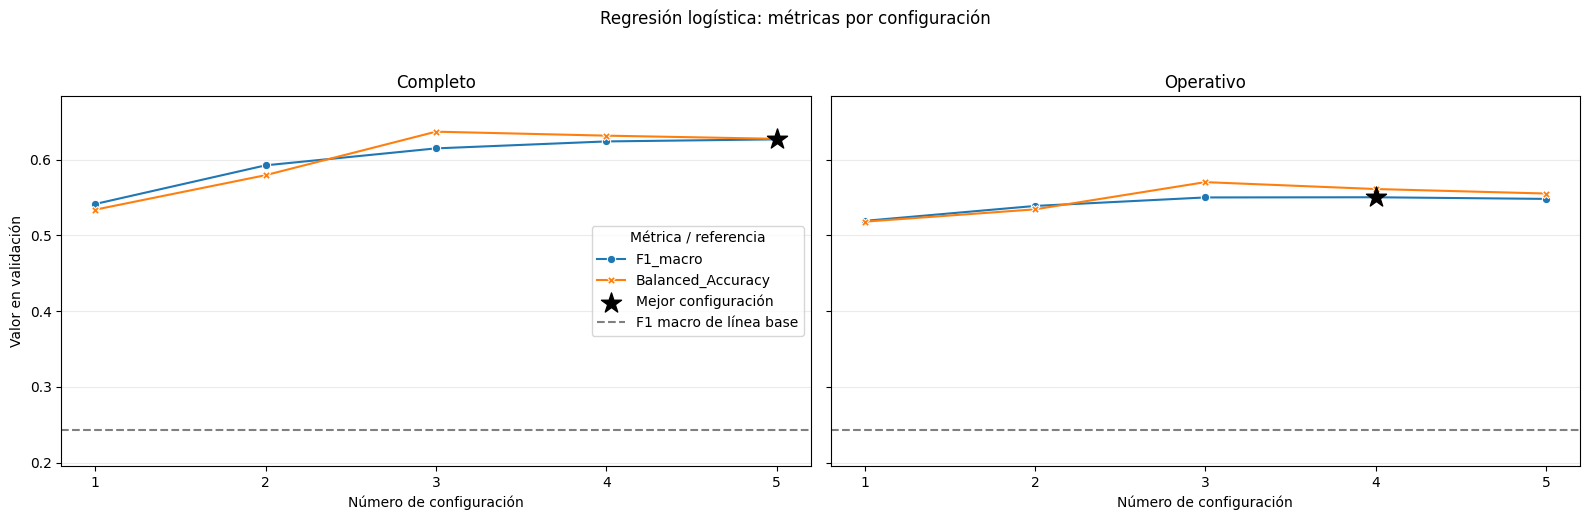

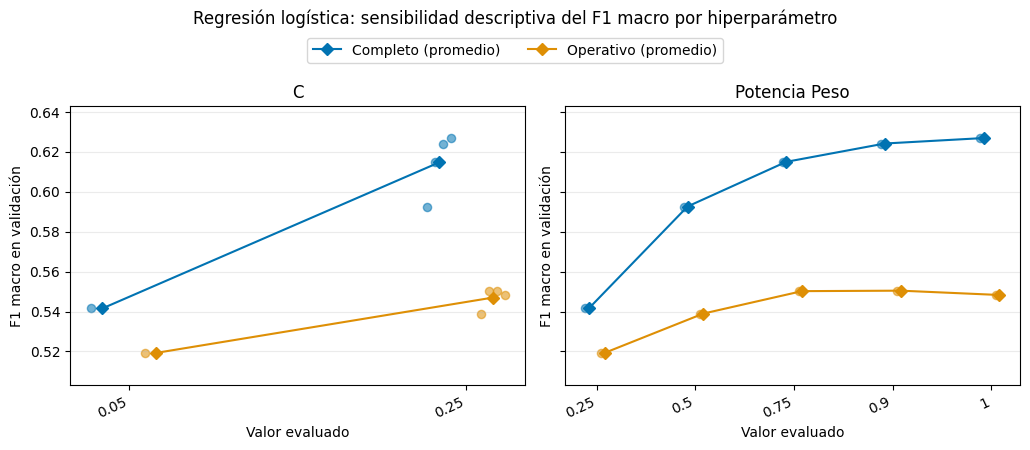

In [ ]:
graficar_configuraciones(resultados_logistica, 'Regresión logística')

#### Resultados de `regresión logística`

La exploración de hiperparámetros muestra que el desempeño de la regresión logística es más sensible a la **ponderación de clases** que al parámetro de regularización `C`. En el escenario completo, el aumento de `potencia_peso` produce una mejora progresiva del `F1_macro`, mientras que en el escenario operativo la mejora se estabiliza y posteriormente presenta una ligera disminución. Esto indica que una ponderación más intensa favorece la identificación de las clases minoritarias, aunque su efecto depende del conjunto de predictores disponible.

En validación, los escenarios completos alcanzan un `F1_macro` cercano a **0,63**, frente a aproximadamente **0,55** en los escenarios operativos. Esta diferencia confirma que las variables adicionales disponibles después de documentar el accidente aportan capacidad predictiva, aunque no son variables que PrediRuta pueda capturar.

El aporte del clima es reducido en los modelos. En el escenario completo, la incorporación de variables climáticas genera un incremento aproximado de **0,27 %** en el `F1_macro`. En contraste, en el escenario operativo se observa una reducción cercana al **0,13 %**. Estos cambios son mínimos, por lo que el clima no muestra un aporte relevante al desempeño de la regresión logística en validación.

Por lo anterior, las variables meteorológicas no generan una mejora relevante en la regresión logística bajo la partición temporal utilizada. Todos los escenarios superan la línea base y muestran una capacidad de predicción considerablemente mayor que la prevalencia histórica de las clases.

### 7.2 Random Forest

Random Forest permite capturar relaciones no lineales e interacciones entre los predictores sin asumir una forma funcional específica. Para esta familia se evalúan diferentes combinaciones de profundidad, número de árboles, tamaño mínimo de hoja y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se mantiene sin modificaciones al evaluar el escenario equivalente sin clima, permitiendo aislar el aporte de las variables meteorológicas sin mezclarlo con cambios en la complejidad o ponderación del modelo.

In [ ]:
# Configuraciones de hiperparámetros para Random Forest con pesos de clase suaves
CONFIG_RF = [
    {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25},
    {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25},
    {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.50},
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75},
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75},
]

In [ ]:
# Ajuste del modelo Random Forest en el escenario completo con clima
nombre_modelo = 'RANDOM_FOREST'
escenario = 'COMPLETO_CON_CLIMA'
filas_rf_completo = []
modelos_rf_completo = {}
probas_rf_completo = {}

for numero, parametros in enumerate(CONFIG_RF, start=1):
    print(f'Configuración {numero}/{len(CONFIG_RF)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo,
        escenario,
        parametros,
        datos_escenario[escenario]['ajuste'],
        y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )
    filas_rf_completo.append({
        'MODELO': nombre_modelo,
        'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_rf_completo[numero] = modelo
    probas_rf_completo[numero] = probabilidades

tabla_rf_completo = pd.DataFrame(filas_rf_completo)
display(tabla_rf_completo.round(4))

Configuración 1/5: {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}
Configuración 2/5: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}
Configuración 3/5: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}
Configuración 4/5: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 5/5: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO,1,"{""n_estimators"": 160, ""max_depth"": 18, ""min_sa...",80.3090,0.8788,0.5873,0.5858,0.8737,0.6416,0.9114,0.3927,0.2164,0.0605
1,RANDOM_FOREST,COMPLETO,2,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",41.5109,0.8781,0.5868,0.5853,0.8730,0.6399,0.9125,0.3941,0.2174,0.0609
2,RANDOM_FOREST,COMPLETO,3,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",48.6773,0.8808,0.5895,0.5878,0.8758,0.6403,0.9102,0.3997,0.2159,0.0645
3,RANDOM_FOREST,COMPLETO,4,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",170.8241,0.8812,0.5910,0.5903,0.8763,0.6417,0.9118,0.3952,0.2117,0.0581
4,RANDOM_FOREST,COMPLETO,5,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",151.6958,0.8811,0.5928,0.5939,0.8764,0.6420,0.9125,0.4064,0.2166,0.0736


In [ ]:
# Identificar la mejor configuración de Random Forest en el escenario completo con clima
mejor_rf_completo = (
    tabla_rf_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_rf_completo['CONFIGURACION'])
parametros_rf_completo = CONFIG_RF[numero_mejor - 1].copy()
modelo_rf_completo_con = modelos_rf_completo[numero_mejor]
proba_rf_completo_con = probas_rf_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_rf_completo)

Mejor configuración COMPLETO: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}


In [157]:
# Ajuste del modelo Random Forest en el escenario completo sin clima
modelo_rf_completo_sin, segundos_rf_completo_sin = ajustar_modelo(
    'RANDOM_FOREST',
    'COMPLETO_SIN_CLIMA',
    parametros_rf_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'],
    y_ajuste
)
proba_rf_completo_sin = ordenar_probabilidades(
    modelo_rf_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_rf_completo = pd.DataFrame([
    {
        'MODELO': 'RANDOM_FOREST', 
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_rf_completo_sin,
        **calcular_metricas(y_val, proba_rf_completo_sin)
    },
    {
        'MODELO': 'RANDOM_FOREST',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_rf_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_rf_completo_con)
    }
])
display(comparacion_rf_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO_SIN_CLIMA,134.2737,0.8807,0.5952,0.5985,0.8763,0.6416,0.9115,0.4105,0.2188,0.0699
1,RANDOM_FOREST,COMPLETO_CON_CLIMA,151.6958,0.8811,0.5928,0.5939,0.8764,0.6420,0.9125,0.4064,0.2166,0.0736


In [158]:
# Ajuste del modelo Random Forest en el escenario operativo con clima
nombre_modelo = 'RANDOM_FOREST'
escenario = 'OPERATIVO_CON_CLIMA'
filas_rf_operativo = []
modelos_rf_operativo = {}
probas_rf_operativo = {}

for numero, parametros in enumerate(CONFIG_RF, start=1):
    print(f'Configuración {numero}/{len(CONFIG_RF)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo,
        escenario,
        parametros,
        datos_escenario[escenario]['ajuste'],
        y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )
    filas_rf_operativo.append({
        'MODELO': nombre_modelo,
        'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_rf_operativo[numero] = modelo
    probas_rf_operativo[numero] = probabilidades

tabla_rf_operativo = pd.DataFrame(filas_rf_operativo)
display(tabla_rf_operativo.round(4))

Configuración 1/5: {'n_estimators': 160, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.25}
Configuración 2/5: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.25}
Configuración 3/5: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.5}
Configuración 4/5: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 5/5: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO,1,"{""n_estimators"": 160, ""max_depth"": 18, ""min_sa...",62.3391,0.8106,0.5351,0.5362,0.8031,0.5886,0.8555,0.5104,0.3052,0.0523
1,RANDOM_FOREST,OPERATIVO,2,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",33.4947,0.8102,0.5348,0.5359,0.8026,0.5889,0.8561,0.5126,0.3066,0.0558
2,RANDOM_FOREST,OPERATIVO,3,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa...",40.0662,0.8136,0.5392,0.5394,0.8071,0.5877,0.8529,0.5195,0.3003,0.0792
3,RANDOM_FOREST,OPERATIVO,4,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",134.0179,0.8132,0.5416,0.5411,0.8078,0.5876,0.8534,0.5208,0.2969,0.0790
4,RANDOM_FOREST,OPERATIVO,5,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",115.7053,0.8117,0.5424,0.5432,0.8067,0.5873,0.8545,0.5327,0.3013,0.0868


In [159]:
# Identificar la mejor configuración de Random Forest en el escenario operativo con clima
mejor_rf_operativo = (
    tabla_rf_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_rf_operativo['CONFIGURACION'])
parametros_rf_operativo = CONFIG_RF[numero_mejor - 1].copy()
modelo_rf_operativo_con = modelos_rf_operativo[numero_mejor]
proba_rf_operativo_con = probas_rf_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_rf_operativo)

Mejor configuración OPERATIVO: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}


In [160]:
# Ajuste del modelo Random Forest en el escenario operativo sin clima
modelo_rf_operativo_sin, segundos_rf_operativo_sin = ajustar_modelo(
    'RANDOM_FOREST',
    'OPERATIVO_SIN_CLIMA',
    parametros_rf_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'],
    y_ajuste
)
proba_rf_operativo_sin = ordenar_probabilidades(
    modelo_rf_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_rf_operativo = pd.DataFrame([
    {
        'MODELO': 'RANDOM_FOREST',
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_rf_operativo_sin,
        **calcular_metricas(y_val, proba_rf_operativo_sin)
    },
    {
        'MODELO': 'RANDOM_FOREST', 
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_rf_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_rf_operativo_con)
    }
])
display(comparacion_rf_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO_SIN_CLIMA,75.0814,0.8121,0.5492,0.5539,0.8079,0.5881,0.8548,0.5453,0.3064,0.0934
1,RANDOM_FOREST,OPERATIVO_CON_CLIMA,115.7053,0.8117,0.5424,0.5432,0.8067,0.5873,0.8545,0.5327,0.3013,0.0868


In [161]:
# Consolidación de resultados de Random Forest para ambos escenarios
resultados_rf = pd.concat([
    tabla_rf_completo,
    tabla_rf_operativo
], ignore_index=True)
comparacion_rf = pd.concat([
    comparacion_rf_completo,
    comparacion_rf_operativo
], ignore_index=True)

mejores_parametros[('RANDOM_FOREST', 'COMPLETO')] = parametros_rf_completo
mejores_parametros[('RANDOM_FOREST', 'OPERATIVO')] = parametros_rf_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_rf_completo_sin, proba_rf_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_rf_completo_con, proba_rf_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_rf_operativo_sin, proba_rf_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_rf_operativo_con, proba_rf_operativo_con),
]:
    modelos_validacion[('RANDOM_FOREST', escenario)] = modelo
    probabilidades_validacion[('RANDOM_FOREST', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_rf)
resultados_validacion.extend(comparacion_rf.to_dict('records'))
display(comparacion_rf.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO_SIN_CLIMA,134.2737,0.8807,0.5952,0.5985,0.8763,0.6416,0.9115,0.4105,0.2188,0.0699
1,RANDOM_FOREST,COMPLETO_CON_CLIMA,151.6958,0.8811,0.5928,0.5939,0.8764,0.6420,0.9125,0.4064,0.2166,0.0736
2,RANDOM_FOREST,OPERATIVO_SIN_CLIMA,75.0814,0.8121,0.5492,0.5539,0.8079,0.5881,0.8548,0.5453,0.3064,0.0934
3,RANDOM_FOREST,OPERATIVO_CON_CLIMA,115.7053,0.8117,0.5424,0.5432,0.8067,0.5873,0.8545,0.5327,0.3013,0.0868


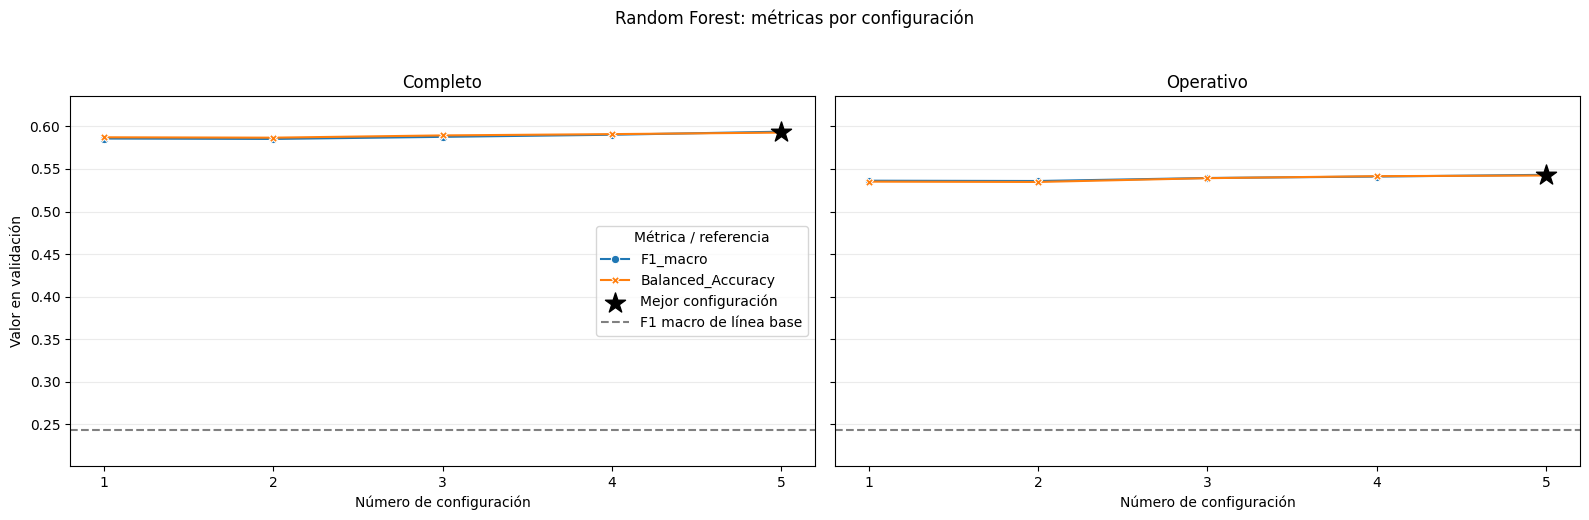

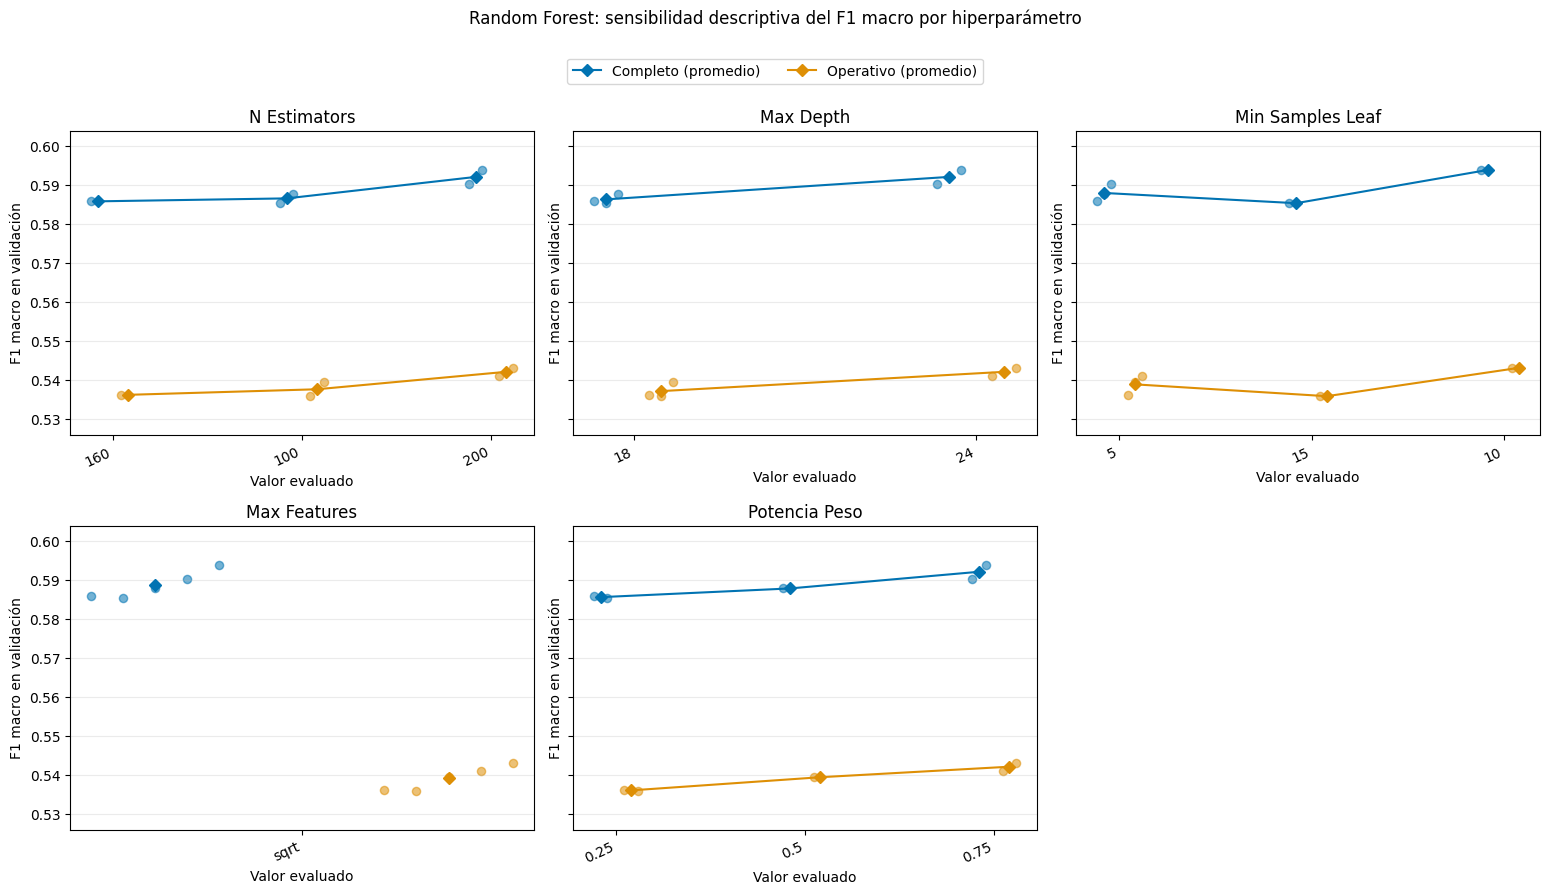

In [162]:
graficar_configuraciones(resultados_rf, 'Random Forest')

#### Resultados de `Random Forest`

Random Forest supera la línea base, pero presenta un desempeño inferior al obtenido previamente por la regresión logística en el escenario completo. La búsqueda de hiperparámetros muestra mejoras graduales al aumentar la profundidad y la ponderación de clases, aunque las últimas configuraciones presentan cambios reducidos, lo que sugiere una estabilización del desempeño.

La incorporación de variables meteorológicas no mejora el `F1_macro`. En el escenario completo, el modelo con clima presenta una reducción relativa aproximada de **0,77 %** frente al modelo sin clima. En el escenario operativo, la reducción es mayor y alcanza aproximadamente **1,93 %**. La `Balanced_Accuracy` también disminuye con la incorporación del clima en ambos casos.

Aunque el clima produce una ligera mejora en métricas probabilísticas como `Log_Loss` y `Brier_multiclase`, esta ganancia no se traduce en una mejor clasificación de las tres clases. Por tanto, bajo el criterio principal de selección definido para el proyecto, las variables meteorológicas no aportan una mejora relevante a Random Forest.

### 7.3 XGBoost

XGBoost permite modelar relaciones no lineales e interacciones complejas mediante un ensamble secuencial de árboles, en el que cada nueva iteración busca corregir los errores de las anteriores. Para esta familia se evalúan diferentes combinaciones de número de árboles, profundidad, tasa de aprendizaje, peso mínimo por nodo y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, de manera que la comparación permita aislar el aporte de las variables meteorológicas sin introducir diferencias adicionales asociadas a la configuración del modelo.

In [ ]:
# Configuraciones de hiperparámetros para XGBoost con pesos de clase suaves
CONFIG_XGB = [
    {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25},
    {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.50},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 1.00},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.06, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.10, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 6, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 5, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 15, 'potencia_peso': 0.90},
]

In [ ]:
# Ajuste del modelo XGBoost en el escenario completo con clima
nombre_modelo = 'XGBOOST'
escenario = 'COMPLETO_CON_CLIMA'
filas_xgb_completo = []
modelos_xgb_completo = {}
probas_xgb_completo = {}

for numero, parametros in enumerate(CONFIG_XGB, start=1):
    print(f'Configuración {numero}/{len(CONFIG_XGB)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_xgb_completo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_xgb_completo[numero] = modelo
    probas_xgb_completo[numero] = probabilidades

tabla_xgb_completo = pd.DataFrame(filas_xgb_completo)
display(tabla_xgb_completo.round(4))

Configuración 1/14: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 2/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 3/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 4/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}
Configuración 5/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}
Configuración 6/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}
Configuración 7/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}
Configuración 8/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, '

,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",6.7391,0.8798,0.5888,0.5882,0.8748,0.6451,0.9147,0.4081,0.2255,0.0850
1,XGBOOST,COMPLETO,2,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.0575,0.8696,0.5821,0.5854,0.8641,0.6510,0.9198,0.4043,0.2254,0.0738
2,XGBOOST,COMPLETO,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.5848,0.8712,0.5854,0.5899,0.8660,0.6500,0.9200,0.3966,0.2186,0.0661
3,XGBOOST,COMPLETO,4,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",12.8829,0.8761,0.5905,0.5945,0.8714,0.6486,0.9194,0.3813,0.2083,0.0478
4,XGBOOST,COMPLETO,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",14.4317,0.8778,0.6074,0.6169,0.8746,0.6479,0.9187,0.3816,0.2081,0.0446
5,XGBOOST,COMPLETO,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",13.9143,0.8715,0.6520,0.6414,0.8724,0.6461,0.9172,0.4073,0.2214,0.0431
6,XGBOOST,COMPLETO,7,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",16.3767,0.8763,0.6354,0.6392,0.8754,0.6467,0.9172,0.3922,0.2123,0.0295
7,XGBOOST,COMPLETO,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",12.7651,0.8771,0.6320,0.6374,0.8759,0.6463,0.9173,0.3879,0.2100,0.0231
8,XGBOOST,COMPLETO,9,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.5426,0.8763,0.6350,0.6398,0.8752,0.6477,0.9182,0.3923,0.2126,0.0304
9,XGBOOST,COMPLETO,10,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",11.1853,0.8749,0.6395,0.6388,0.8746,0.6454,0.9160,0.3936,0.2138,0.0292


In [ ]:
# Identificar la mejor configuración de XGBoost en el escenario completo con clima
mejor_xgb_completo = (
    tabla_xgb_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_xgb_completo['CONFIGURACION'])
parametros_xgb_completo = CONFIG_XGB[numero_mejor - 1].copy()
modelo_xgb_completo_con = modelos_xgb_completo[numero_mejor]
proba_xgb_completo_con = probas_xgb_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_xgb_completo)

Mejor configuración COMPLETO: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}


In [ ]:
# Ajuste del modelo XGBoost en el escenario completo sin clima
modelo_xgb_completo_sin, segundos_xgb_completo_sin = ajustar_modelo(
    'XGBOOST', 'COMPLETO_SIN_CLIMA', parametros_xgb_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_xgb_completo_sin = ordenar_probabilidades(
    modelo_xgb_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_xgb_completo = pd.DataFrame([
    {
        'MODELO': 'XGBOOST',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_xgb_completo_sin,
        **calcular_metricas(y_val, proba_xgb_completo_sin)
    },
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_xgb_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_xgb_completo_con)
    }
])
display(comparacion_xgb_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,12.7150,0.8747,0.6439,0.6424,0.8746,0.6477,0.9183,0.4048,0.2184,0.0412
1,XGBOOST,COMPLETO_CON_CLIMA,10.3321,0.8763,0.6392,0.6420,0.8755,0.6473,0.9176,0.3983,0.2145,0.0338


In [176]:
# Ajuste del modelo XGBoost en el escenario operativo con clima
nombre_modelo = 'XGBOOST'
escenario = 'OPERATIVO_CON_CLIMA'
filas_xgb_operativo = []
modelos_xgb_operativo = {}
probas_xgb_operativo = {}

for numero, parametros in enumerate(CONFIG_XGB, start=1):
    print(f'Configuración {numero}/{len(CONFIG_XGB)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_xgb_operativo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_xgb_operativo[numero] = modelo
    probas_xgb_operativo[numero] = probabilidades

tabla_xgb_operativo = pd.DataFrame(filas_xgb_operativo)
display(tabla_xgb_operativo.round(4))

Configuración 1/14: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 2/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 3/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 4/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}
Configuración 5/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}
Configuración 6/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}
Configuración 7/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}
Configuración 8/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, '

,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",7.6635,0.8158,0.5404,0.5414,0.8091,0.5933,0.8592,0.4985,0.2952,0.0435
1,XGBOOST,OPERATIVO,2,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",16.2819,0.8173,0.5422,0.5435,0.8108,0.5971,0.8638,0.4904,0.2893,0.0414
2,XGBOOST,OPERATIVO,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",12.9628,0.8182,0.5442,0.5463,0.8120,0.5970,0.8642,0.4887,0.2873,0.0441
3,XGBOOST,OPERATIVO,4,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",14.5448,0.8181,0.5431,0.5442,0.8118,0.5966,0.8638,0.4888,0.2871,0.0450
4,XGBOOST,OPERATIVO,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",14.6730,0.8174,0.5558,0.5617,0.8135,0.5950,0.8625,0.4979,0.2859,0.0390
5,XGBOOST,OPERATIVO,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",10.2514,0.8077,0.5829,0.5741,0.8098,0.5923,0.8604,0.5410,0.3038,0.0581
6,XGBOOST,OPERATIVO,7,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",8.8970,0.8072,0.5764,0.5727,0.8083,0.5923,0.8601,0.5356,0.3013,0.0536
7,XGBOOST,OPERATIVO,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",8.8096,0.8048,0.5700,0.5686,0.8055,0.5920,0.8598,0.5345,0.3013,0.0490
8,XGBOOST,OPERATIVO,9,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.0469,0.8076,0.5764,0.5727,0.8086,0.5923,0.8608,0.5383,0.3022,0.0580
9,XGBOOST,OPERATIVO,10,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",8.6486,0.8070,0.5748,0.5712,0.8081,0.5911,0.8590,0.5325,0.3001,0.0497


In [177]:
# Identificar la mejor configuración de XGBoost en el escenario operativo con clima
mejor_xgb_operativo = (
    tabla_xgb_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_xgb_operativo['CONFIGURACION'])
parametros_xgb_operativo = CONFIG_XGB[numero_mejor - 1].copy()
modelo_xgb_operativo_con = modelos_xgb_operativo[numero_mejor]
proba_xgb_operativo_con = probas_xgb_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_xgb_operativo)

Mejor configuración OPERATIVO: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}


In [178]:
# Ajuste del modelo XGBoost en el escenario operativo sin clima
modelo_xgb_operativo_sin, segundos_xgb_operativo_sin = ajustar_modelo(
    'XGBOOST', 'OPERATIVO_SIN_CLIMA', parametros_xgb_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_xgb_operativo_sin = ordenar_probabilidades(
    modelo_xgb_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_xgb_operativo = pd.DataFrame([
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_xgb_operativo_sin,
        **calcular_metricas(y_val, proba_xgb_operativo_sin)
    },
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_xgb_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_xgb_operativo_con)
    }
])
display(comparacion_xgb_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO_SIN_CLIMA,6.9841,0.8066,0.5789,0.5730,0.8082,0.5922,0.8611,0.5432,0.3043,0.0606
1,XGBOOST,OPERATIVO_CON_CLIMA,8.5237,0.8070,0.5798,0.5744,0.8085,0.5924,0.8606,0.5416,0.3037,0.0602


In [179]:
# Consolidación de resultados de XGBoost para ambos escenarios
resultados_xgb = pd.concat([
    tabla_xgb_completo,
    tabla_xgb_operativo
], ignore_index=True)
comparacion_xgb = pd.concat([
    comparacion_xgb_completo,
    comparacion_xgb_operativo
], ignore_index=True)

mejores_parametros[('XGBOOST', 'COMPLETO')] = parametros_xgb_completo
mejores_parametros[('XGBOOST', 'OPERATIVO')] = parametros_xgb_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_xgb_completo_sin, proba_xgb_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_xgb_completo_con, proba_xgb_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_xgb_operativo_sin, proba_xgb_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_xgb_operativo_con, proba_xgb_operativo_con),
]:
    modelos_validacion[('XGBOOST', escenario)] = modelo
    probabilidades_validacion[('XGBOOST', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_xgb)
resultados_validacion.extend(comparacion_xgb.to_dict('records'))
display(comparacion_xgb.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,12.7150,0.8747,0.6439,0.6424,0.8746,0.6477,0.9183,0.4048,0.2184,0.0412
1,XGBOOST,COMPLETO_CON_CLIMA,10.3321,0.8763,0.6392,0.6420,0.8755,0.6473,0.9176,0.3983,0.2145,0.0338
2,XGBOOST,OPERATIVO_SIN_CLIMA,6.9841,0.8066,0.5789,0.5730,0.8082,0.5922,0.8611,0.5432,0.3043,0.0606
3,XGBOOST,OPERATIVO_CON_CLIMA,8.5237,0.8070,0.5798,0.5744,0.8085,0.5924,0.8606,0.5416,0.3037,0.0602


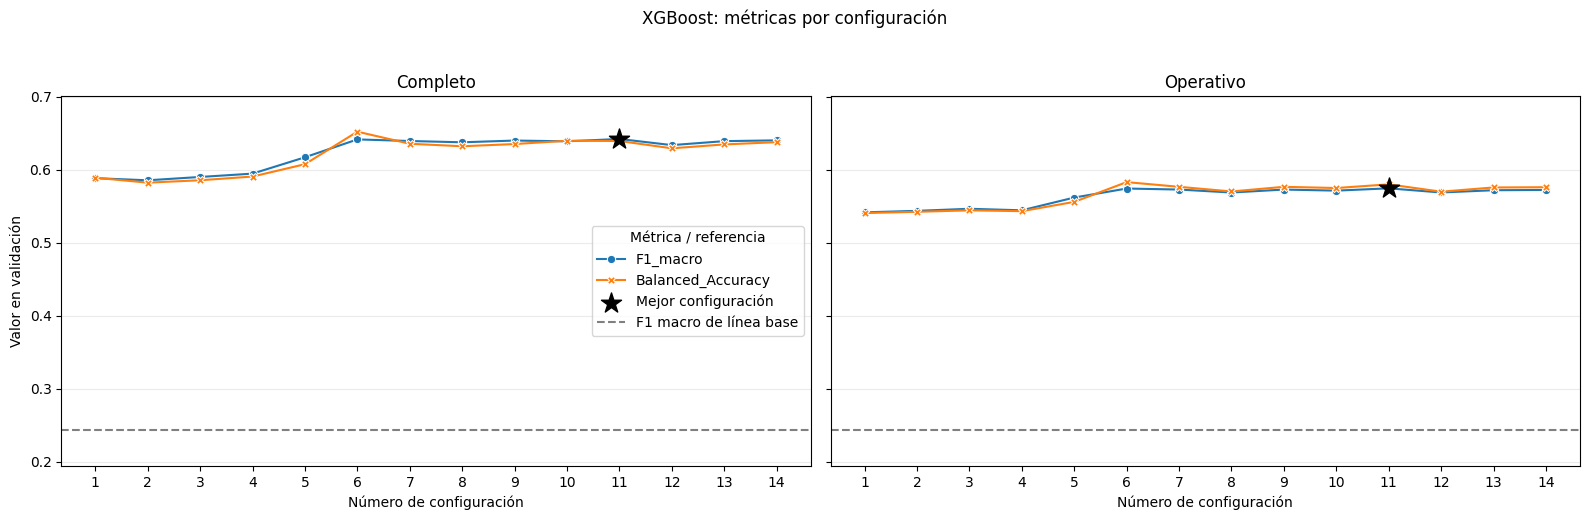

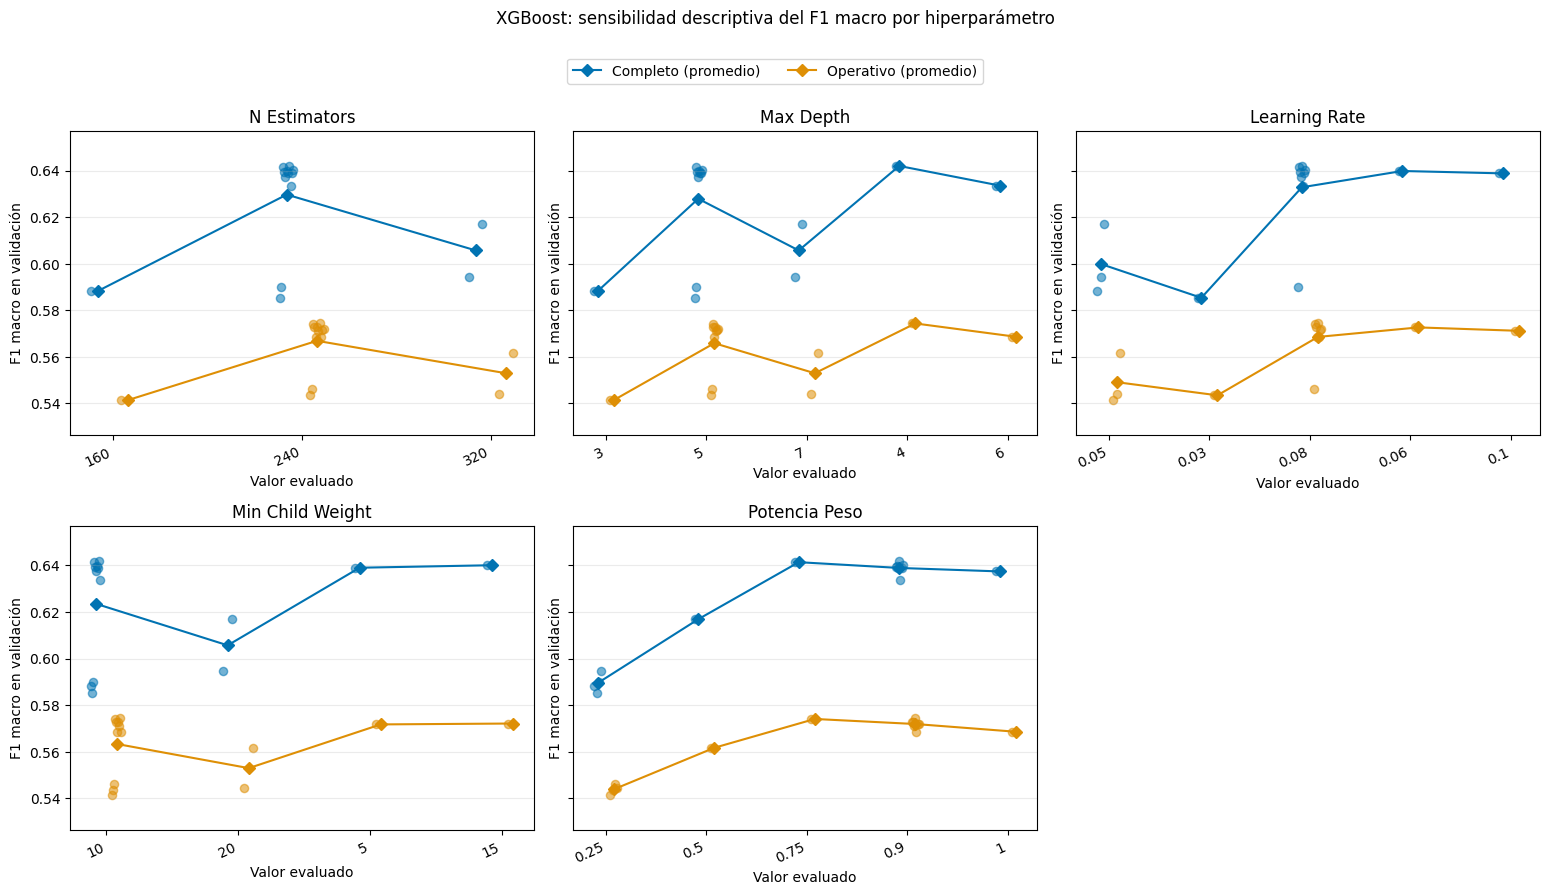

In [180]:
graficar_configuraciones(resultados_xgb, 'XGBoost')

#### Resultados de `XGBoost`

XGBoost presenta el mejor desempeño obtenido hasta este punto entre los modelos evaluados. En el escenario completo alcanza un `F1_macro` cercano a **0,64**, mientras que en el escenario operativo se ubica alrededor de **0,57**, superando tanto la línea base como los resultados obtenidos con Random Forest.

La búsqueda de hiperparámetros muestra que la principal mejora se obtiene al incrementar la ponderación de clases hasta valores cercanos a `0,75–0,90`. A partir de este rango, el desempeño tiende a estabilizarse, por lo que no se observa una ganancia clara al continuar aumentando la ponderación. Los mejores resultados también se concentran alrededor de `n_estimators = 240`, profundidades intermedias y tasas de aprendizaje entre `0,06` y `0,08`.

El aporte del clima es nuevamente reducido. En el escenario completo, la incorporación de variables meteorológicas produce una disminución relativa aproximada de **0,06 %** en el `F1_macro`, al pasar de `0,6424` a `0,6420`. En contraste, en el escenario operativo se observa un incremento aproximado de **0,26 %**, de `0,5758` a `0,5743`. Aunque el escenario con clima mejora ligeramente algunas métricas probabilísticas como `Log_Loss`, `Brier_multiclase` y `ECE`, el efecto sobre la capacidad de clasificación es mínimo.

En conjunto, XGBoost muestra una mayor capacidad predictiva que Random Forest y mantiene un desempeño competitivo frente a la regresión logística, especialmente en el escenario operativo, que constituye la referencia principal para el uso posterior en PrediRuta.

### 7.4 Red neuronal MLP

MLP permite modelar relaciones no lineales mediante una red neuronal multicapa capaz de aprender combinaciones complejas entre los predictores. Para esta familia se evalúan distintas arquitecturas, niveles de regularización y tasas de aprendizaje mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. balancear la muestra de entrenamiento utilizada por la red neuronal;
3. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
4. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
5. repetir el mismo procedimiento para los escenarios operativos;
6. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

A diferencia de los modelos anteriores, MLP no utiliza directamente `class_weight`, por lo que el tratamiento del desbalance se realiza mediante una muestra de entrenamiento balanceada. El ajuste de hiperparámetros se efectúa únicamente en los escenarios con clima y la configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, permitiendo aislar el aporte de las variables meteorológicas.

In [ ]:
# Configuraciones de hiperparámetros para MLP sobre la muestra de entrenamiento balanceada
CONFIG_MLP = [
    {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007},
]

In [182]:
# Ajuste del modelo MLP en el escenario completo con clima
nombre_modelo = 'MLP'
escenario = 'COMPLETO_CON_CLIMA'
filas_mlp_completo = []
modelos_mlp_completo = {}
probas_mlp_completo = {}

for numero, parametros in enumerate(CONFIG_MLP, start=1):
    print(f'Configuración {numero}/{len(CONFIG_MLP)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_mlp_completo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_mlp_completo[numero] = modelo
    probas_mlp_completo[numero] = probabilidades

tabla_mlp_completo = pd.DataFrame(filas_mlp_completo)
display(tabla_mlp_completo.round(4))

Configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",17.9485,0.8166,0.6394,0.5840,0.8286,0.6157,0.8808,0.4755,0.2737,0.0378
1,MLP,COMPLETO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",133.5578,0.8428,0.6217,0.5957,0.8522,0.6105,0.8641,0.5570,0.2615,0.0658
2,MLP,COMPLETO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",97.1151,0.8299,0.6111,0.5846,0.8388,0.6114,0.8681,0.5880,0.2725,0.0674


In [183]:
# Identificar la mejor configuración de MLP en el escenario completo con clima
mejor_mlp_completo = (
    tabla_mlp_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_mlp_completo['CONFIGURACION'])
parametros_mlp_completo = CONFIG_MLP[numero_mejor - 1].copy()
modelo_mlp_completo_con = modelos_mlp_completo[numero_mejor]
proba_mlp_completo_con = probas_mlp_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_mlp_completo)

Mejor configuración COMPLETO: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}


In [184]:
# Ajuste del modelo MLP en el escenario completo sin clima
modelo_mlp_completo_sin, segundos_mlp_completo_sin = ajustar_modelo(
    'MLP', 'COMPLETO_SIN_CLIMA', parametros_mlp_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_mlp_completo_sin = ordenar_probabilidades(
    modelo_mlp_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_mlp_completo = pd.DataFrame([
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_mlp_completo_sin,
        **calcular_metricas(y_val, proba_mlp_completo_sin)
    },
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_mlp_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_mlp_completo_con)
    }
])
display(comparacion_mlp_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO_SIN_CLIMA,29.1288,0.8315,0.6127,0.5870,0.8385,0.6133,0.8629,0.5324,0.2652,0.0611
1,MLP,COMPLETO_CON_CLIMA,133.5578,0.8428,0.6217,0.5957,0.8522,0.6105,0.8641,0.5570,0.2615,0.0658


In [185]:
# Ajuste del modelo MLP en el escenario operativo con clima
nombre_modelo = 'MLP'
escenario = 'OPERATIVO_CON_CLIMA'
filas_mlp_operativo = []
modelos_mlp_operativo = {}
probas_mlp_operativo = {}

for numero, parametros in enumerate(CONFIG_MLP, start=1):
    print(f'Configuración {numero}/{len(CONFIG_MLP)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_mlp_operativo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_mlp_operativo[numero] = modelo
    probas_mlp_operativo[numero] = probabilidades

tabla_mlp_operativo = pd.DataFrame(filas_mlp_operativo)
display(tabla_mlp_operativo.round(4))

Configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",5.7222,0.7620,0.6431,0.5498,0.7910,0.5794,0.8524,0.6204,0.3557,0.0504
1,MLP,OPERATIVO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",32.2131,0.8129,0.5981,0.5730,0.8226,0.5830,0.8398,0.6218,0.3059,0.0663
2,MLP,OPERATIVO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",36.3163,0.8184,0.5912,0.5747,0.8253,0.5852,0.8388,0.5790,0.2948,0.0549


In [186]:
# Identificar la mejor configuración de MLP en el escenario operativo con clima
mejor_mlp_operativo = (
    tabla_mlp_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_mlp_operativo['CONFIGURACION'])
parametros_mlp_operativo = CONFIG_MLP[numero_mejor - 1].copy()
modelo_mlp_operativo_con = modelos_mlp_operativo[numero_mejor]
proba_mlp_operativo_con = probas_mlp_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_mlp_operativo)

Mejor configuración OPERATIVO: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


In [190]:
# Ajuste del modelo MLP en el escenario operativo sin clima
modelo_mlp_operativo_sin, segundos_mlp_operativo_sin = ajustar_modelo(
    'MLP', 'OPERATIVO_SIN_CLIMA', parametros_mlp_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_mlp_operativo_sin = ordenar_probabilidades(
    modelo_mlp_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_mlp_operativo = pd.DataFrame([
    {
        'MODELO': 'MLP', 
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_mlp_operativo_sin,
        **calcular_metricas(y_val, proba_mlp_operativo_sin)
    },
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_mlp_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_mlp_operativo_con)
    }
])
display(comparacion_mlp_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO_SIN_CLIMA,111.3763,0.8115,0.5998,0.5736,0.8214,0.5855,0.8389,0.6102,0.3068,0.0693
1,MLP,OPERATIVO_CON_CLIMA,36.3163,0.8184,0.5912,0.5747,0.8253,0.5852,0.8388,0.5790,0.2948,0.0549


In [191]:
# Consolidación de resultados de MLP para ambos escenarios
resultados_mlp = pd.concat([
    tabla_mlp_completo,
    tabla_mlp_operativo
], ignore_index=True)
comparacion_mlp = pd.concat([
    comparacion_mlp_completo,
    comparacion_mlp_operativo
], ignore_index=True)

mejores_parametros[('MLP', 'COMPLETO')] = parametros_mlp_completo
mejores_parametros[('MLP', 'OPERATIVO')] = parametros_mlp_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_mlp_completo_sin, proba_mlp_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_mlp_completo_con, proba_mlp_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_mlp_operativo_sin, proba_mlp_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_mlp_operativo_con, proba_mlp_operativo_con),
]:
    modelos_validacion[('MLP', escenario)] = modelo
    probabilidades_validacion[('MLP', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_mlp)
resultados_validacion.extend(comparacion_mlp.to_dict('records'))
display(comparacion_mlp.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO_SIN_CLIMA,29.1288,0.8315,0.6127,0.5870,0.8385,0.6133,0.8629,0.5324,0.2652,0.0611
1,MLP,COMPLETO_CON_CLIMA,133.5578,0.8428,0.6217,0.5957,0.8522,0.6105,0.8641,0.5570,0.2615,0.0658
2,MLP,OPERATIVO_SIN_CLIMA,111.3763,0.8115,0.5998,0.5736,0.8214,0.5855,0.8389,0.6102,0.3068,0.0693
3,MLP,OPERATIVO_CON_CLIMA,36.3163,0.8184,0.5912,0.5747,0.8253,0.5852,0.8388,0.5790,0.2948,0.0549


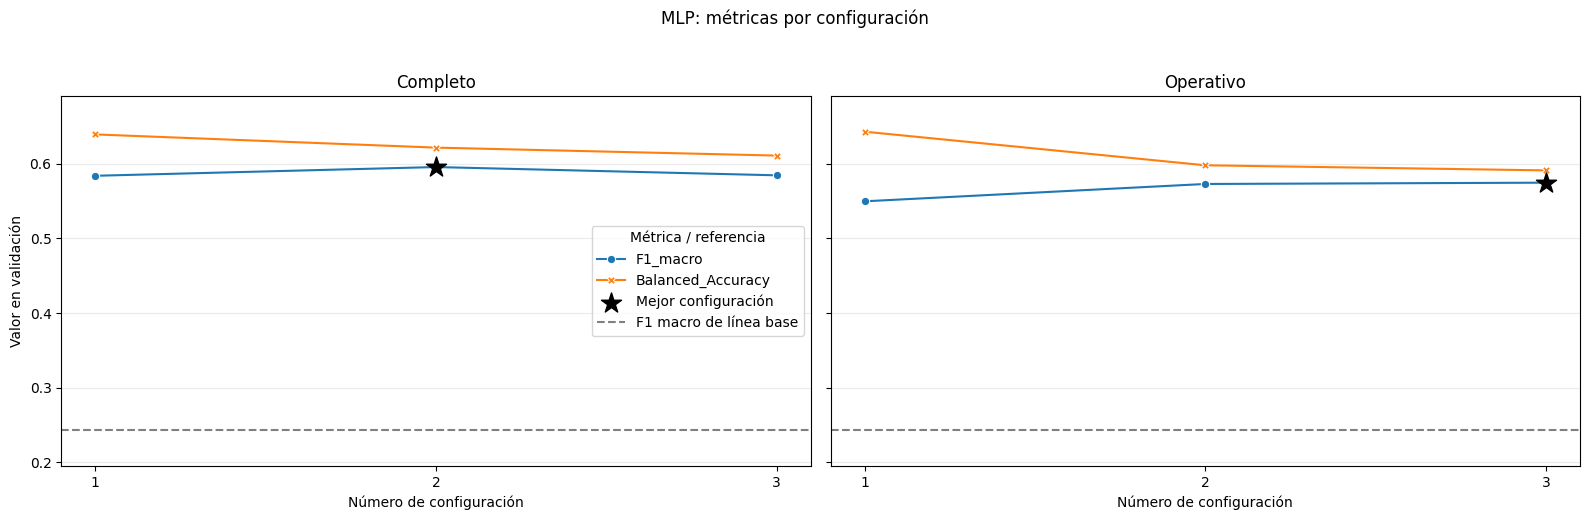

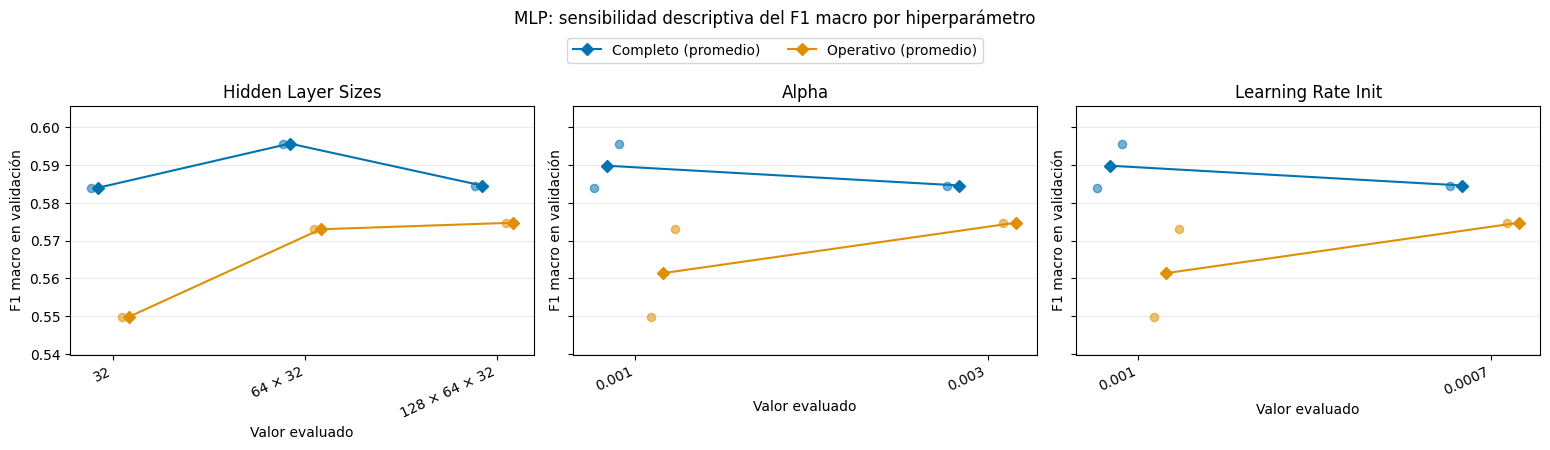

In [189]:
graficar_configuraciones(resultados_mlp, 'MLP')

#### Resultados de MLP

MLP supera ampliamente la línea base y presenta un comportamiento competitivo en el escenario operativo. El aumento de complejidad desde una sola capa oculta hasta arquitecturas de dos o tres capas mejora el `F1_macro`, aunque las diferencias entre las configuraciones más complejas son reducidas.

La incorporación del clima produce un incremento relativo aproximado de **1,48 %** en el `F1_macro` del escenario completo, al pasar de `0,5870` a `0,5957`. En el escenario operativo, el incremento es de apenas **0,19 %**, de `0,5736` a `0,5747`. En este último caso, aunque el `F1_macro` mejora ligeramente, la `Balanced_Accuracy` disminuye, por lo que el aporte meteorológico no es consistente entre las métricas principales.

En comparación con los modelos anteriores, MLP mantiene un desempeño competitivo en el escenario operativo, pero no presenta una ventaja clara frente a XGBoost. 

## 8. Comparación final de modelos, variables disponibles y clima

In [199]:
# Consolidar una sola evaluación por modelo y escenario
resultados_ajuste = pd.concat(resultados_ajuste_acumulados, ignore_index=True).drop_duplicates()
resultados_validacion = pd.DataFrame(resultados_validacion).copy()

# Reconstruir estas etiquetas desde ESCENARIO para evitar valores faltantes
# cuando las celdas de los modelos se ejecutan en momentos diferentes.
escenarios_texto = resultados_validacion['ESCENARIO'].astype(str)
resultados_validacion['ALCANCE'] = np.select(
    [
        escenarios_texto.str.startswith('COMPLETO_'),
        escenarios_texto.str.startswith('OPERATIVO_')
    ],
    ['COMPLETO', 'OPERATIVO'],
    default='BASELINE'
)
resultados_validacion['CLIMA'] = np.select(
    [
        escenarios_texto.str.endswith('_CON_CLIMA'),
        escenarios_texto.str.endswith('_SIN_CLIMA')
    ],
    ['CON_CLIMA', 'SIN_CLIMA'],
    default='SIN_PREDICTORES'
)

# Si una celda se ejecutó más de una vez, conservar la mejor evaluación
# de cada combinación modelo-escenario y evitar promedios artificiales.
resultados_validacion = (
    resultados_validacion
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .drop_duplicates(subset=['MODELO', 'ESCENARIO'], keep='first')
    .reset_index(drop=True)
)

display(resultados_validacion.drop(columns=['ALCANCE', 'CLIMA']))


,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,12.715009,0.874741,0.643864,0.642366,0.874563,0.647742,0.918308,0.404759,0.218384,0.041228
1,XGBOOST,COMPLETO_CON_CLIMA,10.332098,0.876253,0.639217,0.641973,0.875503,0.647250,0.917615,0.398260,0.214540,0.033783
2,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,21.594439,0.866028,0.627588,0.626883,0.865301,0.638125,0.909339,0.423374,0.227032,0.060163
3,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,16.482184,0.862627,0.625419,0.625174,0.861517,0.638686,0.909751,0.427882,0.229746,0.059924
4,RANDOM_FOREST,COMPLETO_SIN_CLIMA,134.273656,0.880680,0.595151,0.598479,0.876260,0.641630,0.911484,0.410503,0.218764,0.069913
5,MLP,COMPLETO_CON_CLIMA,133.557822,0.842751,0.621732,0.595695,0.852214,0.610490,0.864103,0.556984,0.261465,0.065751
6,RANDOM_FOREST,COMPLETO_CON_CLIMA,151.695808,0.881125,0.592815,0.593880,0.876442,0.642041,0.912465,0.406392,0.216637,0.073601
7,MLP,COMPLETO_SIN_CLIMA,29.128808,0.831461,0.612669,0.586981,0.838529,0.613330,0.862859,0.532412,0.265160,0.061126
8,XGBOOST,OPERATIVO_SIN_CLIMA,9.465885,0.807232,0.587425,0.575820,0.809800,0.592154,0.861435,0.546328,0.306543,0.061774
9,MLP,OPERATIVO_CON_CLIMA,36.316324,0.818354,0.591200,0.574736,0.825250,0.585210,0.838753,0.579005,0.294772,0.054901


In [200]:
candidatos = resultados_validacion.query("ALCANCE in ['COMPLETO', 'OPERATIVO']").copy()
mejor_por_escenario = (
    candidatos.sort_values(['F1_macro', 'Balanced_Accuracy', 'Log_Loss'], ascending=[False, False, True])
    .groupby('ESCENARIO', as_index=False).first()
)
display(mejor_por_escenario.drop(columns=['ALCANCE', 'CLIMA']))

,ESCENARIO,MODELO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,COMPLETO_CON_CLIMA,XGBOOST,10.332098,0.876253,0.639217,0.641973,0.875503,0.647250,0.917615,0.398260,0.214540,0.033783
1,COMPLETO_SIN_CLIMA,XGBOOST,12.715009,0.874741,0.643864,0.642366,0.874563,0.647742,0.918308,0.404759,0.218384,0.041228
2,OPERATIVO_CON_CLIMA,MLP,36.316324,0.818354,0.591200,0.574736,0.825250,0.585210,0.838753,0.579005,0.294772,0.054901
3,OPERATIVO_SIN_CLIMA,XGBOOST,9.465885,0.807232,0.587425,0.575820,0.809800,0.592154,0.861435,0.546328,0.306543,0.061774


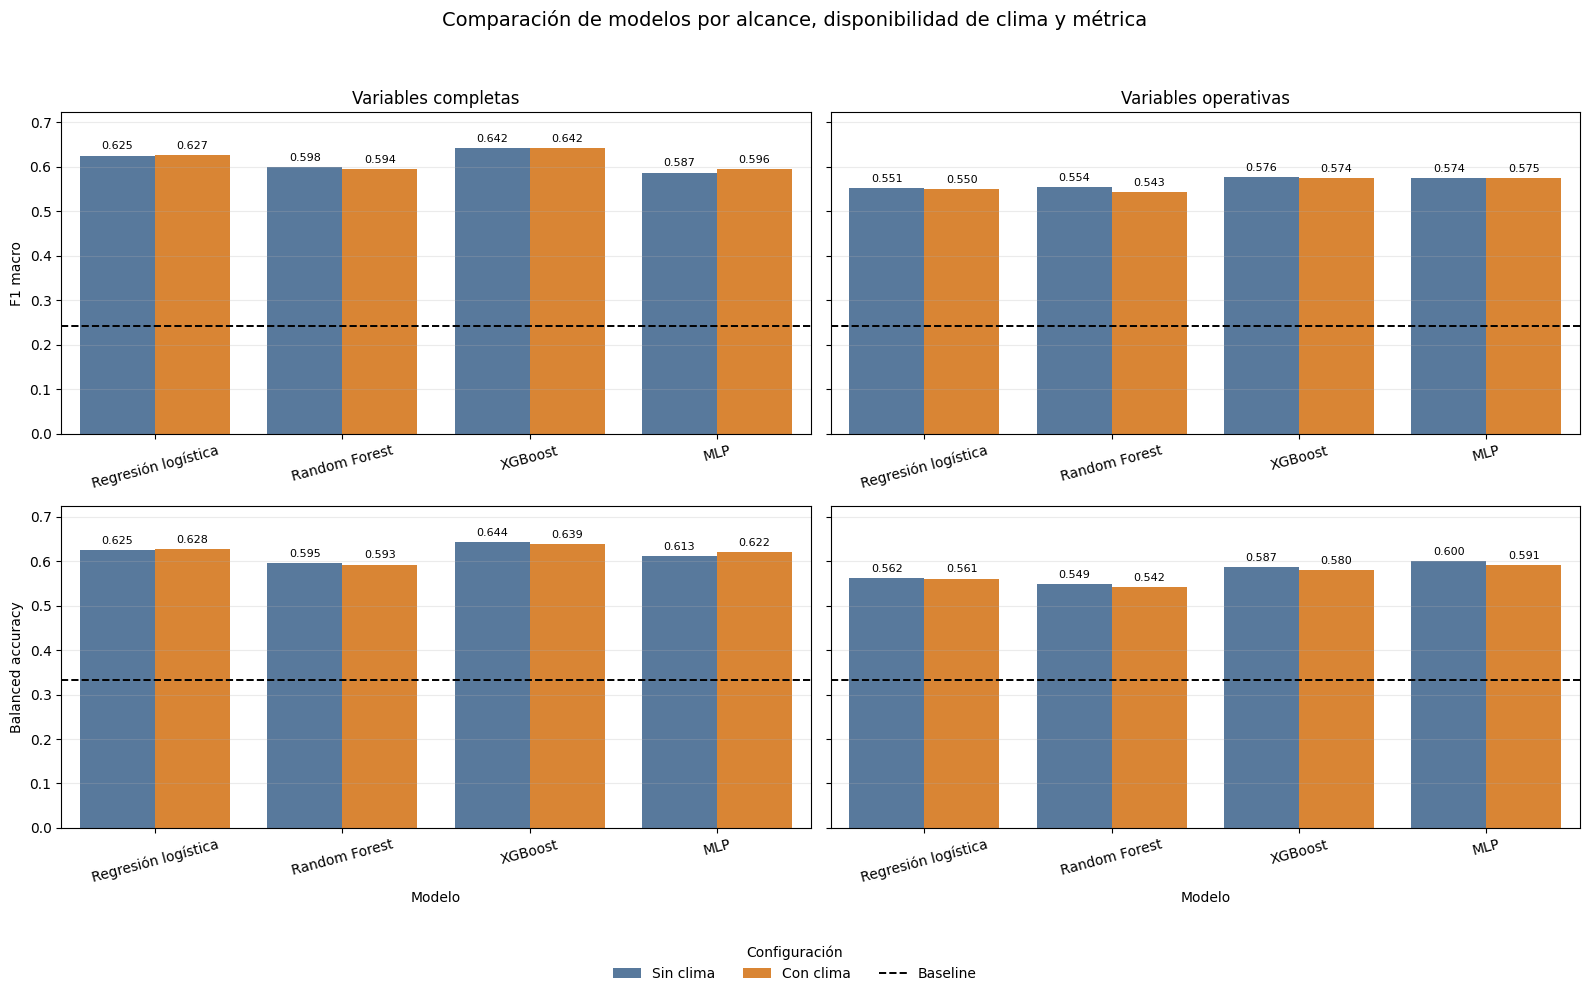

In [202]:
# Comparación visual separada por alcance, clima y métrica
comparacion_grafica = candidatos.copy()
comparacion_grafica['MODELO_GRAFICA'] = comparacion_grafica['MODELO'].replace({
    'REGRESION_LOGISTICA': 'Regresión logística',
    'RANDOM_FOREST': 'Random Forest',
    'XGBOOST': 'XGBoost',
    'MLP': 'MLP'
})
comparacion_grafica['CLIMA_GRAFICA'] = comparacion_grafica['CLIMA'].replace({
    'SIN_CLIMA': 'Sin clima',
    'CON_CLIMA': 'Con clima'
})

orden_modelos = [
    modelo for modelo in ['Regresión logística', 'Random Forest', 'XGBoost', 'MLP']
    if modelo in comparacion_grafica['MODELO_GRAFICA'].unique()
]
orden_clima = ['Sin clima', 'Con clima']
paleta_clima = {'Sin clima': '#4C78A8', 'Con clima': '#F58518'}

alcances_grafica = [
    ('COMPLETO', 'Variables completas'),
    ('OPERATIVO', 'Variables operativas')
]
metricas_grafica = [
    ('F1_macro', 'F1 macro'),
    ('Balanced_Accuracy', 'Balanced accuracy')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

for fila, (metrica, etiqueta_metrica) in enumerate(metricas_grafica):
    limite_superior = min(1.0, comparacion_grafica[metrica].max() + 0.08)

    for columna, (alcance, titulo_alcance) in enumerate(alcances_grafica):
        ax = axes[fila, columna]
        datos_panel = comparacion_grafica.query('ALCANCE == @alcance')

        sns.barplot(
            data=datos_panel,
            x='MODELO_GRAFICA',
            y=metrica,
            hue='CLIMA_GRAFICA',
            order=orden_modelos,
            hue_order=orden_clima,
            palette=paleta_clima,
            errorbar=None,
            ax=ax
        )
        ax.axhline(
            metricas_baseline[metrica],
            color='black',
            linestyle='--',
            linewidth=1.4,
            label='Baseline'
        )
        if fila == 0:
            ax.set_title(titulo_alcance)
        ax.set_xlabel('Modelo' if fila == 1 else '')
        ax.set_ylabel(etiqueta_metrica if columna == 0 else '')
        ax.set_ylim(0, limite_superior)
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.25)

        for contenedor in ax.containers:
            ax.bar_label(contenedor, fmt='%.3f', padding=3, fontsize=8)

handles, etiquetas = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    leyenda = ax.get_legend()
    if leyenda is not None:
        leyenda.remove()

fig.legend(
    handles,
    etiquetas,
    title='Configuración',
    loc='lower center',
    ncol=3,
    frameon=False
)
fig.suptitle(
    'Comparación de modelos por alcance, disponibilidad de clima y métrica',
    fontsize=14
)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()


#### Comparación global de los modelos

Todos los modelos evaluados superan ampliamente la línea base, confirmando que los predictores disponibles contienen información útil para distinguir entre `HERIDO`, `ILESO` y `MUERTO`. El mejor desempeño global se obtiene con XGBoost en los escenarios completos, alcanzando un `F1_macro` cercano a **0,64**. Sin embargo, estos escenarios incluyen información que no estaría disponible durante una consulta real y se utilizan únicamente como referencia experimental.

En los escenarios operativos las diferencias entre los modelos se reducen. XGBoost sin clima obtiene el mayor `F1_macro` (**0,5758**), mientras que MLP con clima alcanza un resultado muy cercano (**0,5747**) y una `Balanced_Accuracy` ligeramente superior. De acuerdo con el criterio de selección establecido, que prioriza `F1_macro`, XGBoost sin clima constituye la mejor alternativa operativa en validación. Además, presenta un menor costo de entrenamiento y no depende de la disponibilidad de información meteorológica.

La incorporación del clima no produce una mejora consistente entre las familias de modelos. En el escenario operativo, el `F1_macro` disminuye en XGBoost, Random Forest y regresión logística, mientras que MLP presenta únicamente una mejora marginal. Por esta razón, no se observa evidencia suficiente en validación para afirmar que las variables meteorológicas aporten una mejora relevante y estable a la clasificación del estado.

La reducción de desempeño entre los escenarios completos y operativos evidencia que las variables disponibles después de documentar el accidente contienen información predictiva importante. No obstante, esta diferencia refuerza la necesidad de seleccionar el modelo final a partir del escenario operativo, ya que es el único que representa las condiciones reales de uso previstas para PrediRuta.

In [203]:
# Elegir un ganador completo y uno operativo sin consultar prueba
ganadores_alcance = (
    candidatos
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .groupby('ALCANCE', as_index=False)
    .first()
)

display(ganadores_alcance.drop(columns=['ALCANCE', 'CLIMA']))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,12.715009,0.874741,0.643864,0.642366,0.874563,0.647742,0.918308,0.404759,0.218384,0.041228
1,XGBOOST,OPERATIVO_SIN_CLIMA,9.465885,0.807232,0.587425,0.575820,0.809800,0.592154,0.861435,0.546328,0.306543,0.061774


In [204]:
# Guardar la configuración ganadora de cada alcance
GANADORES = {}

for _, fila in ganadores_alcance.iterrows():

    alcance = fila['ALCANCE']

    GANADORES[alcance] = {
        'modelo': fila['MODELO'],
        'escenario': fila['ESCENARIO'],
        'parametros': mejores_parametros[
            (fila['MODELO'], alcance)
        ]
    }

In [205]:
# Mostrar ganadores seleccionados

for alcance, ganador in GANADORES.items():

    print(f'\n{alcance}')
    print(f"Modelo: {ganador['modelo']}")
    print(f"Escenario: {ganador['escenario']}")
    print(f"Parámetros: {ganador['parametros']}")


COMPLETO
Modelo: XGBOOST
Escenario: COMPLETO_SIN_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}

OPERATIVO
Modelo: XGBOOST
Escenario: OPERATIVO_SIN_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}


In [206]:
# El escenario operativo dirige los diagnósticos y el backtesting

NOMBRE_GANADOR = GANADORES['OPERATIVO']['modelo']
ESCENARIO_GANADOR = GANADORES['OPERATIVO']['escenario']
PARAMETROS_GANADOR = GANADORES['OPERATIVO']['parametros']

print(f'Modelo operativo ganador: {NOMBRE_GANADOR}')
print(f'Escenario: {ESCENARIO_GANADOR}')
print(f'Parámetros: {PARAMETROS_GANADOR}')

Modelo operativo ganador: XGBOOST
Escenario: OPERATIVO_SIN_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}


## 9. Incertidumbre en las diferencias entre escenarios

Con el fin de determinar si las diferencias observadas entre escenarios son consistentes o pueden atribuirse a variación muestral, se aplica un bootstrap pareado y estratificado sobre el conjunto de validación.

El análisis se utiliza para evaluar dos comparaciones principales: la diferencia entre los escenarios completo y operativo, y el efecto de incorporar variables meteorológicas dentro del escenario operativo. En cada réplica, ambos modelos se evalúan sobre las mismas observaciones remuestreadas y se estiman las diferencias en `F1_macro`, `Balanced_Accuracy` y `Log_Loss`, junto con intervalos de confianza del 95 %.

Los deltas se definen de manera que valores positivos representan una mejora de la alternativa evaluada. Cuando el intervalo de confianza incluye cero, la diferencia se considera insuficiente para afirmar una mejora consistente en validación.

In [ ]:
# Funciones ligeras para el bootstrap estratificado
def indices_bootstrap_estratificado(y, rng): # Función auxiliar para generar índices de bootstrap estratificado
    return np.concatenate([
        rng.choice(indices_clase, size=len(indices_clase), replace=True)
        for indices_clase in (
            np.flatnonzero(y == clase) for clase in np.unique(y)
        )
    ])

def calcular_metricas_bootstrap(y_real, probabilidades): # Función auxiliar para calcular métricas de evaluación a partir de etiquetas reales y probabilidades predichas
    # El punto 9 solo necesita estas tres métricas. Evitar aquí ROC-AUC,
    # PR-AUC, Brier y calibración reduce considerablemente el tiempo.
    numero_clases = len(clases_codificadas)
    indices_reales = np.searchsorted(clases_codificadas, y_real)
    indices_predichos = np.argmax(probabilidades, axis=1)

    matriz = np.bincount(
        indices_reales * numero_clases + indices_predichos,
        minlength=numero_clases ** 2
    ).reshape(numero_clases, numero_clases)

    verdaderos_positivos = np.diag(matriz).astype(float)
    reales_por_clase = matriz.sum(axis=1)
    predichos_por_clase = matriz.sum(axis=0)

    recall = np.divide(
        verdaderos_positivos,
        reales_por_clase,
        out=np.zeros(numero_clases, dtype=float),
        where=reales_por_clase > 0
    )
    precision = np.divide(
        verdaderos_positivos,
        predichos_por_clase,
        out=np.zeros(numero_clases, dtype=float),
        where=predichos_por_clase > 0
    )
    f1_por_clase = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros(numero_clases, dtype=float),
        where=(precision + recall) > 0
    )

    probabilidad_clase_real = probabilidades[
        np.arange(len(y_real)), indices_reales
    ]

    return {
        'F1_macro': f1_por_clase.mean(),
        'Balanced_Accuracy': recall.mean(),
        'Log_Loss': -np.log(
            np.clip(probabilidad_clase_real, 1e-15, 1.0)
        ).mean()
    }

# Función principal para calcular intervalos de confianza del delta entre dos modelos
def bootstrap_delta(y, proba_base, proba_alternativa, repeticiones=250, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    indices_por_clase = [
        np.flatnonzero(y == clase) for clase in np.unique(y)
    ]
    registros = []

    for _ in range(repeticiones):
        indices = np.concatenate([
            rng.choice(indices_clase, size=len(indices_clase), replace=True)
            for indices_clase in indices_por_clase
        ])
        m_base = calcular_metricas_bootstrap(
            y[indices], proba_base[indices]
        )
        m_alt = calcular_metricas_bootstrap(
            y[indices], proba_alternativa[indices]
        )
        registros.append({
            'F1_macro': m_alt['F1_macro'] - m_base['F1_macro'],
            'Balanced_Accuracy': (
                m_alt['Balanced_Accuracy'] - m_base['Balanced_Accuracy']
            ),
            'Log_Loss': m_base['Log_Loss'] - m_alt['Log_Loss'],
        })

    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'DELTA_PROMEDIO': muestras.mean(),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975)
    })


In [211]:
# Comparación de escenarios completo y operativo para el modelo ganador
g_completo = GANADORES['COMPLETO']
g_operativo = GANADORES['OPERATIVO']
proba_completo_val = probabilidades_validacion[(g_completo['modelo'], g_completo['escenario'])]
proba_operativo_val = probabilidades_validacion[(g_operativo['modelo'], g_operativo['escenario'])]

# Positivo significa que agregar las variables no disponibles mejora
impacto_variables = bootstrap_delta(y_val, proba_operativo_val, proba_completo_val)
display(impacto_variables)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.069561,0.065411,0.074039
Balanced_Accuracy,0.065142,0.060414,0.070419
Log_Loss,0.138480,0.136082,0.140916


In [212]:
# Comparación climática dentro del mismo modelo y alcance operativo
escenario_op_con = 'OPERATIVO_CON_CLIMA'
escenario_op_sin = 'OPERATIVO_SIN_CLIMA'
proba_op_con = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_con)]
proba_op_sin = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_sin)]
impacto_clima_operativo = bootstrap_delta(y_val, proba_op_sin, proba_op_con)
display(impacto_clima_operativo)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.001425,-0.000730,0.003906
Balanced_Accuracy,0.001000,-0.001955,0.003974
Log_Loss,0.001637,0.001373,0.001901


#### Resultados del bootstrap pareado

La comparación entre los escenarios completo y operativo muestra una diferencia marcada y consistente en validación. El escenario completo presenta una mejora promedio de **0,0696** en `F1_macro` y de **0,0651** en `Balanced_Accuracy`; en ambos casos, los intervalos de confianza del 95 % permanecen completamente por encima de cero. También se observa una mejora de **0,1385** en `Log_Loss`. Esto confirma que el conjunto completo alcanza un desempeño sustancialmente mayor que el escenario operativo, aunque esta diferencia debe interpretarse considerando que el escenario completo incorpora información que no estaría disponible durante una consulta real.

El efecto del clima dentro del escenario operativo es considerablemente menor. El incremento promedio es de apenas **0,0014** en `F1_macro` y **0,0010** en `Balanced_Accuracy`, y sus intervalos de confianza incluyen cero. Por tanto, no existe evidencia suficiente para afirmar que las variables meteorológicas produzcan una mejora consistente en la clasificación. Aunque `Log_Loss` presenta una reducción pequeña y estable, su magnitud es limitada. En conjunto, los resultados indican que el clima puede aportar una mejora marginal en la calidad probabilística, pero no modifica de manera relevante la capacidad de clasificación del modelo operativo.

## 10. Backtesting temporal del modelo operativo seleccionado

Como diagnóstico adicional de estabilidad temporal, se evalúa el modelo operativo seleccionado en dos ventanas históricas anteriores al periodo utilizado para la selección final. En cada ventana se reajustan los parámetros del modelo utilizando únicamente observaciones disponibles hasta ese momento, manteniendo fija la configuración de hiperparámetros seleccionada previamente:

- entrenamiento hasta 2016 y evaluación en 2017–2018;
- entrenamiento hasta 2018 y evaluación en 2019–2020.

Se conserva la misma familia de modelo, escenario e hiperparámetros seleccionados previamente, de manera que el objetivo no es realizar una nueva búsqueda, sino comprobar si el diseño mantiene un desempeño similar al desplazarse en el tiempo. Este análisis funciona como una verificación retrospectiva de estabilidad y no sustituye la evaluación final sobre el conjunto de prueba 2024–2026.

In [29]:
VENTANAS_BACKTEST = [
    {'ENTRENA_HASTA': 2016, 'VALIDA_DESDE': 2017, 'VALIDA_HASTA': 2018},
    {'ENTRENA_HASTA': 2018, 'VALIDA_DESDE': 2019, 'VALIDA_HASTA': 2020},
]

resultados_backtest = []
for ventana in VENTANAS_BACKTEST:
    mascara_bt_train = datos_modelo['ANIO'] <= ventana['ENTRENA_HASTA']
    mascara_bt_val = datos_modelo['ANIO'].between(ventana['VALIDA_DESDE'], ventana['VALIDA_HASTA'])
    X_bt_train, y_bt_train = construir_xy(mascara_bt_train, ESCENARIO_GANADOR)
    X_bt_val, y_bt_val = construir_xy(mascara_bt_val, ESCENARIO_GANADOR)
    indices_bt = indices_muestra_ajuste(y_bt_train)
    modelo_bt, segundos = ajustar_modelo(
        NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
        X_bt_train.iloc[indices_bt].reset_index(drop=True), y_bt_train[indices_bt]
    )
    proba_bt = ordenar_probabilidades(modelo_bt, X_bt_val, clases_codificadas)
    resultados_backtest.append({
        **ventana, 'FILAS_ENTRENAMIENTO': len(indices_bt),
        'FILAS_VALIDACION': len(y_bt_val), 'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_bt_val, proba_bt),
    })

resultados_backtest = pd.DataFrame(resultados_backtest)
display(resultados_backtest)

,ENTRENA_HASTA,VALIDA_DESDE,VALIDA_HASTA,FILAS_ENTRENAMIENTO,FILAS_VALIDACION,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2016,2017,2018,300000,278088,15.335715,0.848253,0.612296,0.563929,0.863974,0.571334,0.855943,0.501523,0.252940,0.040134
1,2018,2019,2020,300000,231349,18.768975,0.849072,0.609128,0.569354,0.863623,0.579736,0.865865,0.506724,0.252103,0.041952


#### Resultados del backtesting

El modelo obtiene un `F1_macro` de **0,5639** en 2017–2018 y de **0,5694** en 2019–2020, una diferencia de aproximadamente **0,0055 puntos**. La cercanía entre ambos resultados sugiere un comportamiento históricamente estable del diseño operativo en estas ventanas. De forma similar, la `Balanced_Accuracy` permanece cercana entre ambos periodos, lo que indica que el desempeño entre clases no presenta cambios abruptos.

Estos resultados son favorables como diagnóstico de estabilidad temporal, aunque deben interpretarse como evidencia complementaria. La capacidad de generalización hacia datos más recientes se determinará finalmente con el conjunto de prueba 2024–2026, que permanece sin utilizar durante la selección y el backtesting.

## 11. Reajuste final y evaluación sobre prueba no utilizada

Una vez cerrada la selección de modelos e hiperparámetros con el conjunto de validación, los diseños ganadores de los alcances completo y operativo se reajustan utilizando conjuntamente la información disponible entre 2007 y 2023. Para mantener un costo computacional razonable, se utiliza una muestra común, aleatoria y reproducible de hasta **600.000 actores**, conservando la distribución de las clases.

La misma muestra de desarrollo se utiliza para ambos alcances, de modo que la comparación final no dependa de diferencias en las observaciones empleadas durante el reajuste. La línea base también se reconstruye con esta información para mantener una referencia comparable.

El periodo **2024–2026** permanece completamente excluido de la selección de modelos, el ajuste de hiperparámetros, el bootstrap y el backtesting. Se utiliza únicamente en esta etapa para estimar el desempeño final sobre datos futuros no observados durante el desarrollo.

In [213]:
# Preparar el modelo final para producción y backtesting
mascara_desarrollo = datos_modelo['ANIO'] <= ANIO_FIN_VALIDACION
resultados_test = []
modelos_finales = {}
probabilidades_finales = {}

# Construir una muestra final común para evitar reajustes prohibitivos
_, y_desarrollo_referencia = construir_xy(mascara_desarrollo, 'COMPLETO_CON_CLIMA')
indices_desarrollo = indices_muestra_ajuste(
    y_desarrollo_referencia, tamano=600_000, semilla=SEMILLA + 100
)
print(f'Muestra de reajuste final: {len(indices_desarrollo):,} de {len(y_desarrollo_referencia):,} actores')

Muestra de reajuste final: 600,000 de 1,844,909 actores


In [214]:
# Ajuste del baseline para la muestra de desarrollo
baseline_final = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline_final.fit(np.zeros((len(indices_desarrollo), 1)), y_desarrollo_referencia[indices_desarrollo])
proba_baseline_test = ordenar_probabilidades(baseline_final, np.zeros((mascara_test.sum(), 1)), clases_codificadas)
metricas_baseline_test = calcular_metricas(y_test, proba_baseline_test)
resultados_test.append({'ALCANCE': 'BASELINE', 'MODELO': 'BASELINE_PRIOR', 'ESCENARIO': 'SIN_PREDICTORES', **metricas_baseline_test})

for alcance in ['COMPLETO', 'OPERATIVO']:
    ganador = GANADORES[alcance]
    X_desarrollo_alcance, y_desarrollo = construir_xy(mascara_desarrollo, ganador['escenario'])
    X_test_alcance, _ = construir_xy(mascara_test, ganador['escenario'])
    X_reajuste = X_desarrollo_alcance.iloc[indices_desarrollo].reset_index(drop=True)
    y_reajuste = y_desarrollo[indices_desarrollo]
    print(f'Reajustando {alcance}: {ganador["modelo"]} / {ganador["escenario"]} con {len(y_reajuste):,} registros...')
    modelo, segundos = ajustar_modelo(
        ganador['modelo'], ganador['escenario'], ganador['parametros'],
        X_reajuste, y_reajuste
    )
    proba = ordenar_probabilidades(modelo, X_test_alcance, clases_codificadas)
    modelos_finales[alcance] = modelo
    probabilidades_finales[alcance] = proba
    resultados_test.append({
        'ALCANCE': alcance, 'MODELO': ganador['modelo'], 'ESCENARIO': ganador['escenario'],
        'SEGUNDOS_AJUSTE': segundos, **calcular_metricas(y_test, proba)
    })

comparacion_test = pd.DataFrame(resultados_test)
display(comparacion_test)

Reajustando COMPLETO: XGBOOST / COMPLETO_SIN_CLIMA con 600,000 registros...
Reajustando OPERATIVO: XGBOOST / OPERATIVO_SIN_CLIMA con 600,000 registros...


,ALCANCE,MODELO,ESCENARIO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,SEGUNDOS_AJUSTE
0,BASELINE,BASELINE_PRIOR,SIN_PREDICTORES,0.310211,0.333333,0.157843,0.146894,0.333333,0.500000,1.166149,0.853171,0.452441,NaN
1,COMPLETO,XGBOOST,COMPLETO_SIN_CLIMA,0.837722,0.648116,0.633863,0.840223,0.633235,0.887885,0.491388,0.274311,0.051364,18.325066
2,OPERATIVO,XGBOOST,OPERATIVO_SIN_CLIMA,0.774742,0.592551,0.568784,0.782105,0.574700,0.836658,0.609073,0.347379,0.063663,13.730222


In [215]:
# Variables de referencia para el diagnóstico del modelo operativo
modelo_final = modelos_finales['OPERATIVO']
probabilidades_test = probabilidades_finales['OPERATIVO']
prediccion_test = clases_codificadas[np.argmax(probabilidades_test, axis=1)]
metricas_test = calcular_metricas(y_test, probabilidades_test)
X_desarrollo_completo, y_desarrollo = construir_xy(mascara_desarrollo, ESCENARIO_GANADOR)
X_desarrollo = X_desarrollo_completo.iloc[indices_desarrollo].reset_index(drop=True)
X_test, _ = construir_xy(mascara_test, ESCENARIO_GANADOR)

In [216]:
# Intervalos de confianza del 95 % mediante bootstrap estratificado
def bootstrap_metricas(y, probabilidades, repeticiones=300, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        registros.append(calcular_metricas(y[indices], probabilidades[indices]))
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'ESTIMACION_TEST': pd.Series(metricas_test),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975),
    })

intervalos_test = bootstrap_metricas(y_test, probabilidades_test)
display(intervalos_test)

,ESTIMACION_TEST,IC95_INFERIOR,IC95_SUPERIOR
Accuracy,0.774742,0.771665,0.778051
Balanced_Accuracy,0.592551,0.583959,0.599976
F1_macro,0.568784,0.562271,0.574798
F1_weighted,0.782105,0.779211,0.785188
PR_AUC_macro,0.574700,0.570927,0.579061
ROC_AUC_OVR_macro,0.836658,0.832281,0.840760
Log_Loss,0.609073,0.604363,0.614361
Brier_multiclase,0.347379,0.343935,0.350932
ECE_10_bins,0.063663,0.061387,0.066896


#### Resultados en el conjunto de prueba

La evaluación final confirma que XGBoost mantiene capacidad de generalización sobre el periodo 2024–2026. El modelo operativo alcanza un `F1_macro` de **0,5688** y una `Balanced_Accuracy` de **0,5926**, valores cercanos a los obtenidos previamente en validación. La reducción frente al `F1_macro` de validación es pequeña, lo que indica que el desempeño no se deteriora de forma abrupta al avanzar hacia un periodo temporal no utilizado durante el desarrollo.

El escenario completo obtiene un desempeño superior, con `F1_macro = 0,6339` y `Balanced_Accuracy = 0,6481`. La diferencia de aproximadamente **0,065 puntos de F1 macro** frente al escenario operativo confirma que las variables disponibles al documentar el accidente contienen información predictiva adicional. Sin embargo, estas variables no pueden utilizarse en una consulta real de PrediRuta, por lo que el modelo operativo continúa siendo la alternativa relevante para el producto.

El modelo operativo también supera ampliamente la línea base, cuyo `F1_macro` es **0,1578** y cuya `Balanced_Accuracy` permanece en **0,3333**, correspondiente al nivel esperado de un clasificador sin capacidad para diferenciar adecuadamente las tres clases. La baja `Accuracy` de la línea base en prueba también refleja el cambio temporal en la distribución de `ESTADO` observado previamente.

Los intervalos de confianza del 95 % muestran que el desempeño del modelo operativo es estable dentro del conjunto de prueba. El `F1_macro` se encuentra entre **0,5623 y 0,5748**, mientras que la `Balanced_Accuracy` se ubica entre **0,5840 y 0,6000**. En las métricas probabilísticas, el modelo alcanza `ROC_AUC_OVR_macro = 0,8367`, `PR_AUC_macro = 0,5747` y un `ECE` cercano a **0,064**, lo que muestra una capacidad discriminante relevante y una calibración razonable, aunque todavía mejorable.

En conjunto, los resultados respaldan la selección de **XGBoost sin variables climáticas como modelo operativo final**. El desempeño se mantiene estable entre el backtesting, la validación y la prueba temporal, y la exclusión del clima simplifica el escenario de implementación sin sacrificar de manera relevante la capacidad predictiva.

## 12. Diagnóstico por clase y análisis de errores

La evaluación global se complementa con métricas específicas por clase y una matriz de confusión normalizada. Este análisis permite identificar en qué categorías el modelo operativo presenta mayor capacidad de reconocimiento y dónde se concentran sus principales errores, aspecto especialmente relevante debido al fuerte desbalance de `ESTADO`.

In [218]:
# Diagnóstico de la predicción final sobre la muestra de prueba
nombres_estados = [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_]
reporte_clases = pd.DataFrame(classification_report(
    y_test, prediccion_test, labels=clases_codificadas,
    target_names=nombres_estados, output_dict=True, zero_division=0
)).T
display(reporte_clases)

,precision,recall,f1-score,support
HERIDO,0.881914,0.786207,0.831315,50764.000000
ILESO,0.656532,0.786386,0.715616,23505.000000
MUERTO,0.130398,0.205060,0.159420,1502.000000
accuracy,0.774742,0.774742,0.774742,0.774742
macro avg,0.556281,0.592551,0.568784,75771.000000
weighted avg,0.797101,0.774742,0.782105,75771.000000


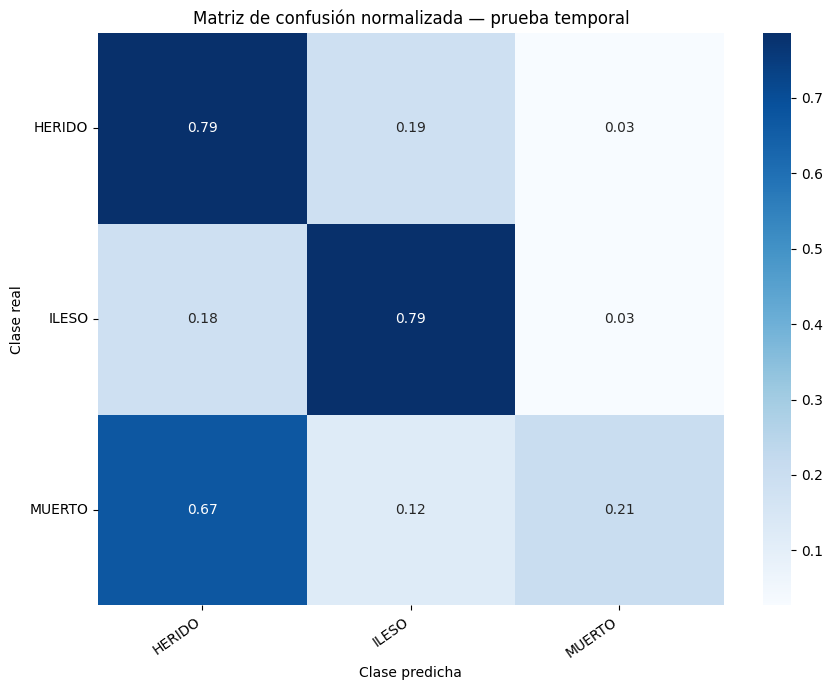

In [219]:
# Visualización de la matriz de confusión normalizada
matriz = confusion_matrix(y_test, prediccion_test, labels=clases_codificadas, normalize='true')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nombres_estados, yticklabels=nombres_estados, ax=ax)
ax.set_title('Matriz de confusión normalizada — prueba temporal')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase real')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Resultados por clase

El modelo presenta su mejor desempeño para `HERIDO`, con **precision = 0,882**, **recall = 0,786** y **F1 = 0,831**. Para `ILESO`, el recall se mantiene en un nivel similar (**0,786**), aunque la menor precisión reduce su F1 a **0,716**. En contraste, `MUERTO` continúa siendo la clase más difícil de identificar: alcanza un **recall de 0,205**, una **precisión de 0,130** y un **F1 de 0,159**.

La matriz de confusión confirma este comportamiento. Cerca del **79 %** de los casos `HERIDO` e `ILESO` son clasificados correctamente. Para `MUERTO`, únicamente alrededor del **21 %** se identifica correctamente, mientras que aproximadamente el **67 %** se clasifica como `HERIDO` y el **12 %** como `ILESO`. Esto indica que, aunque el modelo logra reconocer algunos eventos de la clase minoritaria y evita un recall igual a cero, su capacidad para distinguir los fallecimientos continúa siendo limitada.

Por tanto, las métricas globales deben interpretarse junto con este diagnóstico por clase. El modelo operativo presenta un desempeño estable para las categorías más frecuentes, pero la identificación de `MUERTO` permanece como su principal limitación y constituye un punto prioritario para futuras mejoras.

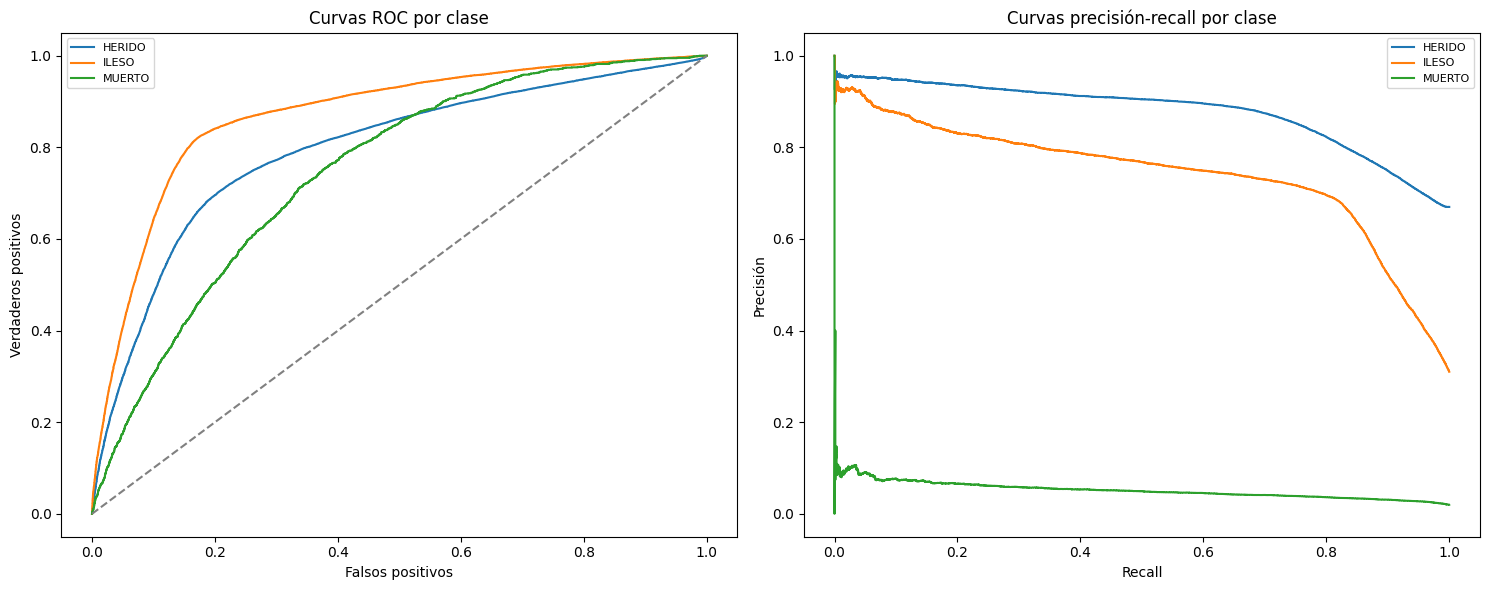

In [33]:
# Curvas ROC y precisión-recall uno contra el resto
y_test_bin = LabelBinarizer().fit(clases_codificadas).transform(y_test)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for posicion, nombre_clase in enumerate(nombres_estados):
    fpr, tpr, _ = roc_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    precision, recall, _ = precision_recall_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    axes[0].plot(fpr, tpr, label=nombre_clase)
    axes[1].plot(recall, precision, label=nombre_clase)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='Curvas ROC por clase', xlabel='Falsos positivos', ylabel='Verdaderos positivos')
axes[1].set(title='Curvas precisión-recall por clase', xlabel='Recall', ylabel='Precisión')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Curvas ROC y precisión-recall por clase

Las curvas ROC muestran que el modelo presenta capacidad de discriminación para las tres clases, con un comportamiento especialmente favorable para `ILESO` y `HERIDO`. Sin embargo, la interpretación cambia al observar las curvas precisión-recall, que son más informativas ante el fuerte desbalance de `ESTADO`. Mientras `HERIDO` e `ILESO` mantienen niveles relativamente altos de precisión a lo largo de buena parte del rango de recall, la clase `MUERTO` presenta una caída pronunciada de la precisión incluso para niveles bajos de recall.

Este resultado confirma que el principal reto del modelo no es únicamente separar los casos `MUERTO` del resto, sino hacerlo sin generar una cantidad elevada de falsos positivos. Por esta razón, un desempeño ROC aparentemente aceptable para esta clase no se traduce en una capacidad equivalente en términos de precisión-recall. El comportamiento es consistente con la matriz de confusión y las métricas por clase, donde `MUERTO` presenta el menor F1.

En conjunto, las curvas respaldan la utilidad del modelo para `HERIDO` e `ILESO`, pero muestran que la identificación de `MUERTO` continúa siendo limitada. Una mejora futura podría explorar umbrales de decisión específicos por clase o estrategias adicionales para el tratamiento de la clase minoritaria, sin modificar la evaluación final ya realizada sobre el conjunto de prueba.

In [220]:
# Estabilidad por año dentro del periodo de prueba
anios_test = datos_modelo.loc[mascara_test, 'ANIO'].reset_index(drop=True)
metricas_por_anio = []
for anio in sorted(anios_test.unique()):
    mascara_anio = anios_test.eq(anio).to_numpy()
    metricas_anio = calcular_metricas(y_test[mascara_anio], probabilidades_test[mascara_anio])
    metricas_por_anio.append({'ANIO': int(anio), 'FILAS': int(mascara_anio.sum()), **metricas_anio})
metricas_por_anio = pd.DataFrame(metricas_por_anio)
display(metricas_por_anio)

,ANIO,FILAS,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2024,32698,0.771148,0.582249,0.557342,0.779310,0.568556,0.837778,0.612197,0.350823,0.062635
1,2025,29030,0.776852,0.602234,0.575934,0.784316,0.578889,0.837406,0.606995,0.345469,0.065750
2,2026,14043,0.778751,0.594686,0.578066,0.784284,0.581032,0.833709,0.606097,0.343308,0.066064


### Estabilidad anual dentro del periodo de prueba

El desempeño del modelo operativo se mantiene relativamente estable entre los años del conjunto de prueba. El `F1_macro` aumenta de **0,5573** en 2024 a **0,5759** en 2025 y **0,5781** en 2026, mientras que la `Balanced_Accuracy` se mantiene entre **0,5822** y **0,6022**. La `Accuracy` también presenta poca variación, con valores cercanos al **77 %–78 %** durante todo el periodo.

Las métricas probabilísticas muestran un comportamiento igualmente estable: el `ROC_AUC_OVR_macro` permanece alrededor de **0,83–0,84** y el `Log_Loss` disminuye ligeramente de **0,6122** en 2024 a **0,6061** en 2026. El `ECE` presenta un incremento moderado, aunque permanece cercano a **0,06** en los tres años.

En conjunto, no se observa un deterioro progresivo del desempeño durante el periodo de prueba. Por el contrario, las métricas principales se mantienen estables e incluso presentan una ligera mejora después de 2024. Los resultados de 2026 deben interpretarse con cautela, ya que corresponden a un periodo parcial y contienen un número menor de observaciones que 2024 y 2025.

In [221]:
# Confiabilidad de la probabilidad máxima
confianza = probabilidades_test.max(axis=1)
acierto = (prediccion_test == y_test).astype(int)
bins = pd.cut(confianza, bins=np.linspace(0, 1, 11), include_lowest=True)
tabla_calibracion = (
    pd.DataFrame({'BIN': bins, 'CONFIANZA': confianza, 'ACIERTO': acierto})
    .groupby('BIN', observed=False)
    .agg(CASOS=('ACIERTO', 'size'), CONFIANZA_MEDIA=('CONFIANZA', 'mean'), EXACTITUD=('ACIERTO', 'mean'))
    .reset_index()
)
display(tabla_calibracion)

,BIN,CASOS,CONFIANZA_MEDIA,EXACTITUD
0,"(-0.001, 0.1]",0,NaN,NaN
1,"(0.1, 0.2]",0,NaN,NaN
2,"(0.2, 0.3]",0,NaN,NaN
3,"(0.3, 0.4]",1424,0.374783,0.382022
4,"(0.4, 0.5]",4197,0.455257,0.452228
5,"(0.5, 0.6]",7080,0.553353,0.595339
6,"(0.6, 0.7]",18397,0.661994,0.787302
7,"(0.7, 0.8]",18018,0.739270,0.810856
8,"(0.8, 0.9]",17436,0.850116,0.862583
9,"(0.9, 1.0]",9219,0.933183,0.858228


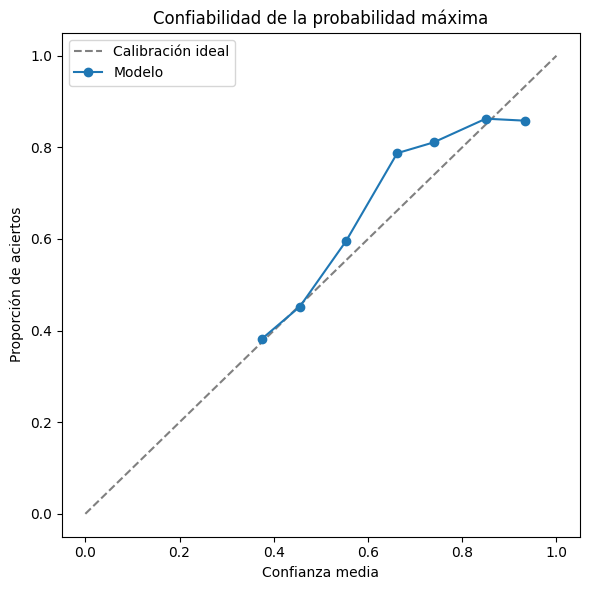

In [222]:
# Visualización de la confiabilidad de la probabilidad máxima
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración ideal')
ax.plot(tabla_calibracion['CONFIANZA_MEDIA'], tabla_calibracion['EXACTITUD'], marker='o', label='Modelo')
ax.set(title='Confiabilidad de la probabilidad máxima', xlabel='Confianza media', ylabel='Proporción de aciertos')
ax.legend()
plt.tight_layout()
plt.show()

#### Confiabilidad de las probabilidades predichas

La curva de confiabilidad muestra que las probabilidades del modelo presentan una calibración razonable, aunque no perfecta. En los intervalos de confianza baja y media, la confianza promedio se aproxima a la proporción real de aciertos. Entre aproximadamente **0,50 y 0,80**, el modelo tiende a ser conservador: la exactitud observada es superior a la confianza que asigna a sus predicciones. Por ejemplo, para una confianza media cercana a **0,66**, la proporción de aciertos alcanza aproximadamente **0,79**.

En el intervalo de mayor confianza ocurre el comportamiento contrario. Para predicciones con una probabilidad máxima promedio cercana a **0,93**, la exactitud observada disminuye a aproximadamente **0,86**, indicando cierta sobreconfianza en las predicciones más seguras. Este comportamiento es consistente con un `ECE` cercano a **0,064**, por lo que las probabilidades pueden considerarse informativas, aunque todavía existe margen para mejorar su calibración si posteriormente se requiere interpretar los valores como probabilidades de riesgo.

## 13. Experimento de sensibilidad: partición aleatoria por accidente

La evaluación temporal se mantiene como estimación principal porque simula la predicción sobre periodos futuros. Como contraste, se construye una partición aleatoria usando todos los años disponibles. La asignación se realiza por `ACCIDENTE_ID`, de modo que todos los actores de un mismo accidente permanezcan juntos y no exista fuga de información entre entrenamiento y prueba.

Para aislar el efecto de la partición, se conserva el modelo operativo, sus variables y los hiperparámetros seleccionados previamente con 2021–2023. También se mantiene una cantidad de accidentes de prueba semejante a la del corte temporal y `ANIO` continúa fuera de los predictores. El resultado aleatorio se interpreta como análisis de sensibilidad y no se utiliza para cambiar el modelo ganador.

In [ ]:
# Construir una partición aleatoria por accidente comparable con la prueba temporal

fraccion_prueba_aleatoria = (
    datos_modelo.loc[mascara_test, 'ACCIDENTE_ID'].nunique()
    / datos_modelo['ACCIDENTE_ID'].nunique()
)

separador_aleatorio = GroupShuffleSplit(
    n_splits=1,
    test_size=fraccion_prueba_aleatoria,
    random_state=SEMILLA
)

indices_entrenamiento_aleatorio, indices_prueba_aleatoria = next(
    separador_aleatorio.split(
        datos_modelo,
        groups=datos_modelo['ACCIDENTE_ID'].to_numpy()
    )
)

mascara_entrenamiento_aleatorio = np.zeros(len(datos_modelo),dtype=bool)
mascara_prueba_aleatoria = np.zeros(len(datos_modelo), dtype=bool)
mascara_entrenamiento_aleatorio[indices_entrenamiento_aleatorio] = True
mascara_prueba_aleatoria[indices_prueba_aleatoria] = True

In [ ]:
# Verificar que ningún accidente aparezca en ambas particiones

accidentes_entrenamiento_aleatorio = set(
    datos_modelo.loc[
        mascara_entrenamiento_aleatorio,
        'ACCIDENTE_ID'
    ]
)

accidentes_prueba_aleatoria = set(
    datos_modelo.loc[
        mascara_prueba_aleatoria,
        'ACCIDENTE_ID'
    ]
)

assert accidentes_entrenamiento_aleatorio.isdisjoint(accidentes_prueba_aleatoria)
assert (mascara_entrenamiento_aleatorio ^ mascara_prueba_aleatoria).all()

In [226]:
# Construir los conjuntos de entrenamiento y prueba aleatorios

X_entrenamiento_aleatorio, y_entrenamiento_aleatorio = construir_xy(
    mascara_entrenamiento_aleatorio,
    ESCENARIO_GANADOR
)

X_prueba_aleatoria, y_prueba_aleatoria = construir_xy(
    mascara_prueba_aleatoria,
    ESCENARIO_GANADOR
)


# Utilizar una muestra de ajuste del mismo tamaño que en el reajuste temporal
indices_ajuste_aleatorio = indices_muestra_ajuste(
    y_entrenamiento_aleatorio,
    tamano=len(indices_desarrollo),
    semilla=SEMILLA + 200
)


# Ajustar el mismo modelo e hiperparámetros seleccionados previamente
modelo_aleatorio, segundos_aleatorio = ajustar_modelo(
    NOMBRE_GANADOR,
    ESCENARIO_GANADOR,
    PARAMETROS_GANADOR,
    X_entrenamiento_aleatorio
        .iloc[indices_ajuste_aleatorio]
        .reset_index(drop=True),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)


# Predicciones sobre la prueba aleatoria
probabilidades_aleatorias = ordenar_probabilidades(
    modelo_aleatorio,
    X_prueba_aleatoria,
    clases_codificadas
)

prediccion_aleatoria = clases_codificadas[
    np.argmax(probabilidades_aleatorias, axis=1)
]

metricas_aleatorias = calcular_metricas(
    y_prueba_aleatoria,
    probabilidades_aleatorias
)

In [ ]:
# Construir una línea base específica para la partición aleatoria

baseline_aleatorio = DummyClassifier(strategy='prior', random_state=SEMILLA)

baseline_aleatorio.fit(
    np.zeros((len(indices_ajuste_aleatorio), 1)),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)

probabilidades_baseline_aleatorio = ordenar_probabilidades(
    baseline_aleatorio,
    np.zeros((len(y_prueba_aleatoria), 1)),
    clases_codificadas
)

metricas_baseline_aleatorio = calcular_metricas(
    y_prueba_aleatoria,
    probabilidades_baseline_aleatorio
)

In [228]:
# Resumen de entrenamiento y prueba en la partición aleatoria

resumen_particion_aleatoria = []

for nombre, mascara, y_particion in [
    (
        'ENTRENAMIENTO_ALEATORIO',
        mascara_entrenamiento_aleatorio,
        y_entrenamiento_aleatorio
    ),
    (
        'PRUEBA_ALEATORIA',
        mascara_prueba_aleatoria,
        y_prueba_aleatoria
    )
]:

    resumen_particion_aleatoria.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[
            mascara,
            'ACCIDENTE_ID'
        ].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[
            mascara,
            'FECHA_HORA'
        ].min(),
        'FECHA_MAXIMA': datos_modelo.loc[
            mascara,
            'FECHA_HORA'
        ].max(),
        'CLASES_PRESENTES': len(
            np.unique(y_particion)
        )
    })

resumen_particion_aleatoria = pd.DataFrame(
    resumen_particion_aleatoria
)

display(resumen_particion_aleatoria)

,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO_ALEATORIO,1852391,862157,2007-01-01 00:00:00,2026-07-20 08:45:00,3
1,PRUEBA_ALEATORIA,68289,31862,2007-01-01 00:55:00,2026-07-08 18:40:00,3


In [229]:
# Distribución de clases en la partición aleatoria

distribucion_aleatoria = pd.DataFrame({
    'ENTRENAMIENTO_ALEATORIO': pd.Series(
        y_entrenamiento_aleatorio
    ).value_counts(normalize=True),

    'PRUEBA_ALEATORIA': pd.Series(
        y_prueba_aleatoria
    ).value_counts(normalize=True)
})

distribucion_aleatoria = (
    distribucion_aleatoria
    .fillna(0)
    .reindex(clases_codificadas, fill_value=0)
)

distribucion_aleatoria.index = nombres_estados

display(
    (100 * distribucion_aleatoria).round(3)
)

,ENTRENAMIENTO_ALEATORIO,PRUEBA_ALEATORIA
HERIDO,24.738,24.597
ILESO,74.451,74.634
MUERTO,0.811,0.769


In [230]:
# Comparar la evaluación temporal con la partición aleatoria por accidente

comparacion_particiones = pd.DataFrame([
    {
        'ESQUEMA': 'TEMPORAL_2024_2026',
        'FILAS_PRUEBA': len(y_test),
        'ACCIDENTES_PRUEBA': datos_modelo.loc[
            mascara_test,
            'ACCIDENTE_ID'
        ].nunique(),
        'F1_BASELINE': metricas_baseline_test['F1_macro'],
        **metricas_test
    },
    {
        'ESQUEMA': 'ALEATORIA_POR_ACCIDENTE',
        'FILAS_PRUEBA': len(y_prueba_aleatoria),
        'ACCIDENTES_PRUEBA': len(
            accidentes_prueba_aleatoria
        ),
        'F1_BASELINE': metricas_baseline_aleatorio[
            'F1_macro'
        ],
        **metricas_aleatorias
    }
])

comparacion_particiones['DELTA_F1_VS_BASELINE'] = (
    comparacion_particiones['F1_macro']
    - comparacion_particiones['F1_BASELINE']
)

display(
    comparacion_particiones.round(4)
)

,ESQUEMA,FILAS_PRUEBA,ACCIDENTES_PRUEBA,F1_BASELINE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,DELTA_F1_VS_BASELINE
0,TEMPORAL_2024_2026,75771,31862,0.1578,0.7747,0.5926,0.5688,0.7821,0.5747,0.8367,0.6091,0.3474,0.0637,0.4109
1,ALEATORIA_POR_ACCIDENTE,68289,31862,0.2849,0.8377,0.6235,0.5834,0.8447,0.5936,0.8859,0.4777,0.2614,0.0770,0.2985


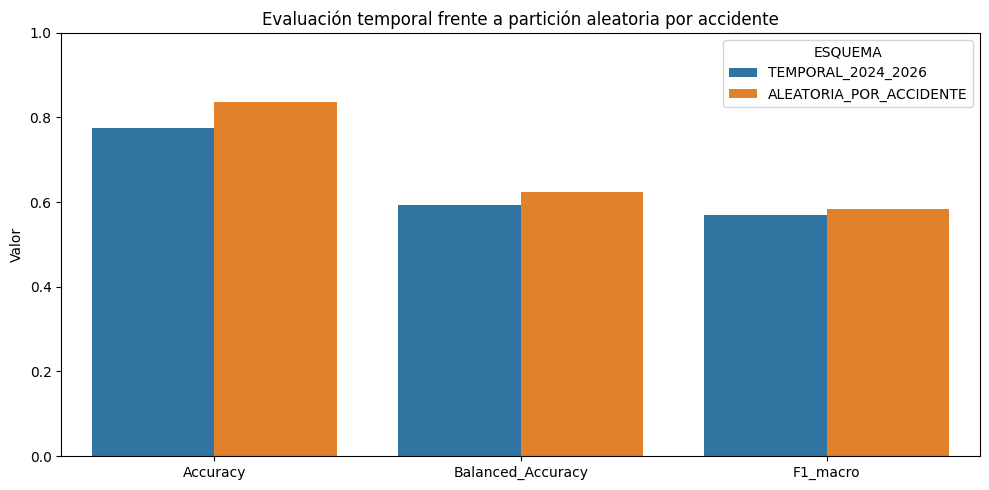

In [231]:
# Comparación gráfica de las métricas principales

metricas_grafico = comparacion_particiones.melt(
    id_vars='ESQUEMA',
    value_vars=[
        'Accuracy',
        'Balanced_Accuracy',
        'F1_macro'
    ],
    var_name='METRICA',
    value_name='VALOR'
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=metricas_grafico,
    x='METRICA',
    y='VALOR',
    hue='ESQUEMA',
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Valor')
ax.set_title(
    'Evaluación temporal frente a partición aleatoria por accidente'
)

plt.tight_layout()
plt.show()

#### Comparación entre partición temporal y aleatoria

La partición aleatoria por accidente produce métricas superiores a la evaluación temporal. El `F1_macro` aumenta de **0,5688** a **0,5834**, equivalente a una mejora relativa aproximada de **2,57 %**, mientras que la `Balanced_Accuracy` pasa de **0,5926** a **0,6235**. La diferencia es todavía más marcada en `Accuracy`, que aumenta de **0,7747** a **0,8377**. Las métricas probabilísticas también resultan más favorables bajo la partición aleatoria, con mayor `ROC_AUC_OVR_macro` y menores `Log_Loss` y `Brier_multiclase`.

Este comportamiento es esperable, ya que tanto el entrenamiento como la prueba aleatoria contienen accidentes distribuidos entre **2007 y 2026**, reduciendo el efecto de los cambios temporales observados previamente en la distribución de las clases. En contraste, la prueba temporal obliga al modelo entrenado con información histórica a generalizar exclusivamente hacia años posteriores, lo que representa una condición más exigente y cercana al uso real de PrediRuta.

También se observa que la distribución de `HERIDO`, `ILESO` y `MUERTO` es prácticamente idéntica entre entrenamiento y prueba en la partición aleatoria. Esto contrasta con el desplazamiento temporal identificado en la evaluación 2024–2026 y explica parcialmente el mejor desempeño del esquema aleatorio.

A pesar de obtener métricas absolutas menores, el modelo temporal mantiene una mejora considerable frente a su propia línea base. Por tanto, la partición aleatoria confirma que el modelo contiene capacidad predictiva, pero también evidencia que una evaluación aleatoria puede ofrecer una estimación más optimista. La partición temporal se mantiene como referencia principal al representar mejor la generalización hacia accidentes futuros.

## 14. Importancia de variables operativas

Para interpretar el comportamiento del modelo operativo se calcula la importancia por permutación sobre una muestra del conjunto de prueba temporal. Esta técnica mide cuánto disminuye el `F1_macro` cuando los valores de una variable se desordenan, manteniendo las demás sin cambios. Una disminución mayor indica que el modelo depende más de esa variable para realizar sus predicciones.

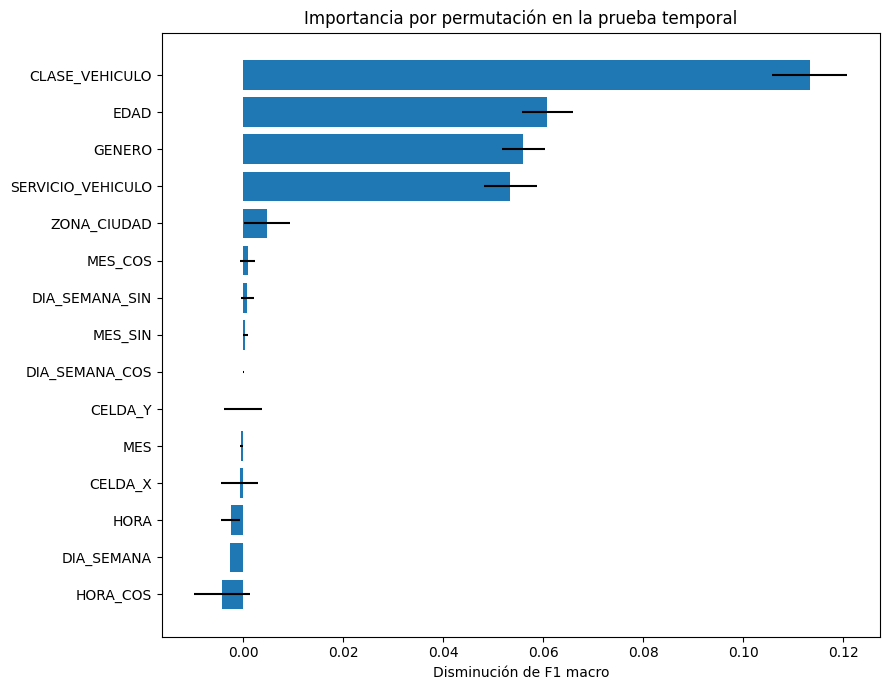

In [233]:
# Importancia por permutación sobre columnas de entrada, usando una muestra del test
rng_importancia = np.random.default_rng(SEMILLA)
cantidad_importancia = min(4_000, len(y_test))
indices_importancia = rng_importancia.choice(len(y_test), size=cantidad_importancia, replace=False)
importancia = permutation_importance(
    modelo_final, X_test.iloc[indices_importancia], y_test[indices_importancia],
    scoring='f1_macro', n_repeats=3, random_state=SEMILLA, n_jobs=1
)
importancia_variables = (
    pd.DataFrame({
        'VARIABLE': X_test.columns,
        'IMPORTANCIA_MEDIA': importancia.importances_mean,
        'DESVIACION': importancia.importances_std,
    })
    .sort_values('IMPORTANCIA_MEDIA', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
top_importancias = importancia_variables.head(15).sort_values('IMPORTANCIA_MEDIA')
ax.barh(top_importancias['VARIABLE'], top_importancias['IMPORTANCIA_MEDIA'], xerr=top_importancias['DESVIACION'])
ax.set_title('Importancia por permutación en la prueba temporal')
ax.set_xlabel('Disminución de F1 macro')
plt.tight_layout()
plt.show()

`CLASE_VEHICULO` presenta la mayor importancia, con una disminución cercana a **0,11** en `F1_macro` al permutarla. Le siguen `EDAD`, `GENERO` y `SERVICIO_VEHICULO`, con reducciones aproximadas entre **0,05 y 0,06**. `ZONA_CIUDAD` aporta una señal positiva de menor magnitud, lo que indica que la ubicación espacial contribuye de forma secundaria al desempeño del modelo.

Las variables temporales y las coordenadas `CELDA_X` y `CELDA_Y` presentan importancias cercanas a cero cuando se evalúan individualmente. Esto no implica necesariamente ausencia de información predictiva, ya que parte de su señal puede estar compartida con otras representaciones relacionadas, como las variables cíclicas o `ZONA_CIUDAD`. Las pequeñas importancias negativas observadas en algunas variables indican que su contribución individual es limitada en esta muestra.

En conjunto, el modelo operativo parece apoyarse principalmente en características del vehículo y del actor, mientras que la información espacial aporta una señal secundaria y las variables temporales muestran una contribución individual menor.

## 15. Ejemplo de consulta al modelo operativo

Finalmente, se construye una función de consulta que reproduce el flujo de uso del modelo operativo seleccionado. Como el escenario ganador es `OPERATIVO_SIN_CLIMA`, la entrada no requiere información meteorológica: se limita a ubicación, fecha y hora, edad, género y características del vehículo.

A partir de estos datos se deriva `ZONA_CIUDAD`, se generan las transformaciones cíclicas de mes, día y hora, y se organizan las variables en la misma estructura utilizada durante el entrenamiento. Como salida, el modelo devuelve las probabilidades estimadas para `HERIDO`, `ILESO` y `MUERTO`, ordenadas de mayor a menor.


In [235]:
def agregar_zona_ciudad(df):
    salida = df.copy()
    if 'ZONA_CIUDAD' in salida.columns:
        return salida
    requeridas = {'CELDA_X', 'CELDA_Y'}
    if not requeridas.issubset(salida.columns):
        raise ValueError('Se requiere ZONA_CIUDAD o las columnas CELDA_X y CELDA_Y')
    x_centro = (salida['CELDA_X'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    y_centro = (salida['CELDA_Y'].to_numpy() + 0.5) * TAMANO_CELDA_METROS
    lon_centro, lat_centro = bogota_a_wgs84.transform(x_centro, y_centro)
    _, posiciones = arbol_zonas.query(np.column_stack([lat_centro, lon_centro]), k=1)
    salida['ZONA_CIUDAD'] = (
        centroides_zona.iloc[posiciones]['ZONA_CIUDAD'].to_numpy().astype('int16')
    )
    return salida


def agregar_variables_temporales_consulta(df):
    salida = df.copy()
    for columna, periodo in {'MES': 12, 'DIA_SEMANA': 7, 'HORA': 24}.items():
        angulo = 2 * np.pi * salida[columna].astype(float) / periodo
        salida[f'{columna}_SIN'] = np.sin(angulo)
        salida[f'{columna}_COS'] = np.cos(angulo)
    return salida


def predecir_estado_actor_sin_informacion(registro, modelo=modelo_final):
    entrada = agregar_zona_ciudad(pd.DataFrame([registro]))
    entrada = agregar_variables_temporales_consulta(entrada)
    entrada = entrada[X_desarrollo.columns]
    probabilidades = ordenar_probabilidades(modelo, entrada, clases_codificadas)[0]
    return pd.DataFrame({
        'CODIGO_ESTADO': encoder_objetivo.classes_,
        'ESTADO': [catalogo_estados[codigo] for codigo in encoder_objetivo.classes_],
        'PROBABILIDAD': probabilidades,
    }).sort_values('PROBABILIDAD', ascending=False).reset_index(drop=True)


# Contrato de entrada del escenario OPERATIVO_SIN_CLIMA
columnas_crudas_ejemplo = [
    'CELDA_X', 'CELDA_Y',
    'MES', 'DIA_SEMANA', 'HORA',
    'EDAD', 'GENERO',
    'CLASE_VEHICULO', 'SERVICIO_VEHICULO'
]

registro_ejemplo = (
    datos_modelo.loc[mascara_test, columnas_crudas_ejemplo]
    .iloc[0]
    .to_dict()
)

print(f'Escenario utilizado: {ESCENARIO_GANADOR}')
display(predecir_estado_actor_sin_informacion(registro_ejemplo))


Escenario utilizado: OPERATIVO_SIN_CLIMA


,CODIGO_ESTADO,ESTADO,PROBABILIDAD
0,1,HERIDO,0.607636
1,3,MUERTO,0.332537
2,2,ILESO,0.059827


## 16. Exportación del modelo operativo

Una vez finalizada la evaluación temporal, se exporta el modelo operativo seleccionado junto con la información necesaria para reproducir posteriormente el proceso de inferencia. Se conserva el `Pipeline` completo, incluyendo el preprocesamiento y el estimador XGBoost, evitando tener que reconstruir manualmente las transformaciones utilizadas durante el entrenamiento.

También se almacenan la estructura esperada de las variables de entrada y la correspondencia de las clases de salida, de manera que el modelo pueda integrarse posteriormente con el flujo de consulta de PrediRuta.

In [238]:
RUTA_MODELO = Path('./modelos_produccion')
RUTA_MODELO.mkdir(parents=True, exist_ok=True)

modelo_operativo_final = modelos_finales['OPERATIVO']

# Guardar el modelo final en formato joblib para su uso en producción
joblib.dump(
    modelo_operativo_final,
    RUTA_MODELO / 'modelo_estado_actor_xgboost.joblib'
)

print('Modelo exportado correctamente.')

Modelo exportado correctamente.


In [239]:
# Guardar metadatos del modelo para la predicción en producción
artefactos_modelo = {
    'columnas_entrada': list(X_desarrollo.columns),
    'clases_codificadas': clases_codificadas,
    'clases_originales': encoder_objetivo.classes_,
    'catalogo_estados': catalogo_estados,
    'escenario': ESCENARIO_GANADOR,
    'modelo': NOMBRE_GANADOR,
    'parametros': PARAMETROS_GANADOR
}

joblib.dump(
    artefactos_modelo,
    RUTA_MODELO / 'metadata_estado_actor.joblib'
)

print('Metadata exportada correctamente.')

Metadata exportada correctamente.


In [240]:
# Guardar los centroides de las zonas de la ciudad para la predicción en producción
centroides_zona.to_csv(
    RUTA_MODELO / 'centroides_zonas.csv',
    index=False
)